# 02 - Ablation and Causality

This notebook runs single-head and multi-head ablations, temporal ablations, and downstream reader causal tracing.


In [1]:
# === CONFIG ===
import os, sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Model
RUN_NAME = "objrel_T5_DiT_mini_pilot"
CHECKPOINT_EPOCH = 4000
CHECKPOINT_STEP = 160000

# Ablation
N_IMAGES_PER_PROMPT = 10
GUIDANCE_SCALE = 4.5
NUM_INFERENCE_STEPS = 14
GENERATOR_SEED = 42

# Multi-seed robustness (tail cells): diffusion noise + optional bootstrap alignment
from utils.multi_seed_robustness import DEFAULT_ROBUSTNESS_SEEDS
ROBUSTNESS_SEEDS = list(DEFAULT_ROBUSTNESS_SEEDS[:5])  # start with 5 seeds

# OV-QK downstream discovery
SOURCE_RANK = 4
CANDIDATE_LAYERS = "later_only"

# Head screening
POS_EMBED_BASE_SIZE = 8
ALIGNMENT_COSINE_THRESHOLD = 0.7


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Fix SSL certificates on macOS
import os, ssl, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import os
from os.path import join
import torch
import torch as th
import torch.nn.functional as F
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pkl
from tqdm.auto import trange
from contextlib import redirect_stdout
import sys
sys.path.append("/Users/julianali/Desktop/DiffusionInterp/PixArt-alpha")
from diffusion.data.builder import build_dataset, build_dataloader, set_data_root
from diffusion.model.builder import build_model
from diffusion.utils.misc import set_random_seed, read_config, init_random_seed, DebugUnderflowOverflow
sys.path.append("/Users/julianali/Desktop/DiffusionInterp")
from utils.cv2_eval_utils import evaluate_pipeline_on_prompts, print_evaluation_summary
from utils.relation_shape_dataset_lib import ShapesDataset
from utils.variance_partition_with_effects import variance_partition_with_effects
from utils.pixart_sampling_utils import pipeline_inference_custom, \
    PixArtAlphaPipeline_custom, PixArtAlphaPipeline_custom_CLIP
from utils.pixart_utils import state_dict_convert, load_pixart_ema_into_transformer
from utils.pixart_utils import construct_diffuser_pipeline_from_config, PixArt_model_configs
from utils.text_encoder_control_lib import RandomEmbeddingEncoder_wPosEmb
from utils.image_utils import pil_images_to_grid
from utils.attention_map_store_utils import replace_attn_processor, AttnProcessor2_0_Store, PixArtAttentionVisualizer_Store
from utils.cv2_eval_utils import find_classify_object_masks
from diffusers import AutoencoderKL, Transformer2DModel, PixArtAlphaPipeline, DPMSolverMultistepScheduler
from transformers import T5Tokenizer, T5EncoderModel

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = "cuda"
    compute_dtype = torch.float16
elif torch.backends.mps.is_available():
    device = "mps"
    compute_dtype = torch.float32
else:
    device = "cpu"
    compute_dtype = torch.float32
print(f"Using device: {device}, compute dtype: {compute_dtype}")

def saveallforms(figdir, fname, figh=None, fmts=("png", "pdf")):
    """Local replacement for circuit_toolkit.plot_utils.saveallforms"""
    os.makedirs(figdir, exist_ok=True)
    fig = figh if figh is not None else plt.gcf()
    for fmt in fmts:
        fig.savefig(os.path.join(figdir, f"{fname}.{fmt}"), bbox_inches='tight', dpi=150)

/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


Using device: mps, compute dtype: torch.float32


/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


In [4]:
from itertools import product
def generate_all_prompt_collection(spatial_phrases, 
                               prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",):
    color_list = ['red', 'blue']
    shape_list = ['square', 'triangle', 'circle']
    prompt_collection = []
    scene_info_collection = []
    for color1, color2 in product(color_list, color_list):
        if color1 == color2:      # skip same‐color pairs
            continue
        for shape1, shape2 in product(shape_list, shape_list):
            if shape1 == shape2:
                continue
            for spatial_relationship, rel_text_collection in spatial_phrases.items():
                if spatial_relationship in ["in_front", "behind"]:
                    continue
                for rel_text in rel_text_collection:
                    prompt = prompt_template.format(color1=color1, shape1=shape1, rel_text=rel_text, color2=color2, shape2=shape2)
                    scene_info = {
                        "color1": color1,
                        "shape1": shape1,
                        "color2": color2,
                        "shape2": shape2,
                        "spatial_relationship": spatial_relationship
                    }
                    prompt_collection.append(prompt)
                    scene_info_collection.append(scene_info)
    return prompt_collection, scene_info_collection

In [5]:
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings
from experimental_scripts.generalization_profile_eval_cli import precompute_embeddings
def find_shape_index(tokens, shape):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = shape.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = shape.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

def find_word_index(tokens, word):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = word.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = word.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

## Section A - Environment Setup and Model Loading

Loads dependencies, resolves project paths, selects device/dtype, and builds the PixArt mini pipeline from checkpoint so later analysis cells can reuse a single initialized model.

In [6]:
import time, gc, psutil

def mem_gb():
    m = psutil.virtual_memory()
    return m.available / (1024**3), m.used / (1024**3)

def mem_check(label, min_gb=2.0):
    avail, used = mem_gb()
    print(f"  [{label}] RAM: {avail:.1f} GB free, {used:.1f} GB used")
    if avail < min_gb:
        raise MemoryError(
            f"Only {avail:.1f} GB free — need at least {min_gb} GB. "
            f"Close other apps (browsers, Slack, etc.) and retry."
        )

_t0 = time.time()
mem_check("start", min_gb=3.0)

model_run_name = "objrel_T5_DiT_mini_pilot"
ckpt_name = "epoch_4000_step_160000.pth"
savedir = f"/Users/julianali/Desktop/DiffusionInterp/results/{model_run_name}"
config = read_config(join(savedir, 'config.py'))
print(f"[1/5] Config loaded — Model: {config.model}  ({time.time()-_t0:.1f}s)")

# Build ONLY the mini transformer (~100MB, not the full XL pipeline)
print("[2/5] Building DiT-mini transformer...")
from utils.pixart_utils import construct_diffuser_transformer_from_config
transformer = construct_diffuser_transformer_from_config(config)
print(f"       Transformer built ({time.time()-_t0:.1f}s)")
mem_check("after transformer")

# Load checkpoint into transformer, then free the checkpoint
print("[3/5] Loading trained checkpoint...")
ckptdir = join(savedir, "checkpoints")
ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
load_pixart_ema_into_transformer(transformer, ckpt['state_dict_ema'])
del ckpt; gc.collect()
print(f"       Checkpoint loaded ({time.time()-_t0:.1f}s)")
mem_check("after checkpoint")

# Load VAE directly from Stability AI (~300MB, NOT from the huge PixArt-XL bundle)
print("[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema", torch_dtype=compute_dtype)
print(f"       VAE loaded ({time.time()-_t0:.1f}s)")
mem_check("after VAE")

# Assemble pipeline manually — this avoids downloading PixArt-XL-2-512x512 (~10GB+)
print("[5/5] Assembling pipeline (no large downloads)...")
tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
scheduler = DPMSolverMultistepScheduler()
pipeline = PixArtAlphaPipeline_custom(
    transformer=transformer,
    vae=vae,
    scheduler=scheduler,
    tokenizer=tokenizer,
    text_encoder=None,
)

# Move lightweight components to device
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
pipeline.vae = pipeline.vae.to(device=device, dtype=compute_dtype)

gc.collect()
avail, used = mem_gb()
print(f"\nDone! Pipeline on {device} ({time.time()-_t0:.1f}s)")
print(f"RAM: {avail:.1f} GB free, {used:.1f} GB used")

  [start] RAM: 5.3 GB free, 8.4 GB used
[1/5] Config loaded — Model: PixArt_mini_2  (0.0s)
[2/5] Building DiT-mini transformer...
       Transformer built (0.1s)
  [after transformer] RAM: 5.3 GB free, 8.4 GB used
[3/5] Loading trained checkpoint...
       Checkpoint loaded (0.3s)
  [after checkpoint] RAM: 5.3 GB free, 8.4 GB used
[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...


/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


       VAE loaded (0.7s)
  [after VAE] RAM: 5.2 GB free, 8.3 GB used
[5/5] Assembling pipeline (no large downloads)...

Done! Pipeline on mps (1.5s)
RAM: 5.2 GB free, 8.3 GB used


In [7]:
# Load pre-computed T5 embeddings from cache.
# If no cache exists, run the script in a SEPARATE PROCESS so T5 never enters this notebook.
import subprocess

cache_path = join(savedir, "t5_embedding_cache.pt")

if not os.path.exists(cache_path):
    avail, used = mem_gb()
    print(f"RAM before subprocess: {avail:.1f} GB free")
    if avail < 6.0:
        print(f"\n*** WARNING: Only {avail:.1f} GB free. The T5 subprocess needs ~6GB. ***")
        print("*** Close browsers, Slack, and other apps, then re-run this cell. ***\n")
    
    print("No embedding cache found. Running precomputation in a separate process...")
    print("(T5-XXL loads in a subprocess — this notebook's memory is unaffected)")
    print("This takes a few minutes the first time.\n")
    
    result = subprocess.run(
        [sys.executable, "/Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"],
    )
    if result.returncode != 0:
        raise RuntimeError(
            "Embedding precomputation failed!\n"
            "Try: 1) Close all other apps  2) Re-run this cell\n"
            "Or run the script directly in terminal:\n"
            f"  {sys.executable} /Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"
        )

print(f"Loading cached embeddings from {cache_path}...")
_cache = torch.load(cache_path, map_location="cpu", weights_only=False)
embedding_allrel_allobj = _cache["embedding_allrel_allobj"]
del _cache; gc.collect()
avail, _ = mem_gb()
print(f"Loaded {len(embedding_allrel_allobj)} embeddings. ({avail:.1f} GB free)")

Loading cached embeddings from /Users/julianali/Desktop/DiffusionInterp/results/objrel_T5_DiT_mini_pilot/t5_embedding_cache.pt...
Loaded 1057 embeddings. (5.2 GB free)


## Section B - Build/Load Embedding Cache and Token Features

Creates (or loads) cached T5 embeddings, extracts token-level vectors for objects/relations, and projects them into model space for head-alignment and downstream causal analysis.

In [8]:
# Extract word vectors from the pre-computed cached embeddings
dataset_tmp = ShapesDataset(num_images=10000)
prompt_collection_all, scene_info_collection_all = generate_all_prompt_collection(dataset_tmp.spatial_phrases,
                                prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",)
prompt_scene_info_all_df = pd.DataFrame(scene_info_collection_all)
prompt_scene_info_all_df["prompt"] = prompt_collection_all

wordvec_obj1_col = []
wordvec_obj2_col = []
for row in prompt_scene_info_all_df.itertuples():
    tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
    token_ids = tokenized['input_ids'][0]
    tokens = [pipeline.tokenizer.decode([token_id]) for token_id in token_ids]
    
    shape1_mask_idx = find_shape_index(tokens, row.shape1)
    shape2_mask_idx = find_shape_index(tokens, row.shape2)
    cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
    if shape1_mask_idx is None or shape2_mask_idx is None:
        print(f"Prompt: {row.prompt}")
        print(f"Shape1 ({row.shape1}) at index: {shape1_mask_idx}")
        print(f"Shape2 ({row.shape2}) at index: {shape2_mask_idx}")
        raise ValueError("Shape index not found")
    wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
    wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
with torch.no_grad():
    wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
    wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
print(f"Extracted word vectors: obj1={wordvec_obj1_mat.shape}, obj2={wordvec_obj2_mat.shape}")
print(f"Projected: obj1_proj={wordvec_obj1_mat_proj.shape}, obj2_proj={wordvec_obj2_mat_proj.shape}")

Extracted word vectors: obj1=torch.Size([228, 4096]), obj2=torch.Size([228, 4096])
Projected: obj1_proj=torch.Size([228, 384]), obj2_proj=torch.Size([228, 384])


### Downstream readers (early): OV-QK-OV candidate discovery

Runs **after** the setup cells that build `prompt_scene_info_all_df` and the projected shape token vectors (`wordvec_*_mat_proj`). You do **not** need the alignment or ablation sweeps below.

Optional **contrast banks** (`relation_obj2`, `relation_obj1`) are included automatically if you have already run the light variance-partition cells that define `effect_vecs` / `effect_vecs_S1`; otherwise structural ranking uses only the shape object banks.

Rank downstream candidates (OV-QK-OV): 100%|██████████| 24/24 [00:00<00:00, 46.96head/s]

Source relation head: L1H2
Structural screening checkpoint: epoch_4000_step_160000.pth (epoch=4000)
Feature banks used for structural tracing:


,bank,n_labels,labels,counts
0,shape_obj1,3,"square, triangle, circle","76, 76, 76"
1,shape_obj2,3,"triangle, circle, square","76, 76, 76"


Top 8 ranked candidates by chain_score


,head_label,read_score,write_score,object_shape_score,write_preference_score,contrast_write_score,chain_score,shape_obj1_best_label,shape_obj2_best_label,ov_qk_frob_norm_norm
0,L3H4,0.243786,0.692412,0.537105,NaN,NaN,0.081262,circle,circle,0.772981
1,L4H0,0.150217,1.063934,0.317283,NaN,NaN,0.080152,circle,circle,0.398185
2,L3H0,0.194872,0.850262,0.519544,NaN,NaN,0.078077,triangle,triangle,0.576207
3,L2H5,0.224230,0.786587,0.195921,NaN,NaN,0.077210,square,square,0.630500
4,L2H3,0.217851,1.005950,0.351132,NaN,NaN,0.072617,triangle,triangle,0.609323
5,L3H3,0.189133,0.930336,0.385961,NaN,NaN,0.068994,circle,circle,0.565685
6,L3H2,0.192744,0.887450,0.291475,NaN,NaN,0.068655,circle,circle,0.545503
7,L3H5,0.199683,0.827260,0.573416,NaN,NaN,0.066561,triangle,circle,0.567981


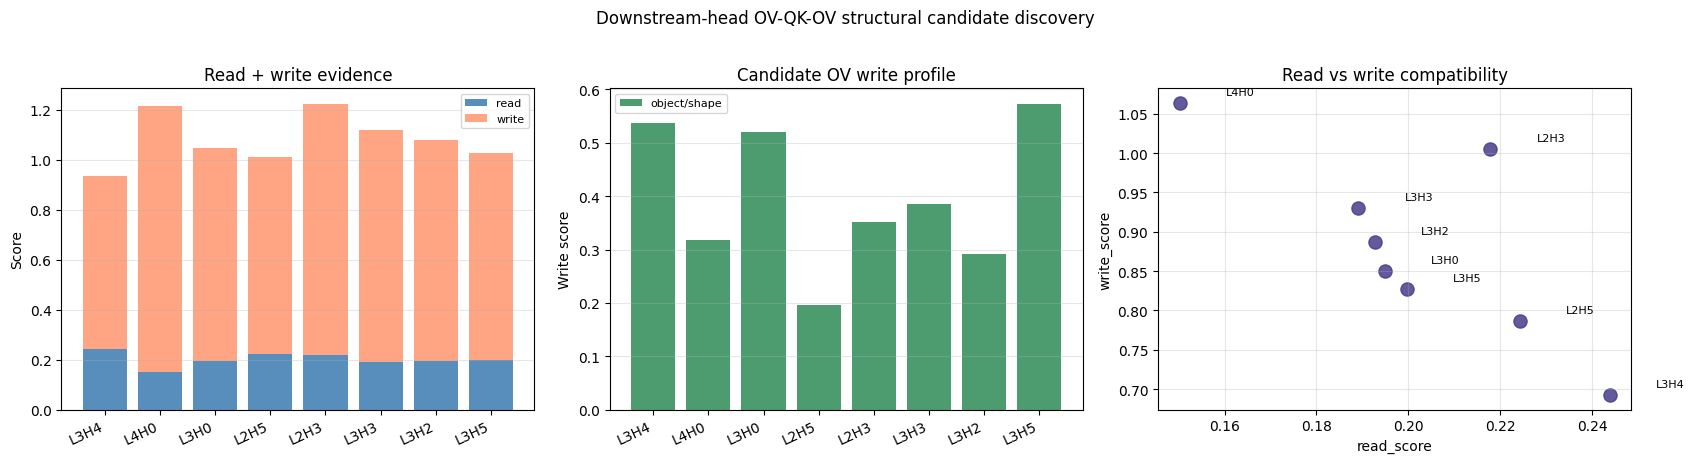

In [9]:
# Candidate discovery via OV-QK-OV structural chain ranking (Method B)
import glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join, basename
from IPython.display import display

from utils.pixart_utils import load_pixart_ema_into_transformer
from utils.downstream_head_tracing import (
    build_grouped_feature_bank,
    rank_downstream_candidates_by_structural_chain,
)

SOURCE_REL_HEAD = globals().get("SOURCE_REL_HEAD", (1, 2))
TRACE_CANDIDATE_LAYERS = globals().get("TRACE_CANDIDATE_LAYERS", "later_only")
TRACE_N_IMAGES_PER_PROMPT = globals().get("TRACE_N_IMAGES_PER_PROMPT", min(globals().get("N_IMAGES_PER_PROMPT", 5), 3))
TRACE_N_STEPS = globals().get("TRACE_N_STEPS", 14)
TRACE_GUIDANCE_SCALE = globals().get("TRACE_GUIDANCE_SCALE", globals().get("ABLATION_GUIDANCE_SCALE", 4.5))
TRACE_TOP_CANDIDATES = globals().get("TRACE_TOP_CANDIDATES", 8)
TRACE_SOURCE_RANK = globals().get("TRACE_SOURCE_RANK", 4)

if "prompt_scene_info_all_df" not in dir() or prompt_scene_info_all_df is None or prompt_scene_info_all_df.empty:
    raise RuntimeError("Run the setup / embedding extraction cells first so prompt_scene_info_all_df is available.")
if "wordvec_obj1_mat_proj" not in dir() or "wordvec_obj2_mat_proj" not in dir():
    raise RuntimeError("Run the caption projection cell first so wordvec_obj1_mat_proj / wordvec_obj2_mat_proj exist.")

if "ckpt_files_ablation" not in dir() or not ckpt_files_ablation:
    ckpt_files_ablation = sorted(
        glob.glob(join(ckptdir, "*.pth")),
        key=lambda p: int(basename(p).split("_step_")[-1].split(".pth")[0]) if "_step_" in p else 0,
    )

TRACE_DEV_CHECKPOINTS = globals().get(
    "TRACE_DEV_CHECKPOINTS",
    ABLATION_CHECKPOINTS if "ABLATION_CHECKPOINTS" in dir() and ABLATION_CHECKPOINTS is not None else ckpt_files_ablation,
)
TRACE_STRUCTURAL_CHECKPOINT = globals().get(
    "TRACE_STRUCTURAL_CHECKPOINT",
    TRACE_DEV_CHECKPOINTS[-1] if len(TRACE_DEV_CHECKPOINTS) > 0 else ckpt_files_ablation[-1],
)


def prepare_bank_matrix(feature_matrix, labels):
    arr = np.asarray(feature_matrix, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Expected a rank-2 feature matrix, got shape {arr.shape}")
    if arr.shape[0] != len(labels) and arr.shape[1] == len(labels):
        arr = arr.T
    if arr.shape[0] != len(labels):
        raise ValueError(f"Could not align feature matrix shape {arr.shape} with {len(labels)} labels")
    return arr


trace_structural_checkpoint_name = basename(str(TRACE_STRUCTURAL_CHECKPOINT))
trace_structural_checkpoint_path = (
    TRACE_STRUCTURAL_CHECKPOINT
    if str(TRACE_STRUCTURAL_CHECKPOINT).endswith(".pth") and "/" in str(TRACE_STRUCTURAL_CHECKPOINT)
    else join(ckptdir, trace_structural_checkpoint_name)
)
ckpt = torch.load(trace_structural_checkpoint_path, map_location="cpu", weights_only=False)
load_pixart_ema_into_transformer(pipeline.transformer, ckpt["state_dict_ema"])
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
trace_structural_epoch = int(trace_structural_checkpoint_name.split("_")[1]) if "epoch_" in trace_structural_checkpoint_name else np.nan

shape_obj1_bank = build_grouped_feature_bank(
    wordvec_obj1_mat_proj.float().cpu(),
    prompt_scene_info_all_df["shape1"].astype(str).tolist(),
    prefix="shape_obj1",
    max_rank=TRACE_SOURCE_RANK,
)
shape_obj2_bank = build_grouped_feature_bank(
    wordvec_obj2_mat_proj.float().cpu(),
    prompt_scene_info_all_df["shape2"].astype(str).tolist(),
    prefix="shape_obj2",
    max_rank=TRACE_SOURCE_RANK,
)
write_feature_banks = [shape_obj1_bank, shape_obj2_bank]

contrast_feature_banks = []
if "effect_vecs" in dir() and "levels_map" in dir() and "spatial_relationship" in effect_vecs:
    contrast_feature_banks.append(
        build_grouped_feature_bank(
            prepare_bank_matrix(effect_vecs["spatial_relationship"], levels_map["spatial_relationship"]),
            levels_map["spatial_relationship"],
            prefix="relation_obj2",
            max_rank=TRACE_SOURCE_RANK,
            center=False,
        )
    )
if "effect_vecs_S1" in dir() and "levels_map_S1" in dir() and "spatial_relationship" in effect_vecs_S1:
    contrast_feature_banks.append(
        build_grouped_feature_bank(
            prepare_bank_matrix(effect_vecs_S1["spatial_relationship"], levels_map_S1["spatial_relationship"]),
            levels_map_S1["spatial_relationship"],
            prefix="relation_obj1",
            max_rank=TRACE_SOURCE_RANK,
            center=False,
        )
    )

trace_feature_bank_df = pd.DataFrame(
    [
        {
            "bank": bank["prefix"],
            "n_labels": len(bank["label_names"]),
            "labels": ", ".join(bank["label_names"]),
            "counts": ", ".join(str(c) for c in bank["counts"]),
        }
        for bank in [*write_feature_banks, *contrast_feature_banks]
    ]
)

trace_candidate_rank_df = rank_downstream_candidates_by_structural_chain(
    pipeline.transformer,
    SOURCE_REL_HEAD,
    write_feature_banks=write_feature_banks,
    contrast_feature_banks=contrast_feature_banks,
    candidate_layers=TRACE_CANDIDATE_LAYERS,
    source_rank=TRACE_SOURCE_RANK,
    show_progress=True,
    progress_desc="Rank downstream candidates (OV-QK-OV)",
)
trace_candidate_rank_struct_df = trace_candidate_rank_df.copy()

trace_candidate_display_cols = [
    "head_label",
    "read_score",
    "write_score",
    "object_shape_score",
    "write_preference_score",
    "contrast_write_score",
    "chain_score",
    "shape_obj1_best_label",
    "shape_obj2_best_label",
    "ov_qk_frob_norm_norm",
]
trace_candidate_display_cols = [c for c in trace_candidate_display_cols if c in trace_candidate_rank_df.columns]
trace_candidate_display_df = trace_candidate_rank_df[trace_candidate_display_cols].copy()

print(f"Source relation head: L{SOURCE_REL_HEAD[0]}H{SOURCE_REL_HEAD[1]}")
print(f"Structural screening checkpoint: {trace_structural_checkpoint_name} (epoch={trace_structural_epoch})")
print("Feature banks used for structural tracing:")
display(trace_feature_bank_df)
print(f"Top {min(TRACE_TOP_CANDIDATES, len(trace_candidate_rank_df))} ranked candidates by chain_score")
display(trace_candidate_display_df.head(TRACE_TOP_CANDIDATES))

plot_candidates = trace_candidate_rank_df.head(min(TRACE_TOP_CANDIDATES, len(trace_candidate_rank_df))).copy()
if not plot_candidates.empty:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    axes[0].bar(plot_candidates["head_label"], plot_candidates["read_score"], color="steelblue", alpha=0.9, label="read")
    axes[0].bar(plot_candidates["head_label"], plot_candidates["write_score"], bottom=plot_candidates["read_score"], color="coral", alpha=0.7, label="write")
    axes[0].set_title("Read + write evidence")
    axes[0].set_ylabel("Score")
    axes[0].grid(True, axis="y", alpha=0.3)
    axes[0].legend(fontsize=8)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha="right")

    axes[1].bar(plot_candidates["head_label"], plot_candidates["object_shape_score"], color="seagreen", alpha=0.85, label="object/shape")
    if "contrast_write_score" in plot_candidates.columns and plot_candidates["contrast_write_score"].notna().any():
        axes[1].plot(plot_candidates["head_label"], plot_candidates["contrast_write_score"], "o--", color="firebrick", linewidth=2, label="relation contrast")
    axes[1].set_title("Candidate OV write profile")
    axes[1].set_ylabel("Write score")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].legend(fontsize=8)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha="right")

    axes[2].scatter(plot_candidates["read_score"], plot_candidates["write_score"], s=90, color="darkslateblue", alpha=0.85)
    for row in plot_candidates.itertuples():
        axes[2].text(row.read_score + 0.01, row.write_score + 0.01, row.head_label, fontsize=8)
    axes[2].set_title("Read vs write compatibility")
    axes[2].set_xlabel("read_score")
    axes[2].set_ylabel("write_score")
    axes[2].grid(True, alpha=0.3)

    plt.suptitle("Downstream-head OV-QK-OV structural candidate discovery", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


### Method-integrated robustness: top-head discovery stability (multi-seed + held-out)

Runs the OV-QK structural candidate ranking across bootstrap seeds on a held-out prompt split, then reports top-k head stability (`in_topk_frac`). This directly stress-tests whether downstream head discovery itself is stable, not just downstream ablation outcomes.

In [10]:
import numpy as np
import torch
import pandas as pd

from utils.ablation_eval_prompts import build_heldout_generalization_prompts
from utils.downstream_head_tracing import build_grouped_feature_bank, rank_downstream_candidates_by_structural_chain
from utils.multi_seed_robustness import bootstrap_row_indices, downstream_rank_stability_from_tables

TRACE_DISCOVERY_STABILITY_TOP_K = int(globals().get("TRACE_DISCOVERY_STABILITY_TOP_K", 8))

_req = {"trace_candidate_rank_df", "wordvec_obj1_mat_proj", "wordvec_obj2_mat_proj", "prompt_scene_info_all_df", "embedding_allrel_allobj"}
_miss = _req - set(dir())
if _miss:
    print("Skip discovery-stability: missing", sorted(_miss))
else:
    heldout_prompts_ds, _, heldout_meta_ds = build_heldout_generalization_prompts(
        prompt_scene_info_all_df,
        embedding_allrel_allobj,
        exclude_pairs=globals().get("HELDOUT_EXCLUDE_PAIRS", [("blue", "circle", "red", "square")]),
        n_per_relation=int(globals().get("HELDOUT_N_PER_RELATION", 3)),
        max_prompts=int(globals().get("HELDOUT_MAX_PROMPTS", 24)),
    )
    if heldout_meta_ds.empty:
        print("Skip discovery-stability: held-out split empty.")
    else:
        all_df = prompt_scene_info_all_df.reset_index(drop=True)
        idx_base = all_df.index[all_df["prompt"].isin(set(heldout_prompts_ds))].to_numpy(dtype=int)

        def _prep_bank_matrix(arr, labels):
            x = np.asarray(arr, dtype=np.float32)
            if x.ndim != 2:
                raise ValueError(f"Expected rank-2 matrix, got {x.shape}")
            if x.shape[0] != len(labels) and x.shape[1] == len(labels):
                x = x.T
            if x.shape[0] != len(labels):
                raise ValueError(f"Cannot align matrix shape {x.shape} with labels {len(labels)}")
            return x

        rank_tables = []
        for seed in ROBUSTNESS_SEEDS:
            boot_local = bootstrap_row_indices(len(idx_base), int(seed))
            idx = idx_base[boot_local]
            sub_df = all_df.iloc[idx].reset_index(drop=True)

            obj1_proj = wordvec_obj1_mat_proj.float().cpu().numpy()[idx]
            obj2_proj = wordvec_obj2_mat_proj.float().cpu().numpy()[idx]
            shape_obj1_bank = build_grouped_feature_bank(obj1_proj, sub_df["shape1"].astype(str).tolist(), prefix="shape_obj1", max_rank=int(globals().get("TRACE_SOURCE_RANK", 4)))
            shape_obj2_bank = build_grouped_feature_bank(obj2_proj, sub_df["shape2"].astype(str).tolist(), prefix="shape_obj2", max_rank=int(globals().get("TRACE_SOURCE_RANK", 4)))
            write_feature_banks = [shape_obj1_bank, shape_obj2_bank]

            contrast_feature_banks = []
            if "effect_vecs" in dir() and "levels_map" in dir() and "spatial_relationship" in effect_vecs:
                contrast_feature_banks.append(
                    build_grouped_feature_bank(
                        _prep_bank_matrix(effect_vecs["spatial_relationship"], levels_map["spatial_relationship"]),
                        levels_map["spatial_relationship"],
                        prefix="relation_obj2",
                        max_rank=int(globals().get("TRACE_SOURCE_RANK", 4)),
                        center=False,
                    )
                )

            df_rank_seed = rank_downstream_candidates_by_structural_chain(
                pipeline.transformer,
                SOURCE_REL_HEAD,
                write_feature_banks=write_feature_banks,
                contrast_feature_banks=contrast_feature_banks,
                candidate_layers=globals().get("TRACE_CANDIDATE_LAYERS", "later_only"),
                source_rank=int(globals().get("TRACE_SOURCE_RANK", 4)),
                show_progress=False,
            )
            df_rank_seed["seed"] = int(seed)
            rank_tables.append(df_rank_seed)

        trace_discovery_stability_df = downstream_rank_stability_from_tables(
            rank_tables,
            rank_col="chain_score",
            top_k=TRACE_DISCOVERY_STABILITY_TOP_K,
        )
        trace_discovery_stability_df["head_label"] = trace_discovery_stability_df.apply(
            lambda r: f"L{int(r['layer'])}H{int(r['head'])}",
            axis=1,
        )

        print(
            f"Top-head discovery stability on held-out prompts: n_prompts={len(heldout_prompts_ds)}, "
            f"seeds={ROBUSTNESS_SEEDS}, top_k={TRACE_DISCOVERY_STABILITY_TOP_K}"
        )
        display(trace_discovery_stability_df.sort_values(["in_topk_frac", "layer", "head"], ascending=[False, True, True]))

KeyboardInterrupt: 

### Causal probe: rigorous ablation on top OV-QK downstream heads

Rigorous causal test on the **top 8 structural candidates** (plus matched random controls) before Section C.

For each head we run three conditions: **source-only**, **candidate-only**, and **source+candidate** zero ablation. We then quantify:
- strict metric drops vs baseline (`spatial_relationship`, `unique_binding`, `overall`)
- bootstrap confidence intervals for candidate-only drops
- effect-size contrast against random controls
- pair-ablation synergy beyond the larger single-head effect

Positive `*_delta_from_baseline` means the ablated condition scored lower than baseline (larger positive drop = stronger causal evidence for circuit participation).

[pair ablations] checkpoint 1/1 (epoch 4000) | condition 1/49: baseline
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 2/49: src__3_4
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 3/49: cand__3_4
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 4/49: pair__3_4
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 5/49: src__4_0
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 6/49: cand__4_0
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 7/49: pair__4_0
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 8/49: src__3_0
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 9/49: cand__3_0
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 10/49: pair__3_0
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 11/49: src__2_5
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 12/49: cand__2_5
[pair ablations] checkpoint 1/1 (epoch 4000) | condition 13/49: pair__2_5
[pair ablations] checkpoint 1/1 (epoch 4000) | condi

,candidate_head,condition_key,condition_label,spatial_relationship_delta_cand,unique_binding_delta_cand,overall_delta_cand,spatial_relationship_delta_src,unique_binding_delta_src,overall_delta_src,spatial_relationship_delta_pair,unique_binding_delta_pair,overall_delta_pair,spatial_relationship_pair_synergy,unique_binding_pair_synergy,overall_pair_synergy,is_top8_candidate,spatial_delta_vs_control_z
0,L3H4,cand__3_4,Candidate only L3H4,0.027778,0.000000,0.027778,0.055556,0.138889,0.055556,0.027778,0.055556,0.027778,-0.027778,-0.083333,-0.027778,True,1.322876e+00
1,L3H5,cand__3_5,Candidate only L3H5,0.027778,0.000000,0.027778,0.055556,0.138889,0.055556,0.055556,0.083333,0.055556,0.000000,-0.055556,0.000000,True,1.322876e+00
2,L2H3,cand__2_3,Candidate only L2H3,0.000000,0.027778,0.000000,0.055556,0.138889,0.055556,0.055556,0.083333,0.055556,0.000000,-0.055556,0.000000,True,-6.609092e-16
3,L3H2,cand__3_2,Candidate only L3H2,0.000000,0.000000,0.000000,0.055556,0.138889,0.055556,0.027778,0.055556,0.027778,-0.027778,-0.083333,-0.027778,True,-6.609092e-16
4,L4H0,cand__4_0,Candidate only L4H0,-0.027778,-0.027778,-0.027778,0.055556,0.138889,0.055556,0.000000,0.027778,0.000000,-0.055556,-0.111111,-0.055556,True,-1.322876e+00
5,L3H0,cand__3_0,Candidate only L3H0,-0.027778,-0.027778,-0.027778,0.055556,0.138889,0.055556,0.000000,0.055556,0.000000,-0.055556,-0.083333,-0.055556,True,-1.322876e+00
6,L2H5,cand__2_5,Candidate only L2H5,-0.027778,-0.027778,-0.027778,0.055556,0.138889,0.055556,0.083333,0.166667,0.083333,0.027778,0.027778,0.027778,True,-1.322876e+00
7,L3H3,cand__3_3,Candidate only L3H3,-0.055556,-0.055556,-0.055556,0.055556,0.138889,0.055556,0.055556,0.111111,0.055556,0.000000,-0.027778,0.000000,True,-2.645751e+00
8,L5H0,cand__5_0,Candidate only L5H0,0.027778,0.000000,0.027778,0.055556,0.138889,0.055556,0.000000,0.027778,0.000000,-0.055556,-0.111111,-0.055556,False,1.322876e+00
9,L2H0,cand__2_0,Candidate only L2H0,0.027778,0.000000,0.027778,0.055556,0.138889,0.055556,0.000000,0.055556,0.000000,-0.055556,-0.083333,-0.055556,False,1.322876e+00


Bootstrap 95% CIs for candidate-only deltas:


,candidate_head,metric,delta_mean,delta_ci_lo,delta_ci_hi
0,L3H4,spatial_relationship,0.027778,-0.194444,0.250000
1,L3H4,unique_binding,0.000000,-0.166667,0.166667
2,L3H4,overall,0.027778,-0.194444,0.277778
3,L4H0,spatial_relationship,-0.027778,-0.250000,0.194444
4,L4H0,unique_binding,-0.027778,-0.194444,0.138889
5,L4H0,overall,-0.027778,-0.277778,0.194444
6,L3H0,spatial_relationship,-0.027778,-0.250000,0.194444
7,L3H0,unique_binding,-0.027778,-0.194444,0.138889
8,L3H0,overall,-0.027778,-0.250000,0.194444
9,L2H5,spatial_relationship,-0.027778,-0.250000,0.194444


Functional role summary from source/candidate/pair ablations:


,candidate_head,source_only_spatial_relationship_delta_mean,source_only_unique_binding_delta_mean,source_only_overall_delta_mean,source_only_Dx_abs_mean_delta_mean,source_only_Dy_abs_mean_delta_mean,candidate_only_spatial_relationship_delta_mean,candidate_only_unique_binding_delta_mean,candidate_only_overall_delta_mean,candidate_only_Dx_abs_mean_delta_mean,candidate_only_Dy_abs_mean_delta_mean,pair_spatial_relationship_delta_mean,pair_unique_binding_delta_mean,pair_overall_delta_mean,pair_Dx_abs_mean_delta_mean,pair_Dy_abs_mean_delta_mean,binding_reader_score,location_reader_score,role_hypothesis
0,L3H3,0.055556,0.138889,0.055556,6.893333,-1.36,-0.055556,-0.055556,-0.055556,1.452083,2.918750,0.055556,0.111111,0.055556,8.002564,-0.646154,-0.055556,1.438426e+00,location_reader
1,L2H5,0.055556,0.138889,0.055556,6.893333,-1.36,-0.027778,-0.027778,-0.027778,0.701075,1.780645,0.083333,0.166667,0.083333,6.941667,2.075000,-0.027778,8.179809e-01,location_reader
2,L2H3,0.055556,0.138889,0.055556,6.893333,-1.36,0.000000,0.027778,0.000000,3.664368,-1.386207,0.055556,0.083333,0.055556,3.918519,3.274074,0.027778,7.593870e-01,location_reader
3,L4H1,0.055556,0.138889,0.055556,6.893333,-1.36,-0.027778,-0.027778,-0.027778,0.539785,1.651613,0.055556,0.111111,0.055556,8.156410,-0.761538,-0.027778,7.212067e-01,location_reader
4,L4H0,0.055556,0.138889,0.055556,6.893333,-1.36,-0.027778,-0.027778,-0.027778,1.120430,0.683871,0.000000,0.027778,0.000000,5.871264,0.751724,-0.027778,5.921744e-01,location_reader
5,L3H0,0.055556,0.138889,0.055556,6.893333,-1.36,-0.027778,-0.027778,-0.027778,1.217204,0.490323,0.000000,0.055556,0.000000,5.411905,0.414286,-0.027778,5.599164e-01,location_reader
6,L3H1,0.055556,0.138889,0.055556,6.893333,-1.36,-0.027778,-0.027778,-0.027778,-0.944086,1.941935,0.000000,0.027778,0.000000,5.422989,2.682759,-0.027778,3.233572e-01,location_reader
7,L5H0,0.055556,0.138889,0.055556,6.893333,-1.36,0.027778,0.000000,0.027778,0.400000,0.166667,0.000000,0.027778,0.000000,5.491954,1.751724,0.000000,1.981481e-01,location_reader
8,L3H4,0.055556,0.138889,0.055556,6.893333,-1.36,0.027778,0.000000,0.027778,0.233333,0.100000,0.027778,0.055556,0.027778,4.161905,1.414286,0.000000,1.203704e-01,location_reader
9,L4H4,0.055556,0.138889,0.055556,6.893333,-1.36,0.000000,0.000000,0.000000,0.000000,0.100000,0.055556,0.111111,0.055556,7.771795,-0.684615,0.000000,3.333333e-02,location_reader


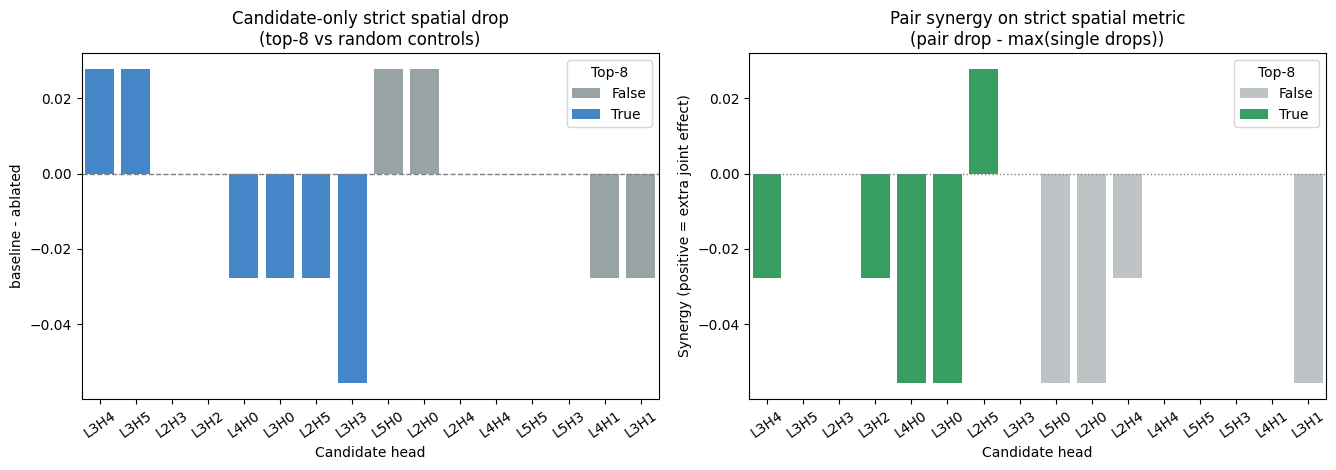

In [ ]:
# Rigorous top-8 downstream-head ablation (candidate-only, source-only, pair, + random controls)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from os.path import basename

from utils.ablation_eval_prompts import build_diverse_subset_prompts
from utils.downstream_head_tracing import run_pair_ablation_grid, summarize_functional_effects

TRACE_DOWNSTREAM_CIRCUIT_K = int(globals().get("TRACE_DOWNSTREAM_CIRCUIT_K", 8))
TRACE_DOWNSTREAM_CIRCUIT_N_PROMPTS = int(globals().get("TRACE_DOWNSTREAM_CIRCUIT_N_PROMPTS", 20))
TRACE_DOWNSTREAM_CIRCUIT_N_IMAGES = int(globals().get("TRACE_DOWNSTREAM_CIRCUIT_N_IMAGES", min(TRACE_N_IMAGES_PER_PROMPT, 3)))
TRACE_DOWNSTREAM_CIRCUIT_N_STEPS = int(globals().get("TRACE_DOWNSTREAM_CIRCUIT_N_STEPS", TRACE_N_STEPS))
TRACE_DOWNSTREAM_CIRCUIT_GUIDANCE = float(globals().get("TRACE_DOWNSTREAM_CIRCUIT_GUIDANCE", TRACE_GUIDANCE_SCALE))
TRACE_DOWNSTREAM_CIRCUIT_N_RANDOM_CONTROLS = int(globals().get("TRACE_DOWNSTREAM_CIRCUIT_N_RANDOM_CONTROLS", 8))
TRACE_DOWNSTREAM_CIRCUIT_BOOTSTRAP_B = int(globals().get("TRACE_DOWNSTREAM_CIRCUIT_BOOTSTRAP_B", 1500))
TRACE_DOWNSTREAM_CIRCUIT_SEED = int(globals().get("TRACE_DOWNSTREAM_CIRCUIT_SEED", GENERATOR_SEED))
TRACE_DOWNSTREAM_CIRCUIT_METRICS = ["spatial_relationship", "unique_binding", "overall"]

if "trace_candidate_rank_df" not in dir() or trace_candidate_rank_df is None or trace_candidate_rank_df.empty:
    raise RuntimeError("Run the OV-QK candidate discovery cell first.")
if "embedding_allrel_allobj" not in dir():
    raise RuntimeError("Load the T5 embedding cache (Section B) first.")

# Top-K structural candidates and matched random controls from the same candidate pool.
top_head_df = trace_candidate_rank_df.head(TRACE_DOWNSTREAM_CIRCUIT_K).copy()
trace_top8_heads = [(int(r.layer_idx), int(r.head_idx)) for r in top_head_df.itertuples()]
trace_top8_head_labels = [f"L{l}H{h}" for l, h in trace_top8_heads]

remaining_pool_df = trace_candidate_rank_df.iloc[TRACE_DOWNSTREAM_CIRCUIT_K:].copy()
rng = np.random.default_rng(TRACE_DOWNSTREAM_CIRCUIT_SEED)
if remaining_pool_df.empty:
    trace_control_heads = []
else:
    n_ctrl = min(TRACE_DOWNSTREAM_CIRCUIT_N_RANDOM_CONTROLS, len(remaining_pool_df))
    ctrl_idx = rng.choice(len(remaining_pool_df), size=n_ctrl, replace=False)
    ctrl_df = remaining_pool_df.iloc[np.sort(ctrl_idx)]
    trace_control_heads = [(int(r.layer_idx), int(r.head_idx)) for r in ctrl_df.itertuples()]
trace_control_head_labels = [f"L{l}H{h}" for l, h in trace_control_heads]

trace_ablation_heads = [*trace_top8_heads, *trace_control_heads]
if not trace_ablation_heads:
    raise RuntimeError("No candidate heads available for downstream ablation.")

prompts_trace_circuit, scene_infos_trace_circuit = build_diverse_subset_prompts(
    prompt_scene_info_all_df,
    embedding_allrel_allobj,
    n_prompts=TRACE_DOWNSTREAM_CIRCUIT_N_PROMPTS,
)

trace_ckpt_name = basename(str(TRACE_STRUCTURAL_CHECKPOINT)) if "TRACE_STRUCTURAL_CHECKPOINT" in dir() else basename(str(ckpt_files_ablation[-1]))
trace_state_dict_convert = globals().get("state_dict_convert", None)
trace_circuit_summary_df, trace_circuit_eval_df = run_pair_ablation_grid(
    pipeline=pipeline,
    ckptdir=ckptdir,
    ckpt_list=[trace_ckpt_name],
    prompts=prompts_trace_circuit,
    scene_infos=scene_infos_trace_circuit,
    embedding_cache=embedding_allrel_allobj,
    source_head=SOURCE_REL_HEAD,
    candidate_heads=trace_ablation_heads,
    state_dict_convert=trace_state_dict_convert,
    device=device,
    weight_dtype=compute_dtype,
    num_images=TRACE_DOWNSTREAM_CIRCUIT_N_IMAGES,
    num_inference_steps=TRACE_DOWNSTREAM_CIRCUIT_N_STEPS,
    guidance_scale=TRACE_DOWNSTREAM_CIRCUIT_GUIDANCE,
    generator_seed=TRACE_DOWNSTREAM_CIRCUIT_SEED,
    metric_cols=TRACE_DOWNSTREAM_CIRCUIT_METRICS,
    show_prompt_progress=False,
    progress_mode="print",
)

# Candidate-level role summary from source-only / candidate-only / pair conditions.
trace_circuit_role_df = summarize_functional_effects(
    trace_circuit_summary_df,
    metric_cols=TRACE_DOWNSTREAM_CIRCUIT_METRICS,
)

# Build rigorous effect table with top-vs-control contrast and pair synergy.
cand_df = trace_circuit_summary_df[trace_circuit_summary_df["condition_key"].str.startswith("cand__")].copy()
src_df = trace_circuit_summary_df[trace_circuit_summary_df["condition_key"].str.startswith("src__")].copy()
pair_df = trace_circuit_summary_df[trace_circuit_summary_df["condition_key"].str.startswith("pair__")].copy()

def _drop_cols(df, prefix):
    keep = ["candidate_head", "condition_key", "condition_label"]
    keep += [f"{m}_delta_from_baseline" for m in TRACE_DOWNSTREAM_CIRCUIT_METRICS if f"{m}_delta_from_baseline" in df.columns]
    out = df[keep].copy()
    rename_map = {c: c.replace("_delta_from_baseline", f"_delta_{prefix}") for c in out.columns if c.endswith("_delta_from_baseline")}
    return out.rename(columns=rename_map)

trace_cand_effect_df = _drop_cols(cand_df, "cand")
trace_src_effect_df = _drop_cols(src_df, "src")
trace_pair_effect_df = _drop_cols(pair_df, "pair")

trace_circuit_rigorous_df = trace_cand_effect_df.merge(trace_src_effect_df[[c for c in trace_src_effect_df.columns if c != "condition_key" and c != "condition_label"]], on="candidate_head", how="left")
trace_circuit_rigorous_df = trace_circuit_rigorous_df.merge(trace_pair_effect_df[[c for c in trace_pair_effect_df.columns if c != "condition_key" and c != "condition_label"]], on="candidate_head", how="left")

for metric in TRACE_DOWNSTREAM_CIRCUIT_METRICS:
    c_col = f"{metric}_delta_cand"
    s_col = f"{metric}_delta_src"
    p_col = f"{metric}_delta_pair"
    if all(col in trace_circuit_rigorous_df.columns for col in [c_col, s_col, p_col]):
        trace_circuit_rigorous_df[f"{metric}_pair_synergy"] = trace_circuit_rigorous_df[p_col] - trace_circuit_rigorous_df[[c_col, s_col]].max(axis=1)

trace_circuit_rigorous_df["is_top8_candidate"] = trace_circuit_rigorous_df["candidate_head"].isin(trace_top8_head_labels)

# Bootstrap CIs for candidate-only deltas (baseline - candidate condition).
bootstrap_rows = []
if not trace_circuit_eval_df.empty:
    baseline_eval = trace_circuit_eval_df[trace_circuit_eval_df["condition_key"] == "baseline"].copy()
    for head_label in trace_circuit_rigorous_df["candidate_head"].tolist():
        cond_key = f"cand__{head_label[1:].replace('H', '_')}"
        cand_eval = trace_circuit_eval_df[trace_circuit_eval_df["condition_key"] == cond_key].copy()
        if baseline_eval.empty or cand_eval.empty:
            continue
        for metric in TRACE_DOWNSTREAM_CIRCUIT_METRICS:
            if metric not in baseline_eval.columns or metric not in cand_eval.columns:
                continue
            bvals = baseline_eval[metric].dropna().to_numpy(dtype=float)
            cvals = cand_eval[metric].dropna().to_numpy(dtype=float)
            if len(bvals) == 0 or len(cvals) == 0:
                continue
            boot = []
            for _ in range(TRACE_DOWNSTREAM_CIRCUIT_BOOTSTRAP_B):
                bs_b = rng.choice(bvals, size=len(bvals), replace=True)
                bs_c = rng.choice(cvals, size=len(cvals), replace=True)
                boot.append(float(np.mean(bs_b) - np.mean(bs_c)))
            boot = np.asarray(boot, dtype=float)
            bootstrap_rows.append(
                {
                    "candidate_head": head_label,
                    "metric": metric,
                    "delta_mean": float(np.mean(bvals) - np.mean(cvals)),
                    "delta_ci_lo": float(np.quantile(boot, 0.025)),
                    "delta_ci_hi": float(np.quantile(boot, 0.975)),
                }
            )

trace_circuit_bootstrap_df = pd.DataFrame(bootstrap_rows)

# Effect-size contrast vs random controls for strict spatial drop.
ctrl_vals = trace_circuit_rigorous_df.loc[~trace_circuit_rigorous_df["is_top8_candidate"], "spatial_relationship_delta_cand"].dropna().to_numpy(dtype=float)
if len(ctrl_vals) >= 2:
    mu_ctrl = float(np.mean(ctrl_vals))
    sd_ctrl = float(np.std(ctrl_vals, ddof=1))
    trace_circuit_rigorous_df["spatial_delta_vs_control_z"] = (
        trace_circuit_rigorous_df["spatial_relationship_delta_cand"] - mu_ctrl
    ) / max(sd_ctrl, 1e-8)
else:
    trace_circuit_rigorous_df["spatial_delta_vs_control_z"] = np.nan

sort_cols = ["is_top8_candidate"]
if "spatial_relationship_delta_cand" in trace_circuit_rigorous_df.columns:
    sort_cols.append("spatial_relationship_delta_cand")
if "overall_delta_cand" in trace_circuit_rigorous_df.columns:
    sort_cols.append("overall_delta_cand")
trace_circuit_rigorous_df = trace_circuit_rigorous_df.sort_values(
    sort_cols,
    ascending=[False] * len(sort_cols),
).reset_index(drop=True)

print(
    f"Rigorous ablation set: {len(trace_top8_heads)} top heads + {len(trace_control_heads)} controls | "
    f"prompts={len(prompts_trace_circuit)}, images/prompt={TRACE_DOWNSTREAM_CIRCUIT_N_IMAGES}, steps={TRACE_DOWNSTREAM_CIRCUIT_N_STEPS}"
)
print("Top-8 heads:", trace_top8_head_labels)
if trace_control_head_labels:
    print("Random controls:", trace_control_head_labels)

display(trace_circuit_rigorous_df)
if not trace_circuit_bootstrap_df.empty:
    print("Bootstrap 95% CIs for candidate-only deltas:")
    display(trace_circuit_bootstrap_df)
print("Functional role summary from source/candidate/pair ablations:")
display(trace_circuit_role_df)

plot_df = trace_circuit_rigorous_df.copy()
if not plot_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

    sns.barplot(
        data=plot_df,
        x="candidate_head",
        y="spatial_relationship_delta_cand",
        hue="is_top8_candidate",
        dodge=False,
        palette={True: "#2E86DE", False: "#95A5A6"},
        ax=axes[0],
    )
    axes[0].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
    axes[0].set_title("Candidate-only strict spatial drop\n(top-8 vs random controls)")
    axes[0].set_xlabel("Candidate head")
    axes[0].set_ylabel("baseline - ablated")
    axes[0].tick_params(axis="x", rotation=35)
    axes[0].legend(title="Top-8")

    if "spatial_relationship_pair_synergy" in plot_df.columns:
        sns.barplot(
            data=plot_df,
            x="candidate_head",
            y="spatial_relationship_pair_synergy",
            hue="is_top8_candidate",
            dodge=False,
            palette={True: "#27AE60", False: "#BDC3C7"},
            ax=axes[1],
        )
        axes[1].axhline(0.0, color="gray", linestyle=":", linewidth=1.0)
        axes[1].set_title("Pair synergy on strict spatial metric\n(pair drop - max(single drops))")
        axes[1].set_xlabel("Candidate head")
        axes[1].set_ylabel("Synergy (positive = extra joint effect)")
        axes[1].tick_params(axis="x", rotation=35)
        axes[1].legend(title="Top-8")

    plt.tight_layout()
    plt.show()

## Object Feature Finding w/ Feature-Probe

Score object feature probes: 100%|██████████| 24/24 [00:00<00:00, 31.19head/s]

Feature probes built: 40
Primary object-feature score: obj1_vp_color_shape__red_square_chain_score
Target object slot / label request: obj1 / red_square
Resolved target probes:
{'whole_shape': 'obj1_whole_shape__square', 'whole_color_shape': 'obj1_whole_color_shape__red_square', 'vp_shape': 'obj1_vp_shape__square', 'vp_color_shape': 'obj1_vp_color_shape__red_square'}
Projected-space variance partition (obj1 / obj2):


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm,object_slot
0,color1,2,1,219,7730.268487,1086.080179,0.140497,0.000000,0.000000,0.000000,NaN,obj1
1,shape1,3,2,219,7730.268487,2439.099594,0.315526,0.000000,0.000000,0.000000,NaN,obj1
2,color1shape1,6,5,219,7730.268487,3845.859736,0.497507,320.679962,0.041484,0.076260,NaN,obj1
3,color2,2,1,219,7778.347856,850.466716,0.109338,0.000000,0.000000,0.000000,NaN,obj2
4,shape2,3,2,219,7778.347856,2194.810591,0.282169,0.000000,0.000000,0.000000,NaN,obj2
5,color2shape2,6,5,219,7778.347856,3336.617333,0.428962,291.340025,0.037455,0.061554,NaN,obj2


Top head per probe family (whole vectors and variance-partition effects):


,probe_group,best_head_by_chain,best_probe_by_chain,chain_score_max,best_head_read_score,best_head_write_score,best_head_by_vo,best_probe_by_vo,vo_probe_norm_norm_max
0,obj1_vp_color,L2H5,obj1_vp_color__red,0.036931,0.224230,0.786587,L4H1,obj1_vp_color__blue,0.162804
1,obj1_vp_color_shape,L3H0,obj1_vp_color_shape__red_square,0.078777,0.194872,0.850262,L2H2,obj1_vp_color_shape__blue_triangle,0.228793
2,obj1_vp_shape,L3H0,obj1_vp_shape__square,0.096431,0.194872,0.850262,L3H5,obj1_vp_shape__circle,0.273089
3,obj1_whole_color_shape,L4H0,obj1_whole_color_shape__blue_circle,0.039834,0.150217,1.063934,L3H0,obj1_whole_color_shape__blue_triangle,0.231228
4,obj1_whole_shape,L4H0,obj1_whole_shape__circle,0.043286,0.150217,1.063934,L3H0,obj1_whole_shape__triangle,0.240608
5,obj2_vp_color,L2H5,obj2_vp_color__red,0.035865,0.224230,0.786587,L4H1,obj2_vp_color__blue,0.155371
6,obj2_vp_color_shape,L3H0,obj2_vp_color_shape__red_square,0.097460,0.194872,0.850262,L3H0,obj2_vp_color_shape__blue_triangle,0.240813
7,obj2_vp_shape,L3H0,obj2_vp_shape__square,0.112743,0.194872,0.850262,L3H5,obj2_vp_shape__square,0.293015
8,obj2_whole_color_shape,L4H0,obj2_whole_color_shape__red_circle,0.047185,0.150217,1.063934,L3H0,obj2_whole_color_shape__red_triangle,0.242923
9,obj2_whole_shape,L4H0,obj2_whole_shape__circle,0.050174,0.150217,1.063934,L3H0,obj2_whole_shape__triangle,0.263211


Top heads under the selected object-feature score:


,feature_probe_rank,head_label,obj1_vp_color_shape__red_square_chain_score,read_score,write_score,chain_score,object_shape_score,write_preference_score,obj1_whole_shape__square_vo_probe_norm_norm,obj1_whole_shape__square_vo_source_cosine,...,obj1_whole_color_shape__red_square_qk_cosine,obj1_whole_color_shape__red_square_chain_score,obj1_vp_shape__square_vo_probe_norm_norm,obj1_vp_shape__square_vo_source_cosine,obj1_vp_shape__square_qk_cosine,obj1_vp_shape__square_chain_score,obj1_vp_color_shape__red_square_vo_probe_norm_norm,obj1_vp_color_shape__red_square_vo_source_cosine,obj1_vp_color_shape__red_square_qk_cosine,obj1_vp_color_shape__red_square_chain_score
0,1,L3H0,0.078777,0.194872,0.850262,0.078077,0.519544,NaN,0.098665,-0.035824,...,0.095567,0.009759,0.186958,-0.023882,0.515788,0.096431,0.160512,-0.045566,0.490788,0.078777
1,2,L3H3,0.062301,0.189133,0.930336,0.068994,0.385961,NaN,0.114480,0.090635,...,0.224965,0.025815,0.145705,0.020319,0.430892,0.062783,0.130924,0.021155,0.475853,0.062301
2,3,L3H4,0.048055,0.243786,0.692412,0.081262,0.537105,NaN,0.112221,0.049562,...,-0.263036,0.000000,0.196470,-0.001964,-0.203067,0.000000,0.163131,0.001292,0.294580,0.048055
3,4,L5H3,0.044611,0.154559,1.081212,0.051520,0.390689,NaN,0.160704,-0.000393,...,-0.150949,0.000000,0.168312,0.006282,0.308536,0.051930,0.154986,0.022349,0.287837,0.044611
4,5,L2H2,0.042413,0.149105,0.969220,0.049702,0.540193,NaN,0.142776,-0.055251,...,-0.320535,0.000000,0.235293,-0.077479,-0.010992,0.000000,0.224038,-0.070001,0.189310,0.042413
5,6,L5H4,0.027102,0.148162,1.086554,0.049387,0.266849,NaN,0.133848,0.000100,...,-0.215660,0.000000,0.165746,0.044420,0.139151,0.023064,0.150096,0.048227,0.180564,0.027102
6,7,L2H1,0.026641,0.172310,0.944219,0.057437,0.482185,NaN,0.105855,0.090488,...,-0.357517,0.000000,0.143991,0.088998,0.088612,0.012759,0.111851,0.162513,0.238179,0.026641
7,8,L5H0,0.023736,0.141728,1.091409,0.061121,0.331435,NaN,0.130087,-0.048056,...,0.125109,0.014908,0.194313,-0.075382,0.382831,0.074389,0.174972,-0.056116,0.135655,0.023736


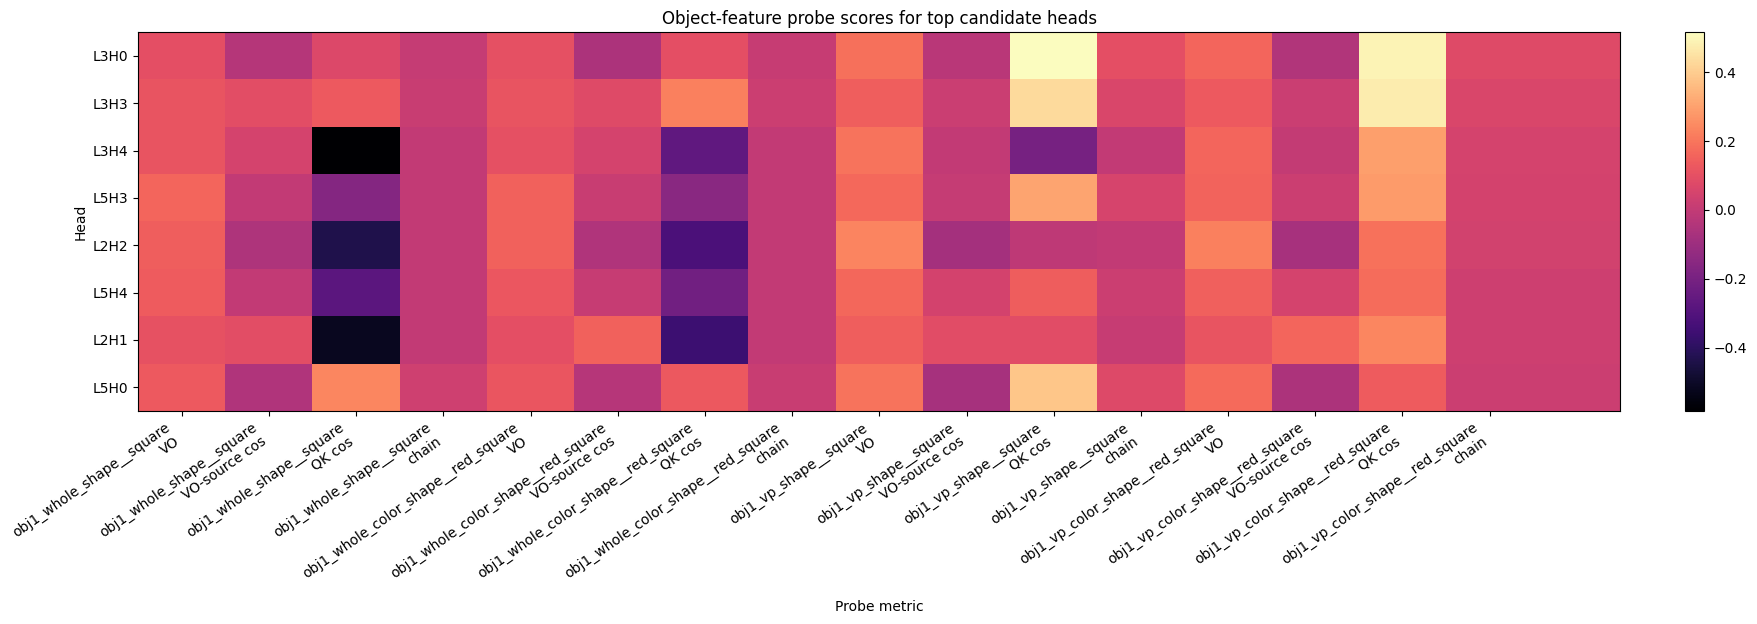

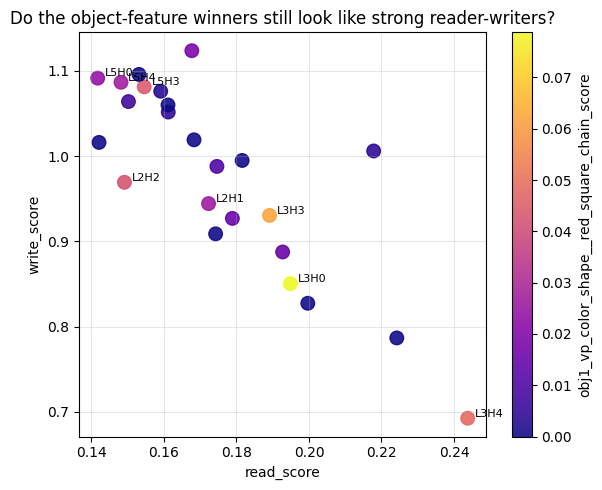

In [ ]:
# Object feature finding after OV-QK candidate discovery
#
# We build two probe families in caption-projection space:
# 1) whole token prototypes like `square` or `red_square`
# 2) variance-partition effect vectors that separate color / shape / color+shape
#
# Then we score later heads by direct OV write strength, VO/source overlap,
# QK compatibility with the source write vector, and the resulting chain score.
from utils.downstream_head_tracing import rank_candidate_heads_by_feature_probes

TRACE_FEATURE_PROBE_N_PERM = globals().get("TRACE_FEATURE_PROBE_N_PERM", 0)
TRACE_FEATURE_TOP_CANDIDATES = globals().get("TRACE_FEATURE_TOP_CANDIDATES", min(globals().get("TRACE_TOP_CANDIDATES", 8), 8))
TRACE_FEATURE_TARGET_OBJ = globals().get("TRACE_FEATURE_TARGET_OBJ", "obj1")
TRACE_FEATURE_TARGET_SHAPE = globals().get("TRACE_FEATURE_TARGET_SHAPE", "square")
TRACE_FEATURE_TARGET_COLOR = globals().get("TRACE_FEATURE_TARGET_COLOR", "red")

if "trace_candidate_rank_df" not in dir() or trace_candidate_rank_df is None or trace_candidate_rank_df.empty:
    raise RuntimeError("Run the OV-QK candidate discovery cell first.")

prompt_scene_info_all_df = prompt_scene_info_all_df.copy()
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"].astype(str) + "_" + prompt_scene_info_all_df["shape1"].astype(str)
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"].astype(str) + "_" + prompt_scene_info_all_df["shape2"].astype(str)

def prepare_probe_matrix(feature_matrix, labels):
    arr = np.asarray(feature_matrix, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Expected a rank-2 feature matrix, got shape {arr.shape}")
    if arr.shape[0] != len(labels) and arr.shape[1] == len(labels):
        arr = arr.T
    if arr.shape[0] != len(labels):
        raise ValueError(f"Could not align feature matrix shape {arr.shape} with {len(labels)} labels")
    return arr

def add_mean_probes(probe_vectors, probe_groups, meta_rows, feature_matrix, labels, prefix, probe_source):
    arr = prepare_probe_matrix(feature_matrix, labels)
    labels_ser = pd.Series(labels).astype(str)
    group_probe_names = []
    for label in pd.unique(labels_ser):
        idx = np.where(labels_ser.values == label)[0]
        probe_name = f"{prefix}__{label}"
        probe_vectors[probe_name] = arr[idx].mean(axis=0)
        group_probe_names.append(probe_name)
        meta_rows.append(
            {
                "probe_name": probe_name,
                "probe_group": prefix,
                "probe_label": str(label),
                "probe_source": probe_source,
                "n_rows": int(len(idx)),
            }
        )
    probe_groups[prefix] = group_probe_names

def add_effect_probes(probe_vectors, probe_groups, meta_rows, effect_vecs, levels_map, factor_key, prefix, probe_source):
    group_probe_names = []
    for label, vec in zip(levels_map[factor_key], effect_vecs[factor_key]):
        probe_name = f"{prefix}__{label}"
        probe_vectors[probe_name] = np.asarray(vec, dtype=np.float32)
        group_probe_names.append(probe_name)
        meta_rows.append(
            {
                "probe_name": probe_name,
                "probe_group": prefix,
                "probe_label": str(label),
                "probe_source": probe_source,
                "n_rows": 1,
            }
        )
    probe_groups[prefix] = group_probe_names

def resolve_probe_name(probe_vectors, prefix, target_label):
    name = f"{prefix}__{target_label}"
    if name in probe_vectors:
        return name
    matches = [probe_name for probe_name in probe_vectors.keys() if probe_name.startswith(f"{prefix}__")]
    return matches[0] if matches else None

probe_vectors = {}
probe_groups = {}
probe_meta_rows = []

add_mean_probes(
    probe_vectors,
    probe_groups,
    probe_meta_rows,
    wordvec_obj1_mat_proj.float().cpu().numpy(),
    prompt_scene_info_all_df["shape1"].astype(str).tolist(),
    prefix="obj1_whole_shape",
    probe_source="whole_projected_shape_token",
)
add_mean_probes(
    probe_vectors,
    probe_groups,
    probe_meta_rows,
    wordvec_obj2_mat_proj.float().cpu().numpy(),
    prompt_scene_info_all_df["shape2"].astype(str).tolist(),
    prefix="obj2_whole_shape",
    probe_source="whole_projected_shape_token",
)
add_mean_probes(
    probe_vectors,
    probe_groups,
    probe_meta_rows,
    wordvec_obj1_mat_proj.float().cpu().numpy(),
    prompt_scene_info_all_df["color1shape1"].astype(str).tolist(),
    prefix="obj1_whole_color_shape",
    probe_source="whole_projected_color_shape_token",
)
add_mean_probes(
    probe_vectors,
    probe_groups,
    probe_meta_rows,
    wordvec_obj2_mat_proj.float().cpu().numpy(),
    prompt_scene_info_all_df["color2shape2"].astype(str).tolist(),
    prefix="obj2_whole_color_shape",
    probe_source="whole_projected_color_shape_token",
)

trace_obj1_varpart_df, trace_obj1_intercept, trace_obj1_effect_vecs, trace_obj1_levels_map, trace_obj1_R2 = variance_partition_with_effects(
    wordvec_obj1_mat_proj.float().cpu().numpy(),
    {
        "color1": prompt_scene_info_all_df["color1"],
        "shape1": prompt_scene_info_all_df["shape1"],
        "color1shape1": prompt_scene_info_all_df["color1shape1"],
    },
    metric="euclidean",
    n_perm=TRACE_FEATURE_PROBE_N_PERM,
    verbose=False,
)
trace_obj2_varpart_df, trace_obj2_intercept, trace_obj2_effect_vecs, trace_obj2_levels_map, trace_obj2_R2 = variance_partition_with_effects(
    wordvec_obj2_mat_proj.float().cpu().numpy(),
    {
        "color2": prompt_scene_info_all_df["color2"],
        "shape2": prompt_scene_info_all_df["shape2"],
        "color2shape2": prompt_scene_info_all_df["color2shape2"],
    },
    metric="euclidean",
    n_perm=TRACE_FEATURE_PROBE_N_PERM,
    verbose=False,
)

add_effect_probes(probe_vectors, probe_groups, probe_meta_rows, trace_obj1_effect_vecs, trace_obj1_levels_map, "color1", "obj1_vp_color", "variance_partition_projected")
add_effect_probes(probe_vectors, probe_groups, probe_meta_rows, trace_obj1_effect_vecs, trace_obj1_levels_map, "shape1", "obj1_vp_shape", "variance_partition_projected")
add_effect_probes(probe_vectors, probe_groups, probe_meta_rows, trace_obj1_effect_vecs, trace_obj1_levels_map, "color1shape1", "obj1_vp_color_shape", "variance_partition_projected")
add_effect_probes(probe_vectors, probe_groups, probe_meta_rows, trace_obj2_effect_vecs, trace_obj2_levels_map, "color2", "obj2_vp_color", "variance_partition_projected")
add_effect_probes(probe_vectors, probe_groups, probe_meta_rows, trace_obj2_effect_vecs, trace_obj2_levels_map, "shape2", "obj2_vp_shape", "variance_partition_projected")
add_effect_probes(probe_vectors, probe_groups, probe_meta_rows, trace_obj2_effect_vecs, trace_obj2_levels_map, "color2shape2", "obj2_vp_color_shape", "variance_partition_projected")

trace_probe_catalog_df = pd.DataFrame(probe_meta_rows)
trace_feature_varpart_df = pd.concat(
    [
        trace_obj1_varpart_df.assign(object_slot="obj1"),
        trace_obj2_varpart_df.assign(object_slot="obj2"),
    ],
    ignore_index=True,
)

trace_feature_probe_rank_df = rank_candidate_heads_by_feature_probes(
    pipeline.transformer,
    SOURCE_REL_HEAD,
    probe_vectors=probe_vectors,
    probe_groups=probe_groups,
    candidate_layers=TRACE_CANDIDATE_LAYERS,
    source_rank=TRACE_SOURCE_RANK,
    show_progress=True,
    progress_desc="Score object feature probes",
)
trace_feature_probe_rank_df = trace_feature_probe_rank_df.merge(
    trace_candidate_rank_df[
        [
            "head_label",
            "layer_idx",
            "head_idx",
            "read_score",
            "write_score",
            "chain_score",
            "object_shape_score",
            "write_preference_score",
        ]
    ],
    on=["head_label", "layer_idx", "head_idx"],
    how="left",
)

trace_target_color_shape = f"{TRACE_FEATURE_TARGET_COLOR}_{TRACE_FEATURE_TARGET_SHAPE}"
trace_target_whole_shape_probe = resolve_probe_name(probe_vectors, f"{TRACE_FEATURE_TARGET_OBJ}_whole_shape", TRACE_FEATURE_TARGET_SHAPE)
trace_target_whole_color_shape_probe = resolve_probe_name(probe_vectors, f"{TRACE_FEATURE_TARGET_OBJ}_whole_color_shape", trace_target_color_shape)
trace_target_vp_shape_probe = resolve_probe_name(probe_vectors, f"{TRACE_FEATURE_TARGET_OBJ}_vp_shape", TRACE_FEATURE_TARGET_SHAPE)
trace_target_vp_color_shape_probe = resolve_probe_name(probe_vectors, f"{TRACE_FEATURE_TARGET_OBJ}_vp_color_shape", trace_target_color_shape)

trace_feature_primary_score = globals().get(
    "TRACE_FEATURE_PRIMARY_SCORE",
    next(
        col
        for col in [
            f"{trace_target_vp_color_shape_probe}_chain_score" if trace_target_vp_color_shape_probe else None,
            f"{trace_target_whole_color_shape_probe}_chain_score" if trace_target_whole_color_shape_probe else None,
            f"{trace_target_vp_shape_probe}_chain_score" if trace_target_vp_shape_probe else None,
            f"{trace_target_whole_shape_probe}_chain_score" if trace_target_whole_shape_probe else None,
        ]
        if col is not None and col in trace_feature_probe_rank_df.columns
    ),
)

trace_feature_probe_rank_df = trace_feature_probe_rank_df.sort_values(
    [trace_feature_primary_score, "write_score", "read_score"],
    ascending=[False, False, False],
).reset_index(drop=True)
trace_feature_probe_rank_df["feature_probe_rank"] = np.arange(1, len(trace_feature_probe_rank_df) + 1)

selected_probe_cols = []
for probe_name in [
    trace_target_whole_shape_probe,
    trace_target_whole_color_shape_probe,
    trace_target_vp_shape_probe,
    trace_target_vp_color_shape_probe,
]:
    if probe_name is None:
        continue
    for suffix in ["vo_probe_norm_norm", "vo_source_cosine", "qk_cosine", "chain_score"]:
        col = f"{probe_name}_{suffix}"
        if col in trace_feature_probe_rank_df.columns:
            selected_probe_cols.append(col)

trace_feature_summary_cols = [
    "feature_probe_rank",
    "head_label",
    trace_feature_primary_score,
    "read_score",
    "write_score",
    "chain_score",
    "object_shape_score",
    "write_preference_score",
    *selected_probe_cols,
]
trace_feature_summary_cols = [c for c in trace_feature_summary_cols if c in trace_feature_probe_rank_df.columns]
trace_feature_top_df = trace_feature_probe_rank_df[trace_feature_summary_cols].head(TRACE_FEATURE_TOP_CANDIDATES).copy()

trace_feature_group_rows = []
for probe_group in sorted(probe_groups):
    chain_col = f"{probe_group}_chain_score_max"
    vo_col = f"{probe_group}_vo_probe_norm_norm_max"
    if chain_col in trace_feature_probe_rank_df.columns:
        best_chain_row = trace_feature_probe_rank_df.sort_values(chain_col, ascending=False).iloc[0]
        trace_feature_group_rows.append(
            {
                "probe_group": probe_group,
                "best_head_by_chain": best_chain_row["head_label"],
                "best_probe_by_chain": best_chain_row.get(f"{probe_group}_best_probe_by_chain", None),
                "chain_score_max": float(best_chain_row[chain_col]),
                "best_head_read_score": float(best_chain_row["read_score"]) if np.isfinite(best_chain_row.get("read_score", np.nan)) else np.nan,
                "best_head_write_score": float(best_chain_row["write_score"]) if np.isfinite(best_chain_row.get("write_score", np.nan)) else np.nan,
                "best_head_by_vo": None,
                "best_probe_by_vo": None,
                "vo_probe_norm_norm_max": np.nan,
            }
        )
    if vo_col in trace_feature_probe_rank_df.columns:
        best_vo_row = trace_feature_probe_rank_df.sort_values(vo_col, ascending=False).iloc[0]
        existing = next((row for row in trace_feature_group_rows if row["probe_group"] == probe_group), None)
        if existing is None:
            existing = {"probe_group": probe_group}
            trace_feature_group_rows.append(existing)
        existing["best_head_by_vo"] = best_vo_row["head_label"]
        existing["best_probe_by_vo"] = best_vo_row.get(f"{probe_group}_best_probe_by_vo", None)
        existing["vo_probe_norm_norm_max"] = float(best_vo_row[vo_col])

trace_feature_group_winners_df = pd.DataFrame(trace_feature_group_rows)

print(f"Feature probes built: {len(trace_probe_catalog_df)}")
print(f"Primary object-feature score: {trace_feature_primary_score}")
print(f"Target object slot / label request: {TRACE_FEATURE_TARGET_OBJ} / {trace_target_color_shape}")
print("Resolved target probes:")
print({
    "whole_shape": trace_target_whole_shape_probe,
    "whole_color_shape": trace_target_whole_color_shape_probe,
    "vp_shape": trace_target_vp_shape_probe,
    "vp_color_shape": trace_target_vp_color_shape_probe,
})
print("Projected-space variance partition (obj1 / obj2):")
display(trace_feature_varpart_df)
print("Top head per probe family (whole vectors and variance-partition effects):")
display(trace_feature_group_winners_df)
print("Top heads under the selected object-feature score:")
display(trace_feature_top_df)

plot_cols = [c for c in selected_probe_cols if c in trace_feature_top_df.columns]
if plot_cols:
    heat_df = trace_feature_top_df[["head_label", *plot_cols]].copy()
    fig, ax = plt.subplots(figsize=(0.9 * len(plot_cols) + 3.5, 0.48 * len(heat_df) + 2.5))
    im = ax.imshow(heat_df[plot_cols].to_numpy(dtype=float), aspect="auto", cmap="magma")
    ax.set_title("Object-feature probe scores for top candidate heads")
    ax.set_xlabel("Probe metric")
    ax.set_ylabel("Head")
    ax.set_xticks(range(len(plot_cols)))
    ax.set_xticklabels([
        col.replace("_vo_probe_norm_norm", "\nVO").replace("_vo_source_cosine", "\nVO-source cos").replace("_qk_cosine", "\nQK cos").replace("_chain_score", "\nchain")
        for col in plot_cols
    ], rotation=35, ha="right")
    ax.set_yticks(range(len(heat_df)))
    ax.set_yticklabels(heat_df["head_label"])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

if trace_feature_primary_score in trace_feature_probe_rank_df.columns and {"read_score", "write_score"}.issubset(trace_feature_probe_rank_df.columns):
    plot_df = trace_feature_probe_rank_df.head(min(TRACE_FEATURE_TOP_CANDIDATES, len(trace_feature_probe_rank_df))).copy()
    fig, ax = plt.subplots(figsize=(6.0, 5.0))
    sc = ax.scatter(
        trace_feature_probe_rank_df["read_score"],
        trace_feature_probe_rank_df["write_score"],
        c=trace_feature_probe_rank_df[trace_feature_primary_score],
        s=95,
        cmap="plasma",
        alpha=0.88,
    )
    for row in plot_df.itertuples():
        ax.text(row.read_score + 0.002, row.write_score + 0.002, row.head_label, fontsize=8)
    ax.set_xlabel("read_score")
    ax.set_ylabel("write_score")
    ax.set_title("Do the object-feature winners still look like strong reader-writers?")
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(trace_feature_primary_score)
    plt.tight_layout()
    plt.show()


## Section C - Head Screening (Alignment Scan)

Scores all cross-attention heads by alignment to relation directions and saves a ranked table used to pick candidate relation heads for visualization and ablation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def ramp_alignment_metrics(M, dvec, eps=1e-12):
    """
    Returns:
      cosine     : [-1, 1] alignment with spatial direction (scale-free)
      projection : signed magnitude of alignment (units of M)
    """
    H, W = M.shape
    d = np.array(dvec)
    d = d / np.linalg.norm(d)
    
    # coordinate grid
    xs = np.linspace(-1, 1, W)
    ys = np.linspace(-1, 1, H)
    X, Y = np.meshgrid(xs, ys)

    # ramp template
    T = d[0] * X + d[1] * Y
    T = T - T.mean()                      # remove DC (important!)
    T_norm = np.linalg.norm(T) + eps
    T_unit = T / T_norm                   # unit template

    # centered map
    # A = M.astype(float)
    A = M - M.mean()
    A_norm = np.linalg.norm(A) + eps

    # (1) signed projection magnitude
    projection = np.sum(A * T / T_norm)

    # (2) cosine / correlation
    cosine = projection / A_norm

    return dict(
        cosine=cosine,
        projection=projection,
        energy=A_norm,
        template_norm=T_norm,
    )


def visualize_direction_vectors(H=8, W=8):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    # Visualize the template ramps in 2x4 subplots
    H, W = 8, 8  # set the dimensions of the grid (adjust if appropriate)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for idx, (name, dvec) in enumerate(direction_vector.items()):
        xs = np.linspace(-1, 1, W)
        ys = np.linspace(-1, 1, H)
        X, Y = np.meshgrid(xs, ys)
        d = np.array(dvec)
        d = d / np.linalg.norm(d)
        T = d[0] * X + d[1] * Y
        T = T - T.mean()
        
        ax = axes[idx // 4, idx % 4]
        im = ax.imshow(T, cmap='coolwarm')
        ax.set_title(name)
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# visualize_direction_vectors()
# inner_prod_mat[:, i_word:i_word+1].view(8, 8)
# plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
# plt.title(f"{levels_map['spatial_relationship'][i_word]}")
def eval_ramp_alignment_all(inner_prod_mat, spatial_relationship_levels, eps=1e-12):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    i_word = 1
    align_dict_list = []
    for i_word in range(len(spatial_relationship_levels)):
        rel_name = spatial_relationship_levels[i_word]
        dvec = direction_vector[rel_name]
        align_dict = ramp_alignment_metrics(inner_prod_mat[:, i_word:i_word+1].view(8, 8).detach().cpu().numpy(), dvec, eps=1e-12)
        align_dict["rel_name"] = rel_name
        align_dict["dvec"] = (dvec[0], dvec[1])
        align_dict["dir_idx"] = i_word
        align_dict_list.append(align_dict)
    # align_dict_list
    align_df = pd.DataFrame(align_dict_list)
    return align_df

In [ ]:
from utils.pixart_pos_embed import get_2d_sincos_pos_embed

In [ ]:
from tqdm import tqdm
from itertools import product
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
print(f"Model: {config.model} — {layer_num} layers, {head_num} heads, hidden_size={hidden_size}, head_dim={head_dim}")

# Make this cell robust to out-of-order execution.
if "effect_vecs" not in dir() or "levels_map" not in dir() or "spatial_relationship" not in effect_vecs:
    if "wordvec_obj2_mat_proj" not in dir():
        raise RuntimeError("Missing wordvec_obj2_mat_proj. Run Section B embedding projection cell first.")
    _df_rel = prompt_scene_info_all_df.copy()
    _df_rel["color1shape1"] = _df_rel["color1"].astype(str) + "_" + _df_rel["shape1"].astype(str)
    _df_rel["color2shape2"] = _df_rel["color2"].astype(str) + "_" + _df_rel["shape2"].astype(str)
    var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(
        wordvec_obj2_mat_proj.float().cpu().numpy(),
        {
            "spatial_relationship": _df_rel["spatial_relationship"],
            "shape1": _df_rel["shape1"],
            "color2shape2": _df_rel["color2shape2"],
        },
        metric="euclidean",
        n_perm=100,
        verbose=False,
    )

align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads = pd.concat(align_df_list)

Model: PixArt_mini_2 — 6 layers, 6 heads, hidden_size=384, head_dim=64


0it [00:00, ?it/s]


NameError: name 'effect_vecs' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
figroot = "/Users/julianali/Desktop/DiffusionInterp/Figures/DiT_T5_attn_head_finding"
figdir = join(figroot, model_run_name)
os.makedirs(figdir, exist_ok=True)

Top spatial heads (by |cosine| > 0.7):
  Layer 0, Head 0: cosine=0.98, proj=78.2, energy=79
  Layer 1, Head 0: cosine=0.79, proj=16.4, energy=19
  Layer 1, Head 1: cosine=-0.72, proj=-14.6, energy=20
  Layer 1, Head 2: cosine=-0.99, proj=-38.4, energy=39
  Layer 2, Head 0: cosine=-0.81, proj=-11.6, energy=14
  Layer 2, Head 1: cosine=-0.88, proj=-15.7, energy=18
  Layer 2, Head 2: cosine=-0.92, proj=-16.1, energy=17
  Layer 2, Head 5: cosine=-0.87, proj=-8.5, energy=10
  Layer 3, Head 1: cosine=-0.73, proj=-10.6, energy=14
  Layer 3, Head 4: cosine=-0.86, proj=-7.1, energy=8
  Layer 3, Head 5: cosine=-0.76, proj=-4.9, energy=6


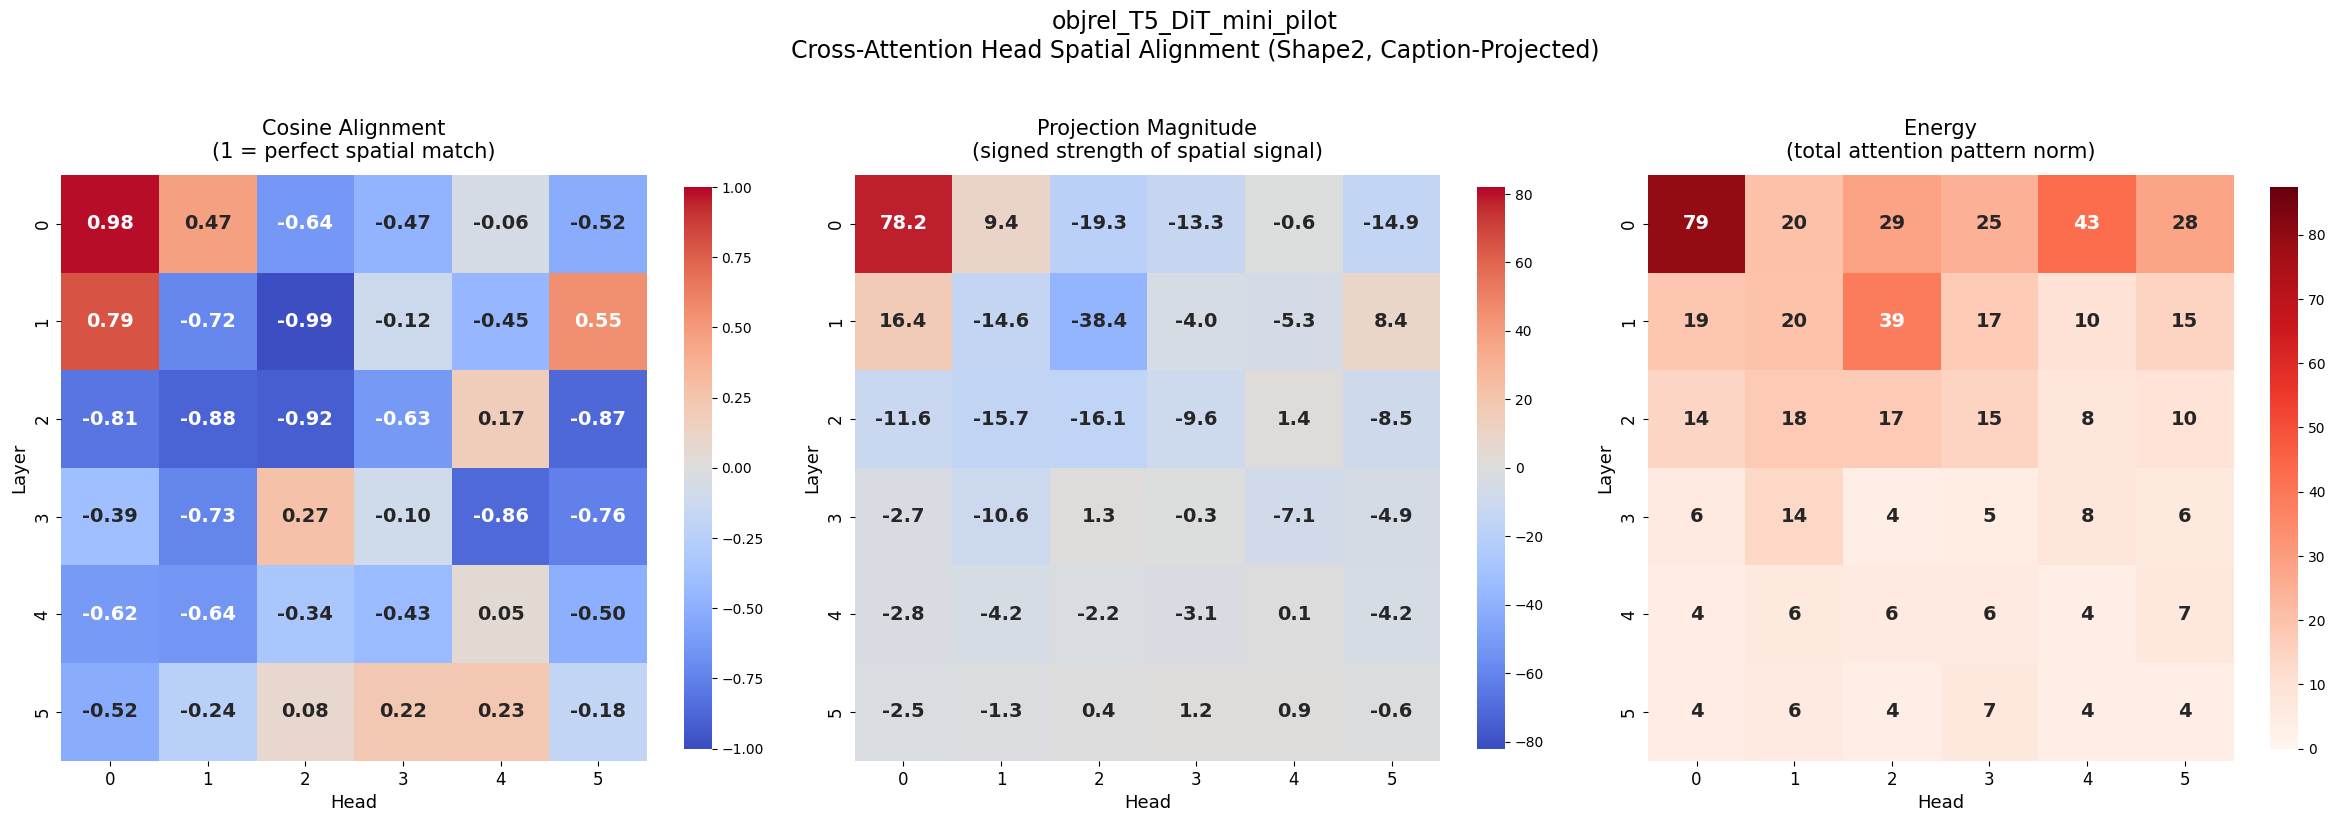

In [ ]:
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_align_score_allheads_shape2_MLP_proj_rel_factor.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)

metrics = ["cosine", "projection", "energy"]
titles = [
    "Cosine Alignment\n(1 = perfect spatial match)",
    "Projection Magnitude\n(signed strength of spatial signal)",
    "Energy\n(total attention pattern norm)",
]
n_metrics = len(metrics)

# Use data-driven color limits for projection so weak heads aren't washed out
proj_max = max(abs(head_align_synopsis["projection"].min()), abs(head_align_synopsis["projection"].max()))
energy_max = head_align_synopsis["energy"].max()

fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 8), squeeze=False)
for idx, metric, clim, fmt, title in zip(
    range(n_metrics), metrics,
    [(-1, 1), (-proj_max * 1.05, proj_max * 1.05), (0, energy_max * 1.1)],
    [".2f", ".1f", ".0f"],
    titles,
):
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    cmap = "Reds" if metric == "energy" else "coolwarm"
    sns.heatmap(
        heatmap_data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True,
        vmin=clim[0], vmax=clim[1],
        annot_kws={"size": 14, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.tick_params(labelsize=12)

# Highlight top spatial heads
print("Top spatial heads (by |cosine| > 0.7):")
for _, row in head_align_synopsis.iterrows():
    if abs(row["cosine"]) > 0.7:
        l, h = row.name
        print(f"  Layer {l}, Head {h}: cosine={row['cosine']:.2f}, proj={row['projection']:.1f}, energy={row['energy']:.0f}")

fig.suptitle(
    f"{model_run_name}\nCross-Attention Head Spatial Alignment (Shape2, Caption-Projected)",
    fontsize=17, y=1.03,
)
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis_shape2_MLP_proj_rel_factor")
plt.show()

### Section C.1 - Shape1/Object1 Alignment Scan

Repeats the head-alignment computation for object1 (shape1) features to compare whether heads encode object identity vs spatial relation.

In [ ]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("shape2, T5 embedding, caption projection")
var_part_df_S1, intercept_S1, effect_vecs_S1, levels_map_S1, R2_total_S1 = variance_partition_with_effects(wordvec_obj1_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
            #  "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
            #  "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df_S1

shape2, T5 embedding, caption projection
Total R2 (all features): 0.700482
Total R² (all features): 0.7005


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,spatial_relationship,8,7,213,7730.268487,796.853278,0.103082,796.853278,0.103082,0.256041,0.009901
1,shape2,3,2,213,7730.268487,1192.148542,0.154218,772.199720,0.099893,0.250101,0.009901
2,color1shape1,6,5,213,7730.268487,3845.859736,0.497507,3425.910914,0.443181,0.596717,0.009901


In [ ]:
from tqdm import tqdm
from itertools import product
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

if "effect_vecs_S1" not in dir() or "levels_map_S1" not in dir() or "spatial_relationship" not in effect_vecs_S1:
    if "wordvec_obj1_mat_proj" not in dir():
        raise RuntimeError("Missing wordvec_obj1_mat_proj. Run Section B embedding projection cell first.")
    _df_rel_s1 = prompt_scene_info_all_df.copy()
    _df_rel_s1["color1shape1"] = _df_rel_s1["color1"].astype(str) + "_" + _df_rel_s1["shape1"].astype(str)
    _df_rel_s1["color2shape2"] = _df_rel_s1["color2"].astype(str) + "_" + _df_rel_s1["shape2"].astype(str)
    var_part_df_S1, intercept_S1, effect_vecs_S1, levels_map_S1, R2_total_S1 = variance_partition_with_effects(
        wordvec_obj1_mat_proj.float().cpu().numpy(),
        {
            "spatial_relationship": _df_rel_s1["spatial_relationship"],
            "shape2": _df_rel_s1["shape2"],
            "color1shape1": _df_rel_s1["color1shape1"],
        },
        metric="euclidean",
        n_perm=100,
        verbose=False,
    )

align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = effect_vecs_S1["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_S1["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads_S1 = pd.concat(align_df_list)


0it [00:00, ?it/s]

36it [00:00, 316.19it/s]


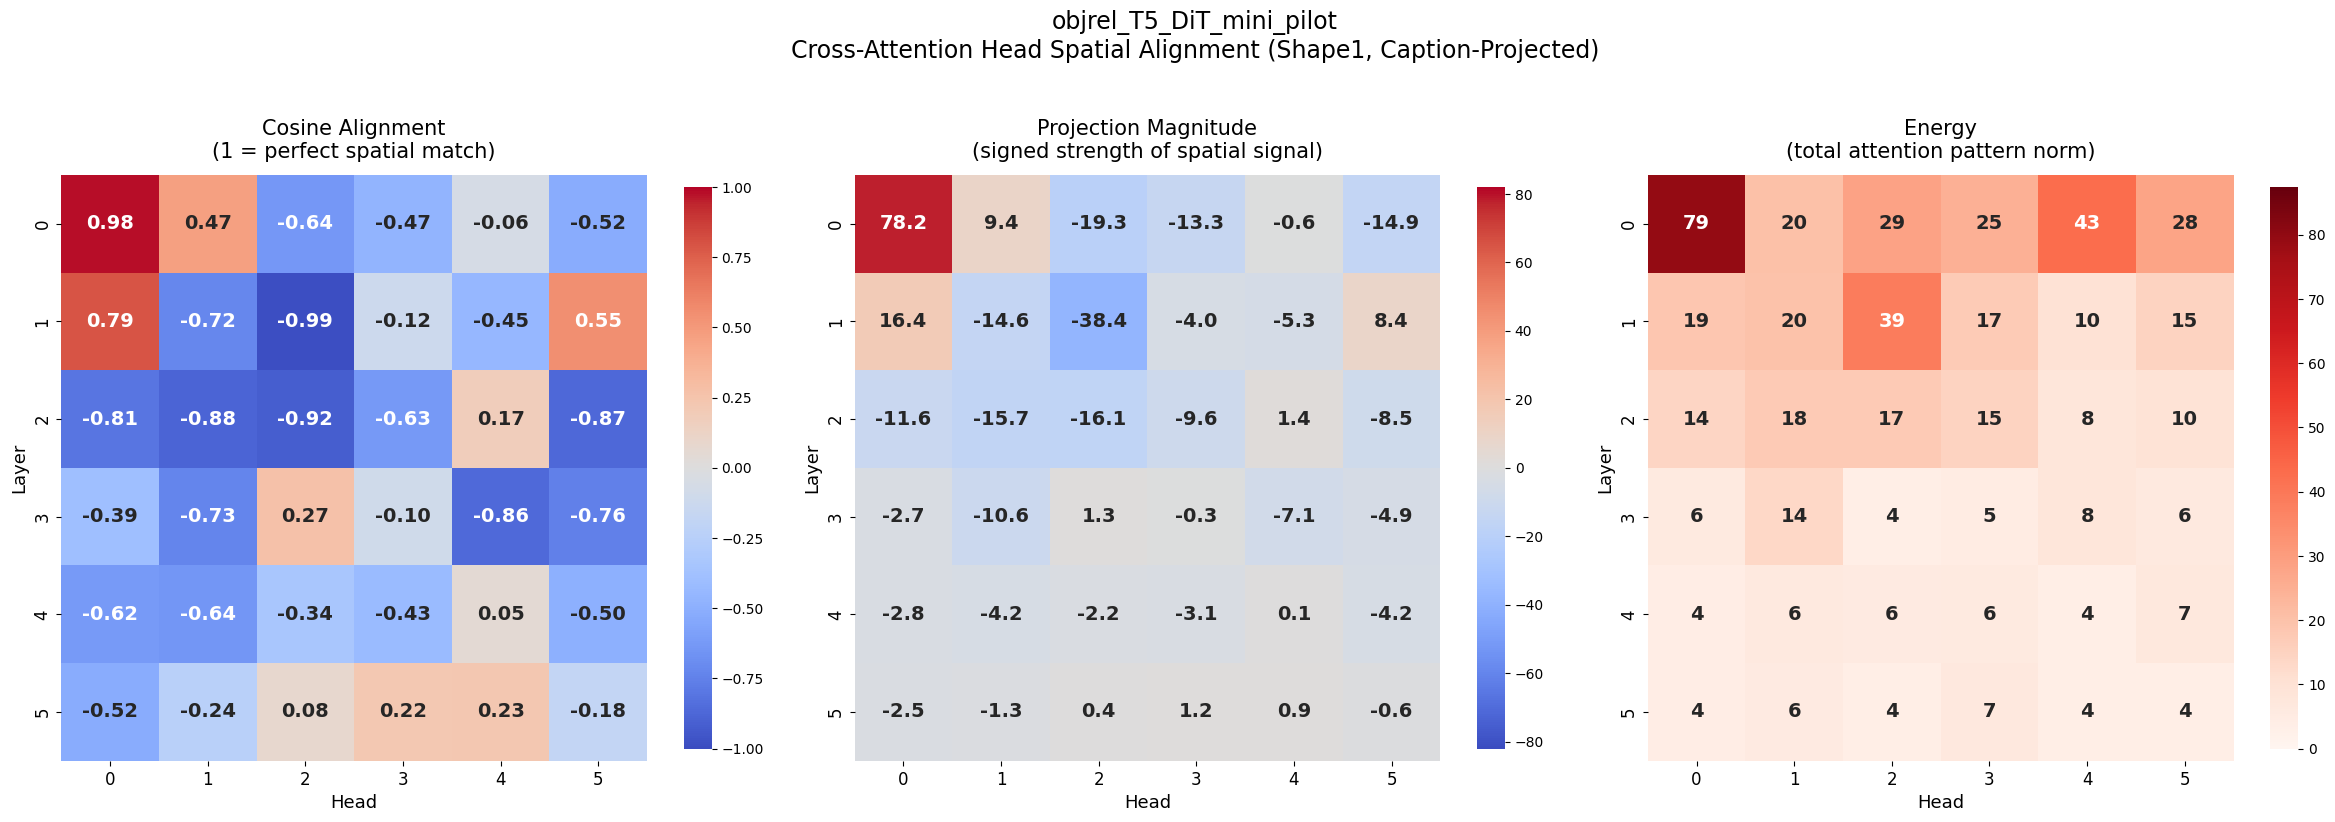

In [ ]:
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_align_score_allheads_shape1_MLP_proj_rel_factor.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)

metrics = ["cosine", "projection", "energy"]
titles = [
    "Cosine Alignment\n(1 = perfect spatial match)",
    "Projection Magnitude\n(signed strength of spatial signal)",
    "Energy\n(total attention pattern norm)",
]
n_metrics = len(metrics)

proj_max = max(abs(head_align_synopsis["projection"].min()), abs(head_align_synopsis["projection"].max()))
energy_max = head_align_synopsis["energy"].max()

fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 8), squeeze=False)
for idx, metric, clim, fmt, title in zip(
    range(n_metrics), metrics,
    [(-1, 1), (-proj_max * 1.05, proj_max * 1.05), (0, energy_max * 1.1)],
    [".2f", ".1f", ".0f"],
    titles,
):
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    cmap = "Reds" if metric == "energy" else "coolwarm"
    sns.heatmap(
        heatmap_data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True,
        vmin=clim[0], vmax=clim[1],
        annot_kws={"size": 14, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.tick_params(labelsize=12)

fig.suptitle(
    f"{model_run_name}\nCross-Attention Head Spatial Alignment (Shape1, Caption-Projected)",
    fontsize=17, y=1.03,
)
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis_shape1_MLP_proj_rel_factor")
plt.show()

### Section C.2 - Selective Head Visualization

Generates focused plots for selected high-value heads/layers so you can quickly inspect spatial ramp structure without scanning all heads.

Text(0.5, 0.98, 'objrel_T5_DiT_mini_pilot\nL0H0 pos embed inner product with spatial relation factors in Caption Projection')

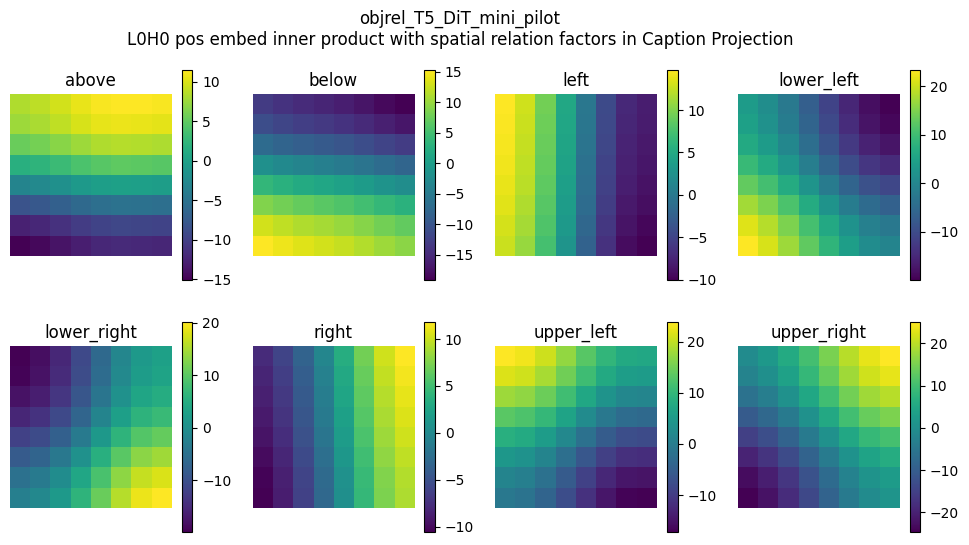

In [ ]:
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
# Pick a layer/head to inspect — update after seeing the heatmaps above
layer_idx, head_idx = 0,0

if "effect_vecs" not in dir() or "levels_map" not in dir() or "spatial_relationship" not in effect_vecs:
    if "wordvec_obj2_mat_proj" not in dir():
        raise RuntimeError("Missing wordvec_obj2_mat_proj. Run Section B embedding projection cell first.")
    _df_rel = prompt_scene_info_all_df.copy()
    _df_rel["color1shape1"] = _df_rel["color1"].astype(str) + "_" + _df_rel["shape1"].astype(str)
    _df_rel["color2shape2"] = _df_rel["color2"].astype(str) + "_" + _df_rel["shape2"].astype(str)
    var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(
        wordvec_obj2_mat_proj.float().cpu().numpy(),
        {
            "spatial_relationship": _df_rel["spatial_relationship"],
            "shape1": _df_rel["shape1"],
            "color2shape2": _df_rel["color2shape2"],
        },
        metric="euclidean",
        n_perm=100,
        verbose=False,
    )

target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.flatten()
for i_word in range(len(effect_vecs["spatial_relationship"])):
    plt.sca(axs[i_word])
    attn_score = inner_prod_mat[:, i_word:i_word+1]
    plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
    plt.title(f"{levels_map['spatial_relationship'][i_word]}")
    plt.axis("off")
    plt.colorbar()
plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with spatial relation factors in Caption Projection")

In [ ]:
from utils.pixart_utils import PixArt_model_configs
def compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, feature_vecs, levels_names=None, 
                                   model_run_name="model", device=device, visualize=True):
    """
    Visualize the inner product between 2D positional embeddings and target effect vectors for specified head/layer.
    """
    transformer_config = PixArt_model_configs[config.model] if config is not None else PixArt_model_configs["PixArt_mini_2"]
    hidden_size = transformer_config["hidden_size"]
    head_num = transformer_config["num_heads"]
    layer_num = transformer_config["depth"]
    base_size = 16 // 2
    head_dim = hidden_size // head_num

    target_embedding_direction = feature_vecs[:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
    if visualize:
        num_levels = len(feature_vecs)
        nrows, ncols = (2, 4) if num_levels == 8 else (1, num_levels)
        fig, axs = plt.subplots(nrows, ncols, figsize=(12, 6))
        axs = axs.flatten() if hasattr(axs, "flatten") else [axs]

        for i_word in range(num_levels):
            plt.sca(axs[i_word])
            attn_score = inner_prod_mat[:, i_word:i_word+1]
            plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
            if levels_names is not None:
                plt.title(f"{levels_names[i_word]}")
            else:
                plt.title(f"{i_word}")
            plt.axis("off")
            plt.colorbar()
        plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with {len(feature_vecs)} factors in Caption Projection")
        plt.tight_layout()
        plt.show()
    else:
        fig = None
    return inner_prod_mat, fig

### Trace spatial heads through training

**Goal:** See how cross-attention head spatial alignment evolves across checkpoints.

**Key insight:** T5 embeddings are frozen → same raw embeddings for all checkpoints.  
But the **caption projection (MLP)** and **cross-attention weights** are trained → we must:
1. Load each checkpoint
2. Project cached T5 embeddings through that checkpoint's caption_projection
3. Run variance partition on projected embeddings (effect_vecs differ per checkpoint)
4. Run head alignment using that checkpoint's attn2 weights + effect_vecs

In [ ]:
# Define checkpoints to trace (epoch, step) and load order
ckpt_files = [
    "epoch_100_step_4000.pth",
    "epoch_250_step_10000.pth",
    "epoch_500_step_20000.pth",
    "epoch_1000_step_40000.pth",
    "epoch_2000_step_80000.pth",
    "epoch_4000_step_160000.pth",
]
# Fine-grained checkpoints for 500–1000 (relation head emergence)
ckpt_files_emergence = [
    "epoch_500_step_20000.pth",
    "epoch_600_step_24000.pth",
    "epoch_700_step_28000.pth",
    "epoch_750_step_30000.pth",
    "epoch_800_step_32000.pth",
    "epoch_900_step_36000.pth",
    "epoch_1000_step_40000.pth",
]
# Extended ablation: emergence + later checkpoints (2000, 4000) where relation head should be stronger
ckpt_files_ablation = ckpt_files_emergence + [
    "epoch_2000_step_80000.pth",
    "epoch_4000_step_160000.pth",
]
ckptdir = join(savedir, "checkpoints")
print(f"Full trace: {len(ckpt_files)} checkpoints | Emergence (500–1000): {len(ckpt_files_emergence)} | Ablation sweep: {len(ckpt_files_ablation)}")

Full trace: 6 checkpoints | Emergence (500–1000): 7 | Ablation sweep: 9


In [ ]:
# For each checkpoint: load, project embeddings, variance partition, head alignment
# Results stored in evolution_records (list of DataFrames, one per checkpoint)

n_perm_evolution = 50  # Reduce for faster run (original uses 100)
evolution_records = []
var_part_evolution = []
q_norms_evolution = []
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

for ckpt_name in tqdm(ckpt_files, desc="Checkpoints"):
    # 1. Load checkpoint into transformer (reuse existing pipeline structure)
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    load_pixart_ema_into_transformer(pipeline.transformer, ckpt['state_dict_ema'])
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    
    # 2. Project cached T5 embeddings through this checkpoint's caption_projection
    wordvec_obj1_col, wordvec_obj2_col = [], []
    for row in prompt_scene_info_all_df.itertuples():
        cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
        tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
        tokens = [pipeline.tokenizer.decode([token_id]) for token_id in tokenized['input_ids'][0]]
        shape1_mask_idx = find_shape_index(tokens, row.shape1)
        shape2_mask_idx = find_shape_index(tokens, row.shape2)
        wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
        wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
    wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
    wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
    with torch.no_grad():
        wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
        wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
    
    # 3. Variance partition on projected embeddings (Shape2)
    df = prompt_scene_info_all_df.copy()
    df["color1shape1"] = df["color1"] + "_" + df["shape1"]
    df["color2shape2"] = df["color2"] + "_" + df["shape2"]
    var_part_df_ckpt, _, effect_vecs_ckpt, levels_map_ckpt, R2_total_ckpt = variance_partition_with_effects(
        wordvec_obj2_mat_proj.float().cpu().numpy(),
        {"spatial_relationship": df["spatial_relationship"], "shape1": df["shape1"], "color2shape2": df["color2shape2"]},
        metric="euclidean", n_perm=n_perm_evolution, verbose=False)
    
    # 4. Head alignment for this checkpoint
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_ckpt["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_ckpt["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    
    align_df = pd.concat(align_df_list)
    head_synopsis = align_df.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["checkpoint"] = ckpt_name
    epoch = int(ckpt_name.split("_")[1])
    head_synopsis["epoch"] = epoch
    evolution_records.append(head_synopsis.reset_index())
    
    # Variance partition: R² per factor (MLP-projected embedding)
    var_part_ckpt = var_part_df_ckpt.copy()
    var_part_ckpt["epoch"] = epoch
    var_part_ckpt["checkpoint"] = ckpt_name
    if ckpt_name == ckpt_files[0]:
        var_part_evolution = [var_part_ckpt]
    else:
        var_part_evolution.append(var_part_ckpt)
    
    # Q weight norms per head (cross-attention projection)
    q_norms_ckpt = []
    for layer_idx in range(layer_num):
        q_w = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q.weight.float()
        q_heads = q_w.view(head_num, head_dim, -1)
        for head_idx in range(head_num):
            q_norms_ckpt.append({
                "epoch": epoch, "checkpoint": ckpt_name,
                "layer_idx": layer_idx, "head_idx": head_idx,
                "q_norm": q_heads[head_idx].norm().item(),
            })
    if ckpt_name == ckpt_files[0]:
        q_norms_evolution = q_norms_ckpt
    else:
        q_norms_evolution.extend(q_norms_ckpt)

Checkpoints: 100%|██████████| 6/6 [00:05<00:00,  1.05it/s]


In [ ]:
# Combine all checkpoint results into one evolution DataFrame
evolution_df = pd.concat(evolution_records, ignore_index=True)
evolution_df = evolution_df.sort_values(["epoch", "layer_idx", "head_idx"]).reset_index(drop=True)

var_part_evolution = globals().get('var_part_evolution', [])
q_norms_evolution = globals().get('q_norms_evolution', [])
var_part_df_evolution = pd.concat(var_part_evolution, ignore_index=True) if var_part_evolution else pd.DataFrame()
q_norms_df = pd.DataFrame(q_norms_evolution) if q_norms_evolution else pd.DataFrame()

print(evolution_df.head(6))
print(f"\nEvolution: {len(evolution_df)} rows | Var partition: {len(var_part_df_evolution)} rows | Q norms: {len(q_norms_df)} rows")
if var_part_df_evolution.empty or q_norms_df.empty:
    print("\n⚠ Run the evolution loop (cell above) first to populate var_part_evolution and q_norms_evolution.")

   layer_idx  head_idx    cosine  projection    energy  template_norm  \
0          0         0  0.062626    0.008058  0.043573       5.237229   
1          0         1 -0.134555   -0.001923  0.058366       5.237229   
2          0         2 -0.111684   -0.003656  0.024893       5.237229   
3          0         3 -0.076353   -0.002659  0.030721       5.237229   
4          0         4  0.132962    0.004712  0.044418       5.237229   
5          0         5  0.177412    0.009673  0.062580       5.237229   

   dir_idx               checkpoint  epoch  
0      3.5  epoch_100_step_4000.pth    100  
1      3.5  epoch_100_step_4000.pth    100  
2      3.5  epoch_100_step_4000.pth    100  
3      3.5  epoch_100_step_4000.pth    100  
4      3.5  epoch_100_step_4000.pth    100  
5      3.5  epoch_100_step_4000.pth    100  

Evolution: 216 rows | Var partition: 18 rows | Q norms: 216 rows


#### Evolution of key spatial heads over training

Plot cosine, projection, and energy for the top heads (e.g., L0H0, L1H2) across epochs.

Plotting evolution for: [(0, 0), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (2, 5), (3, 1), (3, 4), (3, 5)]


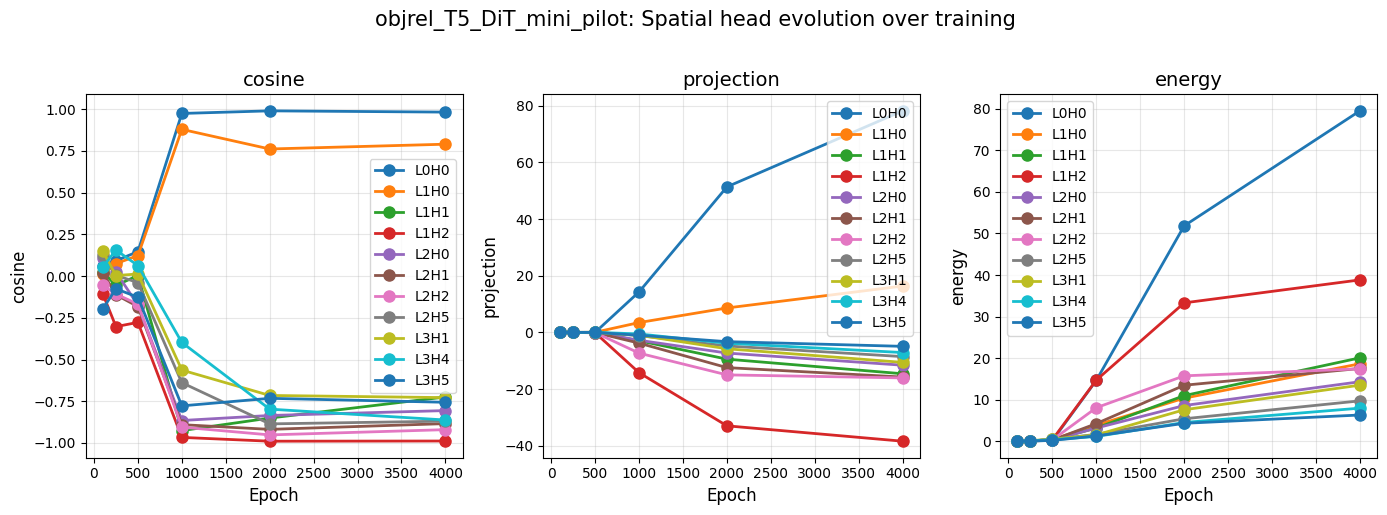

In [ ]:
# Plot evolution of top spatial heads (auto-pick from final checkpoint |cosine| > 0.7)
final_ckpt = evolution_df[evolution_df["epoch"] == evolution_df["epoch"].max()]
top_heads = []
for _, row in final_ckpt.iterrows():
    if abs(row["cosine"]) > 0.7:
        top_heads.append((int(row["layer_idx"]), int(row["head_idx"])))
if not top_heads:
    top_heads = [(0, 0), (1, 2), (2, 3)]
print(f"Plotting evolution for: {top_heads}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["cosine", "projection", "energy"]):
    for layer_idx, head_idx in top_heads:
        subset = evolution_df[(evolution_df["layer_idx"] == layer_idx) & (evolution_df["head_idx"] == head_idx)]
        ax.plot(subset["epoch"], subset[metric], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=8)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle(f"{model_run_name}: Spatial head evolution over training", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

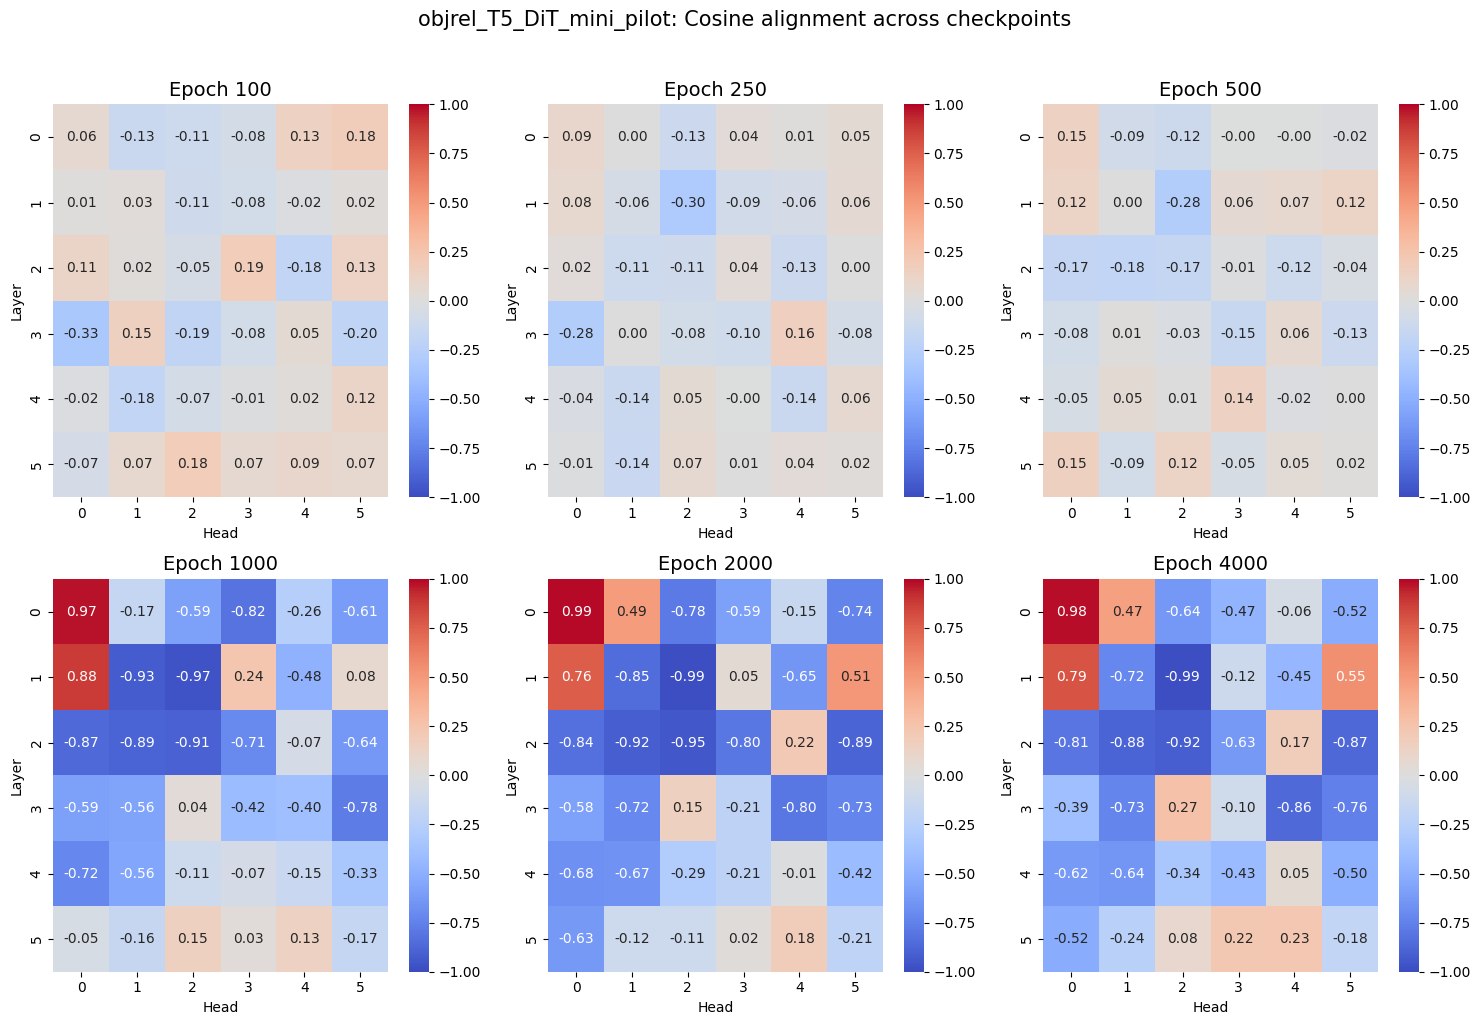

In [ ]:
# Cosine alignment heatmaps across all checkpoints
epochs = sorted(evolution_df["epoch"].unique())
n_ckpts = len(epochs)
ncols = 3
nrows = (n_ckpts + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)

for idx, epoch in enumerate(epochs):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df[evolution_df["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")

for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)

plt.suptitle(f"{model_run_name}: Cosine alignment across checkpoints", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### Heatmap comparison: early vs late checkpoint

Cosine alignment heatmaps at epoch 100 vs epoch 4000.

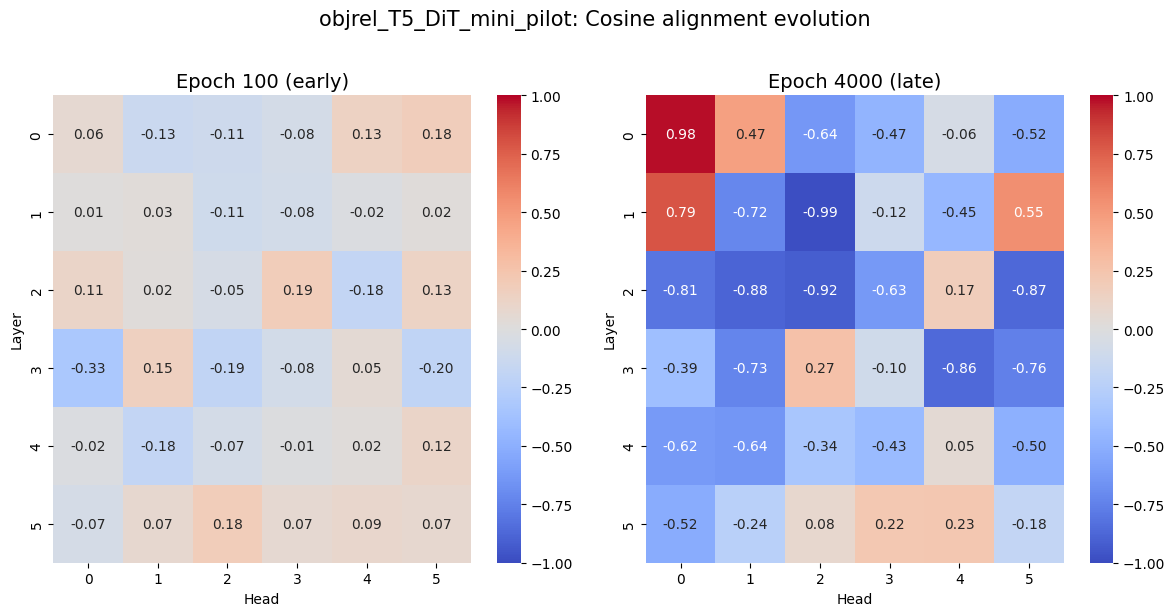

In [ ]:
# Early vs late checkpoint — cosine alignment heatmaps
early = evolution_df[evolution_df["epoch"] == 100]
late = evolution_df[evolution_df["epoch"] == 4000]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, df_sub, title in [
    (axes[0], early, "Epoch 100 (early)"),
    (axes[1], late, "Epoch 4000 (late)"),
]:
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
plt.suptitle(f"{model_run_name}: Cosine alignment evolution", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### Fixed relation direction (from final checkpoint)

Same cosine alignment, but using the spatial_relationship effect vectors from the **final checkpoint only** — the relation direction is fixed; only the attn2 weights change across checkpoints.

Fixed direction: 100%|██████████| 6/6 [00:01<00:00,  3.01it/s]


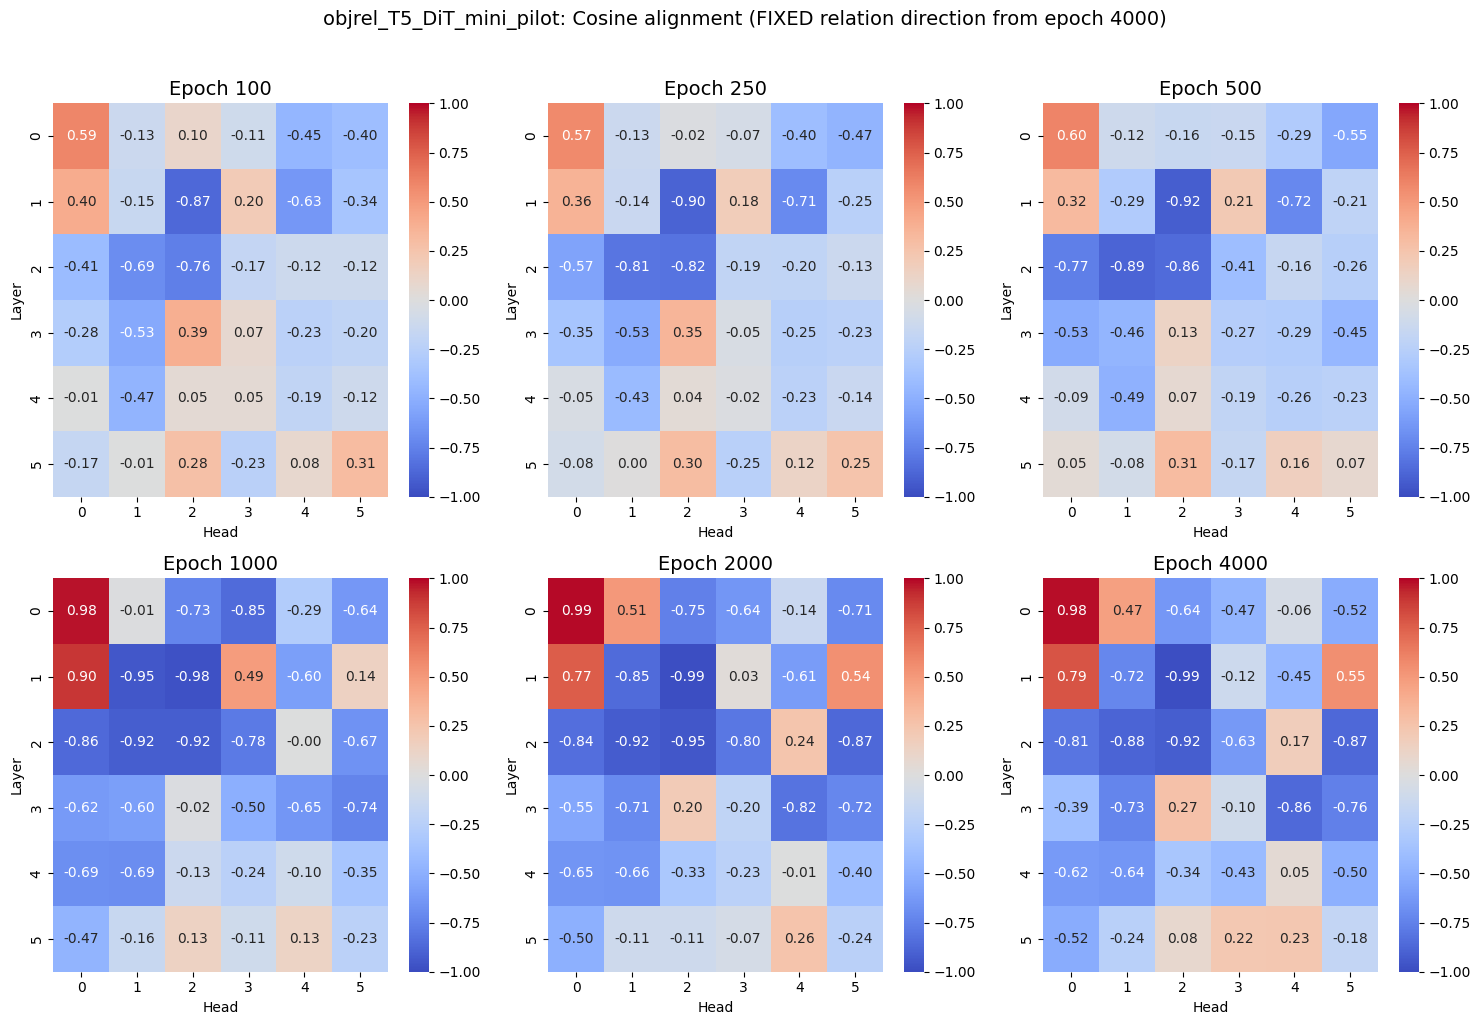

14008

In [ ]:
# 1. Get fixed relation direction from final checkpoint
ckpt_final = "epoch_4000_step_160000.pth"
ckpt = torch.load(join(ckptdir, ckpt_final), map_location="cpu", weights_only=False)
load_pixart_ema_into_transformer(pipeline.transformer, ckpt['state_dict_ema'])
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt
gc.collect()

# Project embeddings, variance partition → fixed effect_vecs
df_tmp = prompt_scene_info_all_df.copy()
df_tmp["color1shape1"] = df_tmp["color1"] + "_" + df_tmp["shape1"]
df_tmp["color2shape2"] = df_tmp["color2"] + "_" + df_tmp["shape2"]
wordvec_obj2_col = []
for row in prompt_scene_info_all_df.itertuples():
    tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
    tokens = [pipeline.tokenizer.decode([t]) for t in tokenized['input_ids'][0]]
    shape2_idx = find_shape_index(tokens, row.shape2)
    cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
    wordvec_obj2_col.append(cap_embeds[0, shape2_idx, :])
wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
with torch.no_grad():
    wordvec_obj2_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
_, _, effect_vecs_fixed, levels_map_fixed, _ = variance_partition_with_effects(
    wordvec_obj2_proj.float().cpu().numpy(),
    {"spatial_relationship": df_tmp["spatial_relationship"], "shape1": df_tmp["shape1"], "color2shape2": df_tmp["color2shape2"]},
    metric="euclidean", n_perm=n_perm_evolution, verbose=False)

# 2. For each checkpoint: load attn2, compute alignment with FIXED effect_vecs
evolution_records_fixed = []
for ckpt_name in tqdm(ckpt_files, desc="Fixed direction"):
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    load_pixart_ema_into_transformer(pipeline.transformer, ckpt['state_dict_ema'])
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    epoch = int(ckpt_name.split("_")[1])
    
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_fixed["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_fixed["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    head_synopsis = pd.concat(align_df_list).groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["epoch"] = epoch
    head_synopsis["checkpoint"] = ckpt_name
    evolution_records_fixed.append(head_synopsis.reset_index())

evolution_df_fixed = pd.concat(evolution_records_fixed, ignore_index=True)

# 3. Plot heatmaps (same layout as above)
epochs_f = sorted(evolution_df_fixed["epoch"].unique())
n_ckpts = len(epochs_f)
ncols, nrows = 3, (n_ckpts + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)
for idx, epoch in enumerate(epochs_f):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df_fixed[evolution_df_fixed["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)
plt.suptitle(f"{model_run_name}: Cosine alignment (FIXED relation direction from epoch 4000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Reload final checkpoint for downstream cells
ckpt = torch.load(join(ckptdir, ckpt_final), map_location="cpu", weights_only=False)
load_pixart_ema_into_transformer(pipeline.transformer, ckpt['state_dict_ema'])
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt
gc.collect()

### Relation head emergence (epochs 500–1000)

Fine-grained view using checkpoints 500, 600, 700, 750, 800, 900, 1000 — where the spatial relation head becomes identifiable.

In [ ]:
# Run evolution for emergence checkpoints only (500–1000)
# Uses same config as main loop (layer_num, head_num, etc. from cell 32)
transformer_config = PixArt_model_configs[config.model] if config is not None else PixArt_model_configs["PixArt_mini_2"]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

evo_em_records, var_part_em, q_norms_em = [], [], []
for ckpt_name in tqdm(ckpt_files_emergence, desc="Emergence checkpoints"):
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    load_pixart_ema_into_transformer(pipeline.transformer, ckpt['state_dict_ema'])
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    epoch = int(ckpt_name.split("_")[1])
    df = prompt_scene_info_all_df.copy()
    df["color1shape1"] = df["color1"] + "_" + df["shape1"]
    df["color2shape2"] = df["color2"] + "_" + df["shape2"]
    
    wordvec_obj2_col = []
    for row in prompt_scene_info_all_df.itertuples():
        tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
        tokens = [pipeline.tokenizer.decode([t]) for t in tokenized['input_ids'][0]]
        shape2_idx = find_shape_index(tokens, row.shape2)
        cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
        wordvec_obj2_col.append(cap_embeds[0, shape2_idx, :])
    wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
    with torch.no_grad():
        wordvec_obj2_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
    
    var_part_ckpt, _, effect_vecs_ckpt, levels_map_ckpt, _ = variance_partition_with_effects(
        wordvec_obj2_proj.float().cpu().numpy(),
        {"spatial_relationship": df["spatial_relationship"], "shape1": df["shape1"], "color2shape2": df["color2shape2"]},
        metric="euclidean", n_perm=n_perm_evolution, verbose=False)
    var_part_ckpt = var_part_ckpt.copy()
    var_part_ckpt["epoch"] = epoch
    var_part_em.append(var_part_ckpt)
    
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_ckpt["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_ckpt["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    head_synopsis = pd.concat(align_df_list).groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["epoch"] = epoch
    head_synopsis["checkpoint"] = ckpt_name
    evo_em_records.append(head_synopsis.reset_index())
    
    for layer_idx in range(layer_num):
        q_w = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q.weight.float()
        q_heads = q_w.view(head_num, head_dim, -1)
        for head_idx in range(head_num):
            q_norms_em.append({"epoch": epoch, "layer_idx": layer_idx, "head_idx": head_idx, "q_norm": q_heads[head_idx].norm().item()})

evolution_df_em = pd.concat(evo_em_records, ignore_index=True)
var_part_df_em = pd.concat(var_part_em, ignore_index=True)
q_norms_df_em = pd.DataFrame(q_norms_em)
print(f"Emergence data: {len(evolution_df_em)} alignment rows, {len(var_part_df_em)} var partition rows")

Emergence checkpoints: 100%|██████████| 7/7 [00:05<00:00,  1.18it/s]

Emergence data: 252 alignment rows, 21 var partition rows


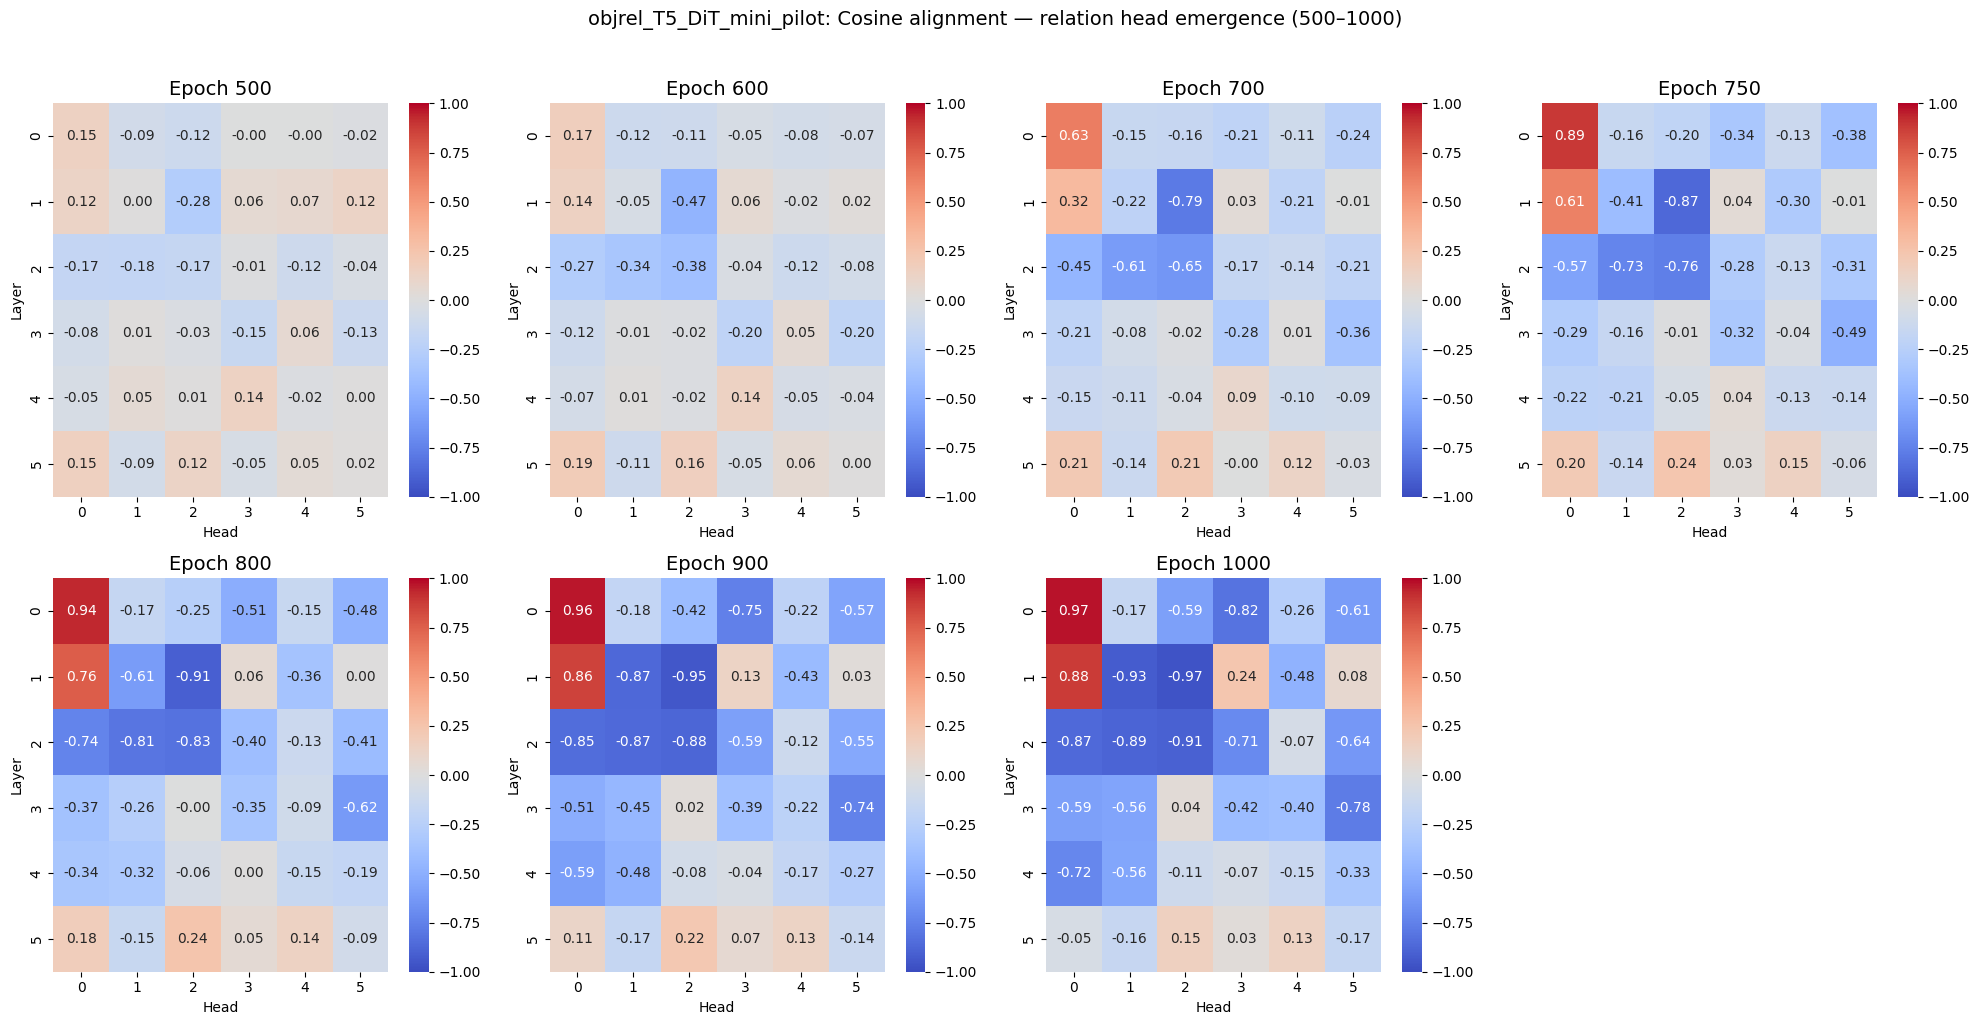

In [ ]:
# Cosine alignment heatmaps: 500–1000 (relation head emergence)
epochs_em = sorted(evolution_df_em["epoch"].unique())
n_ckpts = len(epochs_em)
ncols = 4
nrows = (n_ckpts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)
for idx, epoch in enumerate(epochs_em):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df_em[evolution_df_em["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)
plt.suptitle(f"{model_run_name}: Cosine alignment — relation head emergence (500–1000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

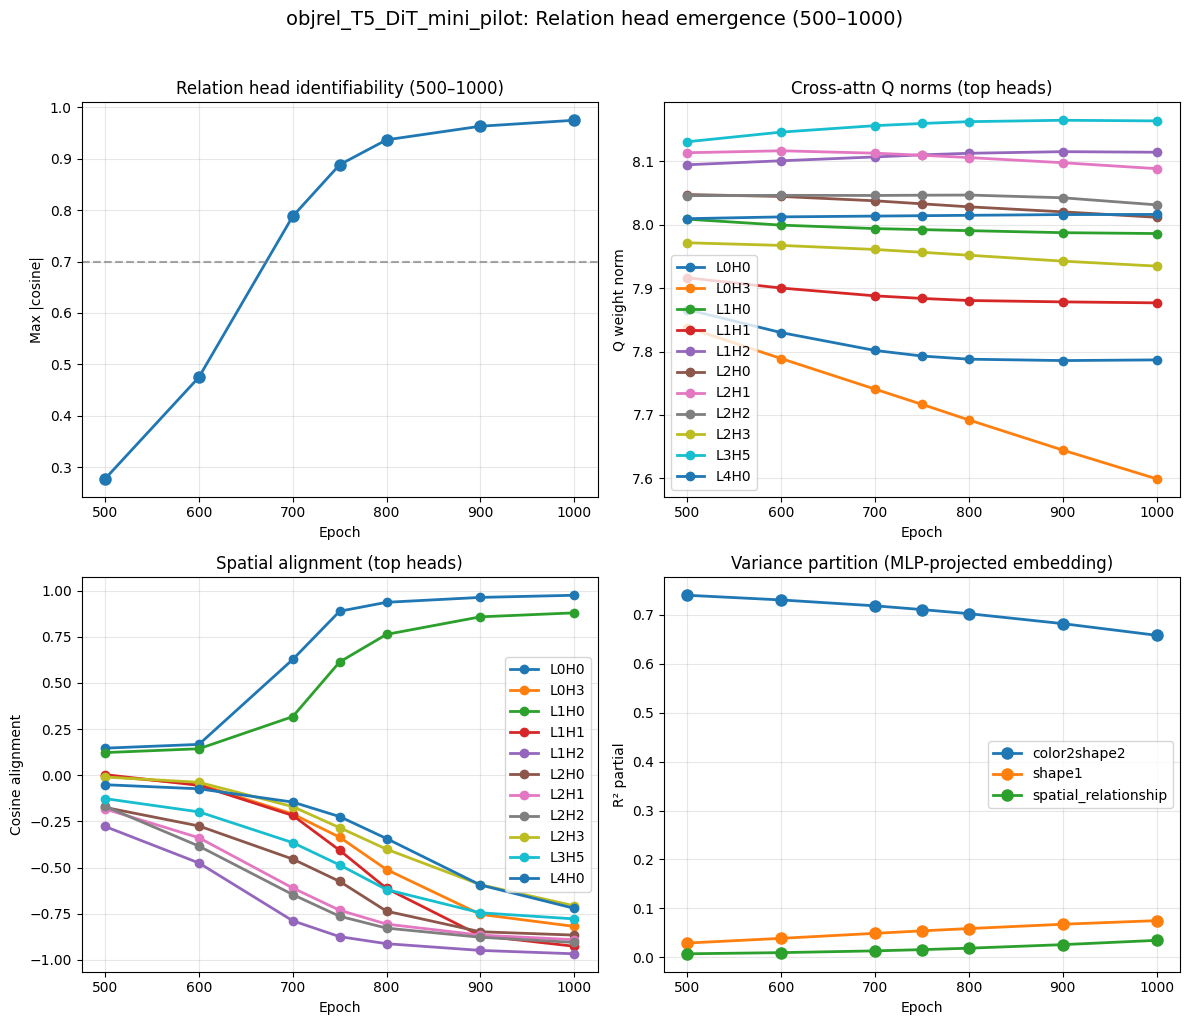

In [ ]:
# Emergence: identifiability, projection norms, variance partition
top_em = []
for _, row in evolution_df_em[evolution_df_em["epoch"] == evolution_df_em["epoch"].max()].iterrows():
    if abs(row["cosine"]) > 0.7:
        top_em.append((int(row["layer_idx"]), int(row["head_idx"])))
if not top_em:
    top_em = [(0, 0), (1, 2), (2, 3)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Max |cosine| and gap
id_em = []
for epoch in sorted(evolution_df_em["epoch"].unique()):
    sub = evolution_df_em[evolution_df_em["epoch"] == epoch]
    abs_cos = sub["cosine"].abs()
    max_idx = abs_cos.idxmax()
    row = sub.loc[max_idx]
    top_layer, top_head = int(row["layer_idx"]), int(row["head_idx"])
    mean_other = sub[(sub["layer_idx"] != top_layer) | (sub["head_idx"] != top_head)]["cosine"].abs().mean()
    id_em.append({"epoch": epoch, "max_abs_cosine": abs(row["cosine"]), "gap": abs(row["cosine"]) - mean_other})
id_em = pd.DataFrame(id_em)
axes[0, 0].plot(id_em["epoch"], id_em["max_abs_cosine"], "o-", linewidth=2, markersize=8)
axes[0, 0].axhline(0.7, color="gray", linestyle="--", alpha=0.7)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Max |cosine|")
axes[0, 0].set_title("Relation head identifiability (500–1000)")
axes[0, 0].grid(True, alpha=0.3)

# (b) Q norms for top heads
for layer_idx, head_idx in top_em:
    sub = q_norms_df_em[(q_norms_df_em["layer_idx"] == layer_idx) & (q_norms_df_em["head_idx"] == head_idx)]
    axes[0, 1].plot(sub["epoch"], sub["q_norm"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Q weight norm")
axes[0, 1].set_title("Cross-attn Q norms (top heads)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# (c) Cosine for top heads
for layer_idx, head_idx in top_em:
    sub = evolution_df_em[(evolution_df_em["layer_idx"] == layer_idx) & (evolution_df_em["head_idx"] == head_idx)]
    axes[1, 0].plot(sub["epoch"], sub["cosine"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Cosine alignment")
axes[1, 0].set_title("Spatial alignment (top heads)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# (d) Variance partition (R² partial)
vp_em = var_part_df_em.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
for col in vp_em.columns:
    axes[1, 1].plot(vp_em.index, vp_em[col], "o-", label=col, linewidth=2, markersize=8)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("R² partial")
axes[1, 1].set_title("Variance partition (MLP-projected embedding)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"{model_run_name}: Relation head emergence (500–1000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

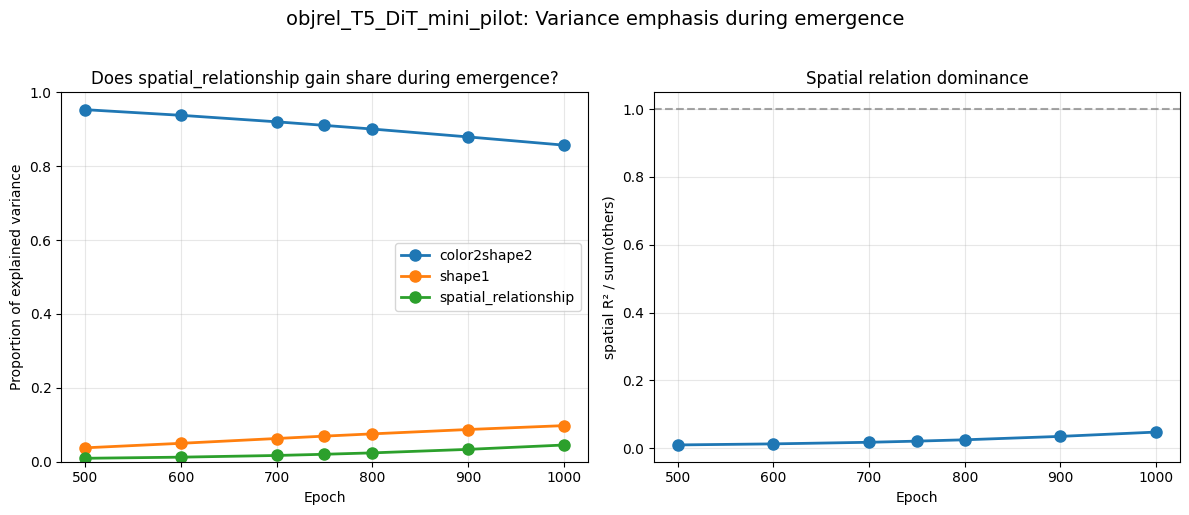

In [ ]:
# Emergence: variance proportion and spatial dominance
vp_em = var_part_df_em.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
vp_prop_em = vp_em.div(vp_em.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for col in vp_prop_em.columns:
    axes[0].plot(vp_prop_em.index, vp_prop_em[col], "o-", label=col, linewidth=2, markersize=8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Proportion of explained variance")
axes[0].set_title("Does spatial_relationship gain share during emergence?")
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

if "spatial_relationship" in vp_em.columns:
    others = [c for c in vp_em.columns if c != "spatial_relationship"]
    ratio_em = vp_em["spatial_relationship"] / (vp_em[others].sum(axis=1) + 1e-10)
    axes[1].plot(vp_em.index, ratio_em, "o-", color="C0", linewidth=2, markersize=8)
    axes[1].axhline(1, color="gray", linestyle="--", alpha=0.7)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("spatial R² / sum(others)")
    axes[1].set_title("Spatial relation dominance")
    axes[1].grid(True, alpha=0.3)
plt.suptitle(f"{model_run_name}: Variance emphasis during emergence", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Method-integrated robustness: emergence / phase-transition stability (multi-seed + held-out)

Bootstrap the emergence alignment analysis across held-out prompts and `ROBUSTNESS_SEEDS` to test whether the same heads dominate the transition period, rather than relying on a single prompt sample.

In [ ]:
import gc
import torch
import pandas as pd
from os.path import basename, join

from utils.pixart_utils import load_pixart_ema_into_transformer
from utils.multi_seed_robustness import multi_bootstrap_head_alignment
from utils.ablation_eval_prompts import build_heldout_generalization_prompts

EMERGENCE_ROBUSTNESS_TOP_K = int(globals().get("EMERGENCE_ROBUSTNESS_TOP_K", 6))
EMERGENCE_ROBUSTNESS_N_PERM = int(globals().get("EMERGENCE_ROBUSTNESS_N_PERM", 24))
EMERGENCE_ROBUSTNESS_BASE_SIZE = int(globals().get("EMERGENCE_ROBUSTNESS_BASE_SIZE", 8))

if "ckpt_files_emergence" in dir() and ckpt_files_emergence:
    EMERGENCE_ROBUSTNESS_CHECKPOINTS = globals().get(
        "EMERGENCE_ROBUSTNESS_CHECKPOINTS",
        [ckpt_files_emergence[0], ckpt_files_emergence[-1]],
    )
else:
    EMERGENCE_ROBUSTNESS_CHECKPOINTS = globals().get("EMERGENCE_ROBUSTNESS_CHECKPOINTS", [])

if "prompt_scene_info_all_df" not in dir() or "embedding_allrel_allobj" not in dir():
    print("Skip: need prompt_scene_info_all_df and embedding_allrel_allobj first.")
elif len(EMERGENCE_ROBUSTNESS_CHECKPOINTS) == 0:
    print("Skip: no emergence robustness checkpoints configured.")
else:
    heldout_prompts_em, _, heldout_meta_em = build_heldout_generalization_prompts(
        prompt_scene_info_all_df,
        embedding_allrel_allobj,
        exclude_pairs=globals().get("HELDOUT_EXCLUDE_PAIRS", [("blue", "circle", "red", "square")]),
        n_per_relation=int(globals().get("HELDOUT_N_PER_RELATION", 3)),
        max_prompts=int(globals().get("HELDOUT_MAX_PROMPTS", 24)),
    )
    if heldout_meta_em.empty:
        print("Skip: held-out validation set is empty for emergence robustness.")
    else:
        heldout_meta_em = heldout_meta_em.copy()
        heldout_meta_em["color1shape1"] = heldout_meta_em["color1"].astype(str) + "_" + heldout_meta_em["shape1"].astype(str)
        heldout_meta_em["color2shape2"] = heldout_meta_em["color2"].astype(str) + "_" + heldout_meta_em["shape2"].astype(str)

        emergence_robust_rows = []
        emergence_robust_tables = []

        for ckpt_name in EMERGENCE_ROBUSTNESS_CHECKPOINTS:
            ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
            load_pixart_ema_into_transformer(pipeline.transformer, ckpt["state_dict_ema"])
            pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
            del ckpt
            gc.collect()

            epoch = int(basename(ckpt_name).split("_")[1]) if "epoch_" in basename(ckpt_name) else -1

            wordvec_obj2_col = []
            for row in heldout_meta_em.itertuples():
                tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
                tokens = [pipeline.tokenizer.decode([t]) for t in tokenized["input_ids"][0]]
                shape2_idx = find_shape_index(tokens, row.shape2)
                cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]["caption_embeds"]
                wordvec_obj2_col.append(cap_embeds[0, shape2_idx, :])
            wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
            with torch.no_grad():
                wordvec_obj2_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))

            stab_df, _, _ = multi_bootstrap_head_alignment(
                pipeline.transformer,
                wordvec_obj2_proj.float().cpu().numpy(),
                heldout_meta_em,
                vp_features=["spatial_relationship", "shape1", "color2shape2"],
                seeds=ROBUSTNESS_SEEDS,
                n_perm=EMERGENCE_ROBUSTNESS_N_PERM,
                top_k=EMERGENCE_ROBUSTNESS_TOP_K,
                base_size=EMERGENCE_ROBUSTNESS_BASE_SIZE,
                verbose=False,
            )
            if stab_df.empty:
                continue
            stab_df = stab_df.copy()
            stab_df["epoch"] = epoch
            stab_df["checkpoint"] = basename(ckpt_name)
            emergence_robust_tables.append(stab_df)
            best = stab_df.iloc[0]
            emergence_robust_rows.append(
                {
                    "epoch": epoch,
                    "checkpoint": basename(ckpt_name),
                    "top_stable_head": f"L{int(best['layer'])}H{int(best['head'])}",
                    "top_head_in_topk_frac": float(best["in_topk_frac"]),
                    "n_unique_heads_in_topk": int(stab_df[["layer", "head"]].drop_duplicates().shape[0]),
                }
            )

        emergence_robust_summary_df = pd.DataFrame(emergence_robust_rows).sort_values("epoch").reset_index(drop=True) if emergence_robust_rows else pd.DataFrame()
        emergence_robust_stability_df = pd.concat(emergence_robust_tables, ignore_index=True) if emergence_robust_tables else pd.DataFrame()

        print(
            f"Emergence robustness on held-out prompts: n_prompts={len(heldout_prompts_em)}, "
            f"checkpoints={len(EMERGENCE_ROBUSTNESS_CHECKPOINTS)}, seeds={ROBUSTNESS_SEEDS}"
        )
        if emergence_robust_summary_df.empty:
            print("No emergence robustness rows produced.")
        else:
            display(emergence_robust_summary_df)
            display(emergence_robust_stability_df.sort_values(["epoch", "in_topk_frac"], ascending=[True, False]))

---
## Ablation experiments

**What ablation can reveal:**

1. **Behavioral dependence** — Does ablating the head hurt spatial accuracy? (accuracy drop)
2. **Geometric vs behavioral timing** — Does the head align with spatial direction *before* ablation hurts? If so, geometric specialization precedes behavioral criticality.
3. **Head specificity** — Ablating the best-aligned head vs a random/anti-aligned head: only the relation head should matter.
4. **Control** — Ablating a random head should have minimal effect; ablating an anti-aligned head might *improve* accuracy (if it opposes spatial relations).

**Config below:** Edit `HEAD_SELECTION_MODE`, `ABLATION_LAYER_IX`, `ABLATION_HEAD_IX`, etc. to run different experiments.

**Execution order (cells below, top → bottom):**
1. **Early Ablation Sweep** — run the sweep code cell first (defines `prompts_ablation`, cache, `ablation_df_out`).
2. **Multi-head ablation** — runs *after* the sweep; reuses those variables.
3. **Plots / random-head / qualitative** — use `ablation_df_out` from the sweep.


### Early Ablation Sweep

**Design:** At each emergence checkpoint (500–1000), ablate the candidate relation head and measure spatial relation accuracy.

- **Baseline:** Generate images with no ablation → evaluate spatial correctness.
- **Ablated:** Zero-out the candidate relation head (layer, head from max |cosine| at that epoch) → evaluate.
- **Hypothesis:** Early checkpoints (500–600): ablation has little effect (head not yet specialized). Late checkpoints (800–1000): ablation hurts spatial accuracy (head is critical).

In [ ]:
# Ablation sweep — configurable head selection and metrics
from utils.zero_head_ablation_utils import apply_zero_head_ablation, restore_processors
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings
from utils.ablation_eval_prompts import (
    build_training_template_prompts,
    build_diverse_subset_prompts,
    build_heldout_generalization_prompts,
    eval_means_line,
)

# ========== EDIT THESE PARAMETERS ==========
HEAD_SELECTION_MODE = "best_aligned"   # "best_aligned" | "specific_head" | "worst_aligned" | "random"
ABLATION_LAYER_IX = 0                  # used when mode="specific_head" (0–5 for 6 layers)
ABLATION_HEAD_IX = 0                   # used when mode="specific_head" (0–5 for 6 heads)
ABLATION_CHECKPOINTS = None            # None = use ckpt_files_ablation; or list e.g. ["epoch_500_step_20000.pth", ...]
# Prompt set — **major effect on accuracy levels**:
# - "training_template" = blue circle / red square, all relations (same as training-style single-pair template)
# - "diverse" = mixed combinatorial color/shape prompts
# - "heldout_generalization" = excludes training template pair(s), validate-only split
ABLATION_PROMPT_MODE = "heldout_generalization"
N_ABLATION_PROMPTS = 12                # used when ABLATION_PROMPT_MODE == "diverse"
HELDOUT_N_PER_RELATION = 3             # used when ABLATION_PROMPT_MODE == "heldout_generalization"
HELDOUT_MAX_PROMPTS = 24               # cap for held-out validation prompts
HELDOUT_EXCLUDE_PAIRS = [("blue", "circle", "red", "square")]  # held out from validation set
N_IMAGES_PER_PROMPT = 5
ABLATION_GUIDANCE_SCALE = 4.5  # match training / local eval; 1.0 often yields ~0% spatial accuracy
# ==========================================

embedding_cache_ablation = dict(embedding_allrel_allobj)
if "" not in embedding_cache_ablation:
    raise ValueError("Embedding cache needs '' key for uncond. Re-run precompute_t5_embeddings.py.")

if ABLATION_PROMPT_MODE == "training_template":
    _ds = ShapesDataset(num_images=100)
    prompts_ablation, scene_infos_ablation = build_training_template_prompts(
        embedding_cache_ablation, _ds.spatial_phrases
    )
    prompt_split_name = "train_template"
    prompt_split_meta_df = pd.DataFrame(scene_infos_ablation)
    print(f"ABLATION_PROMPT_MODE=training_template: {len(prompts_ablation)} prompts (cached), aligned with training-style single-pair template")
elif ABLATION_PROMPT_MODE == "diverse":
    prompts_ablation, scene_infos_ablation = build_diverse_subset_prompts(
        prompt_scene_info_all_df, embedding_cache_ablation, n_prompts=N_ABLATION_PROMPTS
    )
    prompt_split_name = "diverse_mixed"
    prompt_split_meta_df = pd.DataFrame(scene_infos_ablation)
    print(f"ABLATION_PROMPT_MODE=diverse: {len(prompts_ablation)} prompts (harder; expect low strict spatial vs training_template)")
elif ABLATION_PROMPT_MODE == "heldout_generalization":
    prompts_ablation, scene_infos_ablation, prompt_split_meta_df = build_heldout_generalization_prompts(
        prompt_scene_info_all_df,
        embedding_cache_ablation,
        exclude_pairs=HELDOUT_EXCLUDE_PAIRS,
        n_per_relation=HELDOUT_N_PER_RELATION,
        max_prompts=HELDOUT_MAX_PROMPTS,
    )
    prompt_split_name = "heldout_validation"
    if len(prompts_ablation) == 0:
        raise RuntimeError("Held-out validation split is empty. Adjust HELDOUT_EXCLUDE_PAIRS / HELDOUT_N_PER_RELATION.")
    print(
        f"ABLATION_PROMPT_MODE=heldout_generalization: {len(prompts_ablation)} prompts "
        f"(validate-only; excluded pairs={HELDOUT_EXCLUDE_PAIRS})"
    )
else:
    raise ValueError(f"Unknown ABLATION_PROMPT_MODE: {ABLATION_PROMPT_MODE}")

ckpt_list = ABLATION_CHECKPOINTS if ABLATION_CHECKPOINTS is not None else ckpt_files_ablation
ablation_records = []
n_prompts = len(prompts_ablation)
total_steps = len(ckpt_list) * 2 * n_prompts
pbar = tqdm(total=total_steps, desc=f"Ablation ({HEAD_SELECTION_MODE})", unit="prompt", mininterval=2)

for ckpt_name in ckpt_list:
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    load_pixart_ema_into_transformer(pipeline.transformer, ckpt["state_dict_ema"])
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    epoch = int(ckpt_name.split("_")[1])
    df_ep = evolution_df_em[evolution_df_em["epoch"] == epoch] if epoch <= 1000 else evolution_df[evolution_df["epoch"] == epoch]
    if df_ep.empty:
        continue

    # Select head to ablate based on mode
    if HEAD_SELECTION_MODE == "specific_head":
        layer_idx, head_idx = ABLATION_LAYER_IX, ABLATION_HEAD_IX
        row_ep = df_ep[(df_ep["layer_idx"] == layer_idx) & (df_ep["head_idx"] == head_idx)]
        cosine_at_epoch = float(row_ep["cosine"].iloc[0]) if not row_ep.empty else np.nan
    elif HEAD_SELECTION_MODE == "best_aligned":
        best = df_ep.loc[df_ep["cosine"].abs().idxmax()]
        layer_idx, head_idx = int(best["layer_idx"]), int(best["head_idx"])
        cosine_at_epoch = float(best["cosine"])
    elif HEAD_SELECTION_MODE == "worst_aligned":
        worst = df_ep.loc[df_ep["cosine"].abs().idxmin()]
        layer_idx, head_idx = int(worst["layer_idx"]), int(worst["head_idx"])
        cosine_at_epoch = float(worst["cosine"])
    elif HEAD_SELECTION_MODE == "random":
        import random
        row = df_ep.sample(1).iloc[0]
        layer_idx, head_idx = int(row["layer_idx"]), int(row["head_idx"])
        cosine_at_epoch = float(row["cosine"])
    else:
        raise ValueError(f"Unknown HEAD_SELECTION_MODE: {HEAD_SELECTION_MODE}")

    # Baseline (no ablation)
    pbar.set_postfix(epoch=epoch, head=f"L{layer_idx}H{head_idx}", status="baseline")
    eval_baseline, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype,
        show_prompt_progress=False, progress_callback=lambda: pbar.update(1),
    )
    acc_baseline = eval_baseline["spatial_relationship"].mean() if not eval_baseline.empty and "spatial_relationship" in eval_baseline.columns else np.nan

    # Ablated
    pbar.set_postfix(epoch=epoch, head=f"L{layer_idx}H{head_idx}", status="ablated")
    orig_procs = apply_zero_head_ablation(pipeline.transformer, layer_idx, [head_idx])
    eval_abl, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype,
        show_prompt_progress=False, progress_callback=lambda: pbar.update(1),
    )
    restore_processors(pipeline.transformer, orig_procs)
    acc_abl = eval_abl["spatial_relationship"].mean() if not eval_abl.empty and "spatial_relationship" in eval_abl.columns else np.nan

    if epoch == int(ckpt_list[-1].split("_")[1]) or len(ckpt_list) == 1:
        print("Last checkpoint eval (example) — " + eval_means_line(eval_baseline, "baseline: "))
        print("Last checkpoint eval (example) — " + eval_means_line(eval_abl, "ablated: "))

    ablation_records.append({
        "epoch": epoch, "checkpoint": ckpt_name,
        "layer_idx": layer_idx, "head_idx": head_idx, "head_label": f"L{layer_idx}H{head_idx}",
        "cosine_alignment": cosine_at_epoch,
        "acc_baseline": acc_baseline, "acc_ablated": acc_abl,
        "acc_drop": acc_baseline - acc_abl,
        "head_selection_mode": HEAD_SELECTION_MODE,
    })

ablation_df_out = pd.DataFrame(ablation_records)
print(
    f"Config: prompt_mode={ABLATION_PROMPT_MODE} ({prompt_split_name}), "
    f"head_mode={HEAD_SELECTION_MODE}, n_prompts={len(prompts_ablation)}, n_images={N_IMAGES_PER_PROMPT}"
)
print(ablation_df_out.to_string())


ABLATION_PROMPT_MODE=training_template: 19 prompts (cached), aligned with generalization eval single-pair template


Ablation (best_aligned):  31%|███       | 106/342 [18:13<40:33, 10.31s/prompt, epoch=700, head=L1H2, status=ablated]


KeyboardInterrupt: 

#### Method-integrated robustness: main single-head effect + weak-head surprise check (multi-seed + held-out)

Runs multi-seed ablation robustness on held-out prompts for:
1) the main ablated head from the sweep, and
2) a weak-alignment control head from the same epoch.

This highlights whether weak/surprising heads also produce consistent behavioral drops.

In [ ]:
import numpy as np
import pandas as pd

from utils.multi_seed_robustness import eval_cached_ablation_effect_multiseed
from utils.ablation_eval_prompts import build_heldout_generalization_prompts

if "ablation_df_out" not in dir() or ablation_df_out is None or ablation_df_out.empty:
    print("Skip: run Early Ablation Sweep first.")
elif "prompt_scene_info_all_df" not in dir() or "embedding_cache_ablation" not in dir():
    print("Skip: prompt_scene_info_all_df / embedding_cache_ablation missing.")
else:
    heldout_prompts_ab, heldout_scene_infos_ab, heldout_meta_ab = build_heldout_generalization_prompts(
        prompt_scene_info_all_df,
        embedding_cache_ablation,
        exclude_pairs=globals().get("HELDOUT_EXCLUDE_PAIRS", [("blue", "circle", "red", "square")]),
        n_per_relation=int(globals().get("HELDOUT_N_PER_RELATION", 3)),
        max_prompts=int(globals().get("HELDOUT_MAX_PROMPTS", 24)),
    )
    if heldout_meta_ab.empty:
        print("Skip: held-out split empty.")
    else:
        last = ablation_df_out.sort_values("epoch").iloc[-1]
        main_head = (int(last["layer_idx"]), int(last["head_idx"]))
        epoch_last = int(last["epoch"])

        if epoch_last <= 1000 and "evolution_df_em" in dir() and not evolution_df_em.empty:
            align_epoch_df = evolution_df_em[evolution_df_em["epoch"] == epoch_last].copy()
        else:
            align_epoch_df = evolution_df[evolution_df["epoch"] == epoch_last].copy() if "evolution_df" in dir() else pd.DataFrame()

        weak_head = None
        if not align_epoch_df.empty and {"layer_idx", "head_idx", "cosine"}.issubset(align_epoch_df.columns):
            weak_row = align_epoch_df.assign(abs_cos=align_epoch_df["cosine"].abs()).sort_values("abs_cos", ascending=True).iloc[0]
            weak_head = (int(weak_row["layer_idx"]), int(weak_row["head_idx"]))

        head_specs = [("main_sweep_head", main_head)]
        if weak_head is not None and weak_head != main_head:
            head_specs.append(("weak_alignment_head", weak_head))

        robust_rows = []
        robust_tables = []
        for tag, (li, hi) in head_specs:
            ms_df_i, ms_sum_i = eval_cached_ablation_effect_multiseed(
                pipeline,
                heldout_prompts_ab,
                heldout_scene_infos_ab,
                embedding_cache_ablation,
                li,
                hi,
                ROBUSTNESS_SEEDS,
                device=device,
                weight_dtype=compute_dtype,
                num_inference_steps=NUM_INFERENCE_STEPS,
                guidance_scale=GUIDANCE_SCALE,
                num_images=1,
                show_prompt_progress=False,
            )
            ms_df_i = ms_df_i.copy()
            ms_df_i["head_tag"] = tag
            ms_df_i["head_label"] = f"L{li}H{hi}"
            robust_tables.append(ms_df_i)

            robust_rows.append(
                {
                    "head_tag": tag,
                    "head_label": f"L{li}H{hi}",
                    "acc_drop_mean": float(ms_df_i["acc_drop"].mean()),
                    "acc_drop_std": float(ms_df_i["acc_drop"].std(ddof=0)),
                    "acc_drop_min": float(ms_df_i["acc_drop"].min()),
                    "acc_drop_max": float(ms_df_i["acc_drop"].max()),
                    "frac_positive_drop": float((ms_df_i["acc_drop"] > 0).mean()),
                }
            )

        trace_ablation_multiseed_detail_df = pd.concat(robust_tables, ignore_index=True)
        trace_ablation_multiseed_summary_df = pd.DataFrame(robust_rows).sort_values("acc_drop_mean", ascending=False)

        print(
            f"Method-integrated ablation robustness on held-out prompts: n_prompts={len(heldout_prompts_ab)}, "
            f"seeds={ROBUSTNESS_SEEDS}"
        )
        display(trace_ablation_multiseed_summary_df)
        display(trace_ablation_multiseed_detail_df)

        if len(trace_ablation_multiseed_summary_df) >= 2:
            main_drop = trace_ablation_multiseed_summary_df.loc[
                trace_ablation_multiseed_summary_df["head_tag"] == "main_sweep_head", "acc_drop_mean"
            ].values
            weak_drop = trace_ablation_multiseed_summary_df.loc[
                trace_ablation_multiseed_summary_df["head_tag"] == "weak_alignment_head", "acc_drop_mean"
            ].values
            if len(main_drop) > 0 and len(weak_drop) > 0:
                print(
                    f"Weak-head surprise gap (main - weak mean drop): {float(main_drop[0] - weak_drop[0]):.4f}"
                )

### Multi-head ablation (fixed head sets)

Use the same explicit head sets at every checkpoint:
1. **1 head** = `L1H2`
2. **2 heads** = `L1H2 + L0H0`
3. **4 heads** = `L1H2 + L0H0 + L2H2 + L3H4`
4. **all heads** = every cross-attention (`attn2`) head

This removes the cosine-based head selection entirely. The multi-head section now answers a simpler question: how much does performance change over training when we ablate these exact hand-picked sets?

**Important:** Run the **Early Ablation Sweep** cell above (in this section). These cells reuse the sweep's `prompts_ablation`, `scene_infos_ablation`, and `embedding_cache_ablation` — redefining them can cause 0 accuracy if the cache keys don't match.

In [ ]:
# Multi-head ablation sweep across training checkpoints (fixed head sets)
# Prerequisite: run the Early Ablation Sweep code cell above (prompts, cache, `ablation_df_out`).
import gc
import glob
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from os.path import join, basename

from utils.zero_head_ablation_utils import (
    apply_zero_head_ablation_multi,
    restore_processors,
    all_cross_attn_head_pairs,
)
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings

ABLATION_GUIDANCE_SCALE = globals().get("ABLATION_GUIDANCE_SCALE", 4.5)
MULTIHEAD_INCLUDE_ALL = globals().get("MULTIHEAD_INCLUDE_ALL", True)
MULTIHEAD_CHECKPOINTS = globals().get("MULTIHEAD_CHECKPOINTS", None)
MULTIHEAD_N_IMAGES_PER_PROMPT = globals().get("MULTIHEAD_N_IMAGES_PER_PROMPT", globals().get("N_IMAGES_PER_PROMPT", 5))
MULTIHEAD_N_STEPS = globals().get("MULTIHEAD_N_STEPS", 14)
MULTIHEAD_FIXED_SETS = globals().get(
    "MULTIHEAD_FIXED_SETS",
    {
        "1h": [(1, 2)],
        "2h": [(1, 2), (0, 0)],
        "4h": [(1, 2), (0, 0), (2, 2), (3, 4)],
    },
)

if "prompts_ablation" not in dir() or len(prompts_ablation) == 0:
    raise RuntimeError("Run the Early Ablation Sweep cell first. It defines prompts_ablation, scene_infos_ablation, embedding_cache_ablation.")

missing = [p for p in prompts_ablation if not any(k != "" and k.endswith(f"::{p}") for k in embedding_cache_ablation)]
if missing:
    raise RuntimeError(f"No cache for prompts: {missing[:3]}... Run the ablation sweep first.")

if "ckpt_files_ablation" not in dir() or not ckpt_files_ablation:
    ckpt_files_ablation = sorted(
        glob.glob(join(ckptdir, "*.pth")),
        key=lambda p: int(basename(p).split("_step_")[-1].split(".pth")[0]) if "_step_" in p else 0,
    )

if MULTIHEAD_CHECKPOINTS is not None:
    ckpt_list = MULTIHEAD_CHECKPOINTS
elif "ABLATION_CHECKPOINTS" in dir() and ABLATION_CHECKPOINTS is not None:
    ckpt_list = ABLATION_CHECKPOINTS
else:
    ckpt_list = ckpt_files_ablation

if not ckpt_list:
    raise RuntimeError("No checkpoints found for multi-head ablation sweep.")


def get_alignment_df_for_epoch(epoch):
    if epoch <= 1000 and "evolution_df_em" in dir():
        return evolution_df_em[evolution_df_em["epoch"] == epoch].copy()
    return evolution_df[evolution_df["epoch"] == epoch].copy()



def head_pairs_to_str(layer_head_pairs):
    return "+".join([f"L{layer}H{head}" for layer, head in layer_head_pairs])



def relation_alignment_strength(df_ep, layer_head_pairs):
    if df_ep is None or df_ep.empty:
        return np.nan
    vals = []
    for layer_idx, head_idx in layer_head_pairs:
        row = df_ep[(df_ep["layer_idx"] == layer_idx) & (df_ep["head_idx"] == head_idx)]
        if not row.empty:
            vals.append(abs(float(row.iloc[0]["cosine"])))
    return float(np.mean(vals)) if vals else np.nan



def spatial_mean(eval_df):
    if eval_df is None or eval_df.empty:
        return np.nan
    if "spatial_relationship" not in eval_df.columns:
        raise KeyError("Expected strict spatial_relationship in eval_df.")
    return float(eval_df["spatial_relationship"].mean())



def run_cached_eval(layer_head_pairs=None, progress_callback=None):
    orig = None
    if layer_head_pairs:
        orig = apply_zero_head_ablation_multi(pipeline.transformer, layer_head_pairs)
    try:
        eval_df, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
            pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
            num_images=MULTIHEAD_N_IMAGES_PER_PROMPT,
            num_inference_steps=MULTIHEAD_N_STEPS,
            guidance_scale=ABLATION_GUIDANCE_SCALE,
            generator_seed=42,
            device=device,
            weight_dtype=compute_dtype,
            show_prompt_progress=False,
            progress_callback=progress_callback,
        )
    finally:
        if orig is not None:
            restore_processors(pipeline.transformer, orig)
    return eval_df


condition_specs_template = [
    {
        "condition_key": "1h",
        "condition_label": "1 head",
        "condition_sort_key": 1,
        "layer_head_pairs": [tuple(x) for x in MULTIHEAD_FIXED_SETS["1h"]],
    },
    {
        "condition_key": "2h",
        "condition_label": "2 heads",
        "condition_sort_key": 2,
        "layer_head_pairs": [tuple(x) for x in MULTIHEAD_FIXED_SETS["2h"]],
    },
    {
        "condition_key": "4h",
        "condition_label": "4 heads",
        "condition_sort_key": 4,
        "layer_head_pairs": [tuple(x) for x in MULTIHEAD_FIXED_SETS["4h"]],
    },
]

records = []
n_conditions = len(condition_specs_template) + (1 if MULTIHEAD_INCLUDE_ALL else 0)
total_steps = len(ckpt_list) * (1 + n_conditions) * len(prompts_ablation)
pbar = tqdm(total=total_steps, desc="Multi-head ablation", unit="prompt", mininterval=2)

for ckpt_name in ckpt_list:
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    load_pixart_ema_into_transformer(pipeline.transformer, ckpt["state_dict_ema"])
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    epoch = int(basename(ckpt_name).split("_")[1])
    df_ep = get_alignment_df_for_epoch(epoch)
    condition_specs = [dict(spec) for spec in condition_specs_template]
    if MULTIHEAD_INCLUDE_ALL:
        all_pairs = all_cross_attn_head_pairs(pipeline.transformer)
        condition_specs.append(
            {
                "condition_key": "all",
                "condition_label": f"all heads (n={len(all_pairs)})",
                "condition_sort_key": 999,
                "layer_head_pairs": all_pairs,
            }
        )

    pbar.set_postfix(epoch=epoch, condition="baseline")
    eval_baseline = run_cached_eval(progress_callback=lambda: pbar.update(1))
    acc_baseline = spatial_mean(eval_baseline)

    for spec in condition_specs:
        pbar.set_postfix(epoch=epoch, condition=spec["condition_key"])
        eval_abl = run_cached_eval(spec["layer_head_pairs"], progress_callback=lambda: pbar.update(1))
        acc_abl = spatial_mean(eval_abl)
        records.append(
            {
                "epoch": epoch,
                "checkpoint": basename(ckpt_name),
                "condition_key": spec["condition_key"],
                "condition_label": spec["condition_label"],
                "condition_sort_key": spec["condition_sort_key"],
                "n_heads": len(spec["layer_head_pairs"]),
                "layer_head_pairs": repr(spec["layer_head_pairs"]),
                "selected_head_labels": head_pairs_to_str(spec["layer_head_pairs"]),
                "relation_alignment_strength": relation_alignment_strength(df_ep, spec["layer_head_pairs"]),
                "acc_baseline": acc_baseline,
                "acc_ablated": acc_abl,
                "acc_drop": acc_baseline - acc_abl,
            }
        )

multihead_ablation_df_out = pd.DataFrame(records)
if not multihead_ablation_df_out.empty:
    multihead_ablation_df_out = multihead_ablation_df_out.sort_values(["epoch", "condition_sort_key"]).reset_index(drop=True)

print(
    f"Config: n_prompts={len(prompts_ablation)}, n_images={MULTIHEAD_N_IMAGES_PER_PROMPT}, "
    f"n_steps={MULTIHEAD_N_STEPS}, fixed_sets={MULTIHEAD_FIXED_SETS}, include_all={MULTIHEAD_INCLUDE_ALL}"
)
if multihead_ablation_df_out.empty:
    print("No multi-head ablation rows were produced.")
else:
    print(
        multihead_ablation_df_out[
            [
                "epoch", "condition_label", "selected_head_labels", "acc_baseline",
                "acc_ablated", "acc_drop",
            ]
        ].to_string(index=False)
    )


Ablation (best_aligned): 100%|██████████| 396/396 [02:20<00:00,  2.83prompt/s, epoch=4000, head=L1H2, status=ablated]

Config: n_prompts=22, n_images=5, n_steps=14, fixed_sets={'1h': [(1, 2)], '2h': [(1, 2), (0, 0)], '4h': [(1, 2), (0, 0), (2, 2), (3, 4)]}, include_all=True
 epoch  condition_label                                                                                                                                                                selected_head_labels  acc_baseline  acc_ablated  acc_drop
   500           1 head                                                                                                                                                                                L1H2      0.000000     0.000000  0.000000
   500          2 heads                                                                                                                                                                           L1H2+L0H0      0.000000     0.000000  0.000000
   500          4 heads                                                                                                  

In [ ]:
# Multi-head ablation sanity-check table
if "multihead_ablation_df_out" not in dir() or multihead_ablation_df_out is None or multihead_ablation_df_out.empty:
    print("Run the multi-head ablation sweep cell above first.")
else:
    sanity_df = multihead_ablation_df_out[
        [
            "epoch", "condition_label", "selected_head_labels", "relation_alignment_strength",
            "acc_baseline", "acc_ablated", "acc_drop",
        ]
    ].copy()
    print(sanity_df.to_string(index=False))
    print()
    print("Interpretation:")
    print("- Head sets are fixed by hand, not selected by cosine anymore.")
    print("- relation_alignment_strength is descriptive only: mean |cosine| of those heads to the spatial/object-relation direction at that checkpoint.")
    print("- Compare causal effect by acc_drop = baseline - ablated.")


 epoch  condition_label                                                                                                                                                                selected_head_labels  relation_alignment_strength  acc_baseline  acc_ablated  acc_drop
   500           1 head                                                                                                                                                                                L1H2                     0.068358      0.000000     0.000000  0.000000
   500          2 heads                                                                                                                                                                           L1H2+L0H0                     0.077043      0.000000     0.000000  0.000000
   500          4 heads                                                                                                                                                                 L1H2+L

In [ ]:
# Sanity check: direct L1H2 ablation vs recorded single-head / multi-head 1h
import gc
import torch
import numpy as np
import pandas as pd
from os.path import join

from utils.zero_head_ablation_utils import apply_zero_head_ablation_multi, restore_processors
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings

if "ablation_df_out" not in dir() or ablation_df_out is None or ablation_df_out.empty:
elif "multihead_ablation_df_out" not in dir() or multihead_ablation_df_out is None or multihead_ablation_df_out.empty:
else:
    final_epoch = int(ablation_df_out["epoch"].max())
    single_row = ablation_df_out[ablation_df_out["epoch"] == final_epoch].iloc[-1]
    multi_row = multihead_ablation_df_out[
        (multihead_ablation_df_out["epoch"] == final_epoch) &
        (multihead_ablation_df_out["condition_key"] == "1h")
    ].iloc[-1]

    ckpt_name = single_row["checkpoint"]
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    load_pixart_ema_into_transformer(pipeline.transformer, ckpt["state_dict_ema"])
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    def strict_spatial_mean(eval_df):
        if eval_df is None or eval_df.empty or "spatial_relationship" not in eval_df.columns:
            return np.nan
        return float(eval_df["spatial_relationship"].mean())

    def run_eval(layer_head_pairs=None):
        orig = None
        if layer_head_pairs:
            orig = apply_zero_head_ablation_multi(pipeline.transformer, layer_head_pairs)
        try:
            eval_df, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
                pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
                num_images=MULTIHEAD_N_IMAGES_PER_PROMPT,
                num_inference_steps=MULTIHEAD_N_STEPS,
                guidance_scale=ABLATION_GUIDANCE_SCALE,
                generator_seed=42,
                device=device,
                weight_dtype=compute_dtype,
                show_prompt_progress=False,
            )
        finally:
            if orig is not None:
                restore_processors(pipeline.transformer, orig)
        return strict_spatial_mean(eval_df)

    direct_base = run_eval()
    direct_l1h2 = run_eval([(1, 2)])

    print(f"Final epoch sanity check (epoch={final_epoch}, ckpt={ckpt_name})")
    print("Recorded single-head sweep:")
    print(f"  head={single_row['head_label']} baseline={single_row['acc_baseline']:.6f} ablated={single_row['acc_ablated']:.6f} drop={single_row['acc_drop']:.6f}")
    print("Recorded multi-head 1h:")
    print(f"  heads={multi_row['selected_head_labels']} baseline={multi_row['acc_baseline']:.6f} ablated={multi_row['acc_ablated']:.6f} drop={multi_row['acc_drop']:.6f}")
    print("Direct recomputation with the multi-head eval settings:")
    print(f"  heads=L1H2 baseline={direct_base:.6f} ablated={direct_l1h2:.6f} drop={direct_base - direct_l1h2:.6f}")


Final epoch sanity check (epoch=4000, ckpt=epoch_4000_step_160000.pth)
Recorded single-head sweep:
  head=L1H2 baseline=0.745455 ablated=0.772727 drop=-0.027273
Recorded multi-head 1h:
  heads=L1H2 baseline=0.745455 ablated=0.772727 drop=-0.027273
Direct recomputation with the multi-head eval settings:
  heads=L1H2 baseline=0.745455 ablated=0.772727 drop=-0.027273


### Multi-head ablation: plots and head-importance heatmaps

These plots mirror the single-head ablation section, but for the fixed head sets above. They show:
1. **Accuracy drop vs training** for `1`, `2`, `4`, and `all` head sets
2. **Baseline vs ablated accuracy** through training
3. **Object-relation alignment strength** through training
4. **Head-importance heatmaps after multi-head ablation**

Here, **alignment strength** is descriptive only: the mean `|cosine|` alignment of the chosen fixed heads to the learned `spatial_relationship` direction at that checkpoint. It is **not** used to choose the heads anymore.

The heatmaps use **strict `spatial_relationship` only**. For a chosen base multi-head ablation set (for example `2h`), they additionally ablate **one more head** at a time and plot the **extra spatial-relation drop**:
`importance(layer, head) = base_spatial_acc - spatial_acc_after_ablating_base_plus_that_head)`

So each cell is a head-wise causal importance score for the spatial-relation task. **Large positive values mean that head was still important / compensating after the base multi-head ablation.** Negative values mean the extra ablation slightly improved strict spatial accuracy on this eval set. Base ablated heads are marked in black.


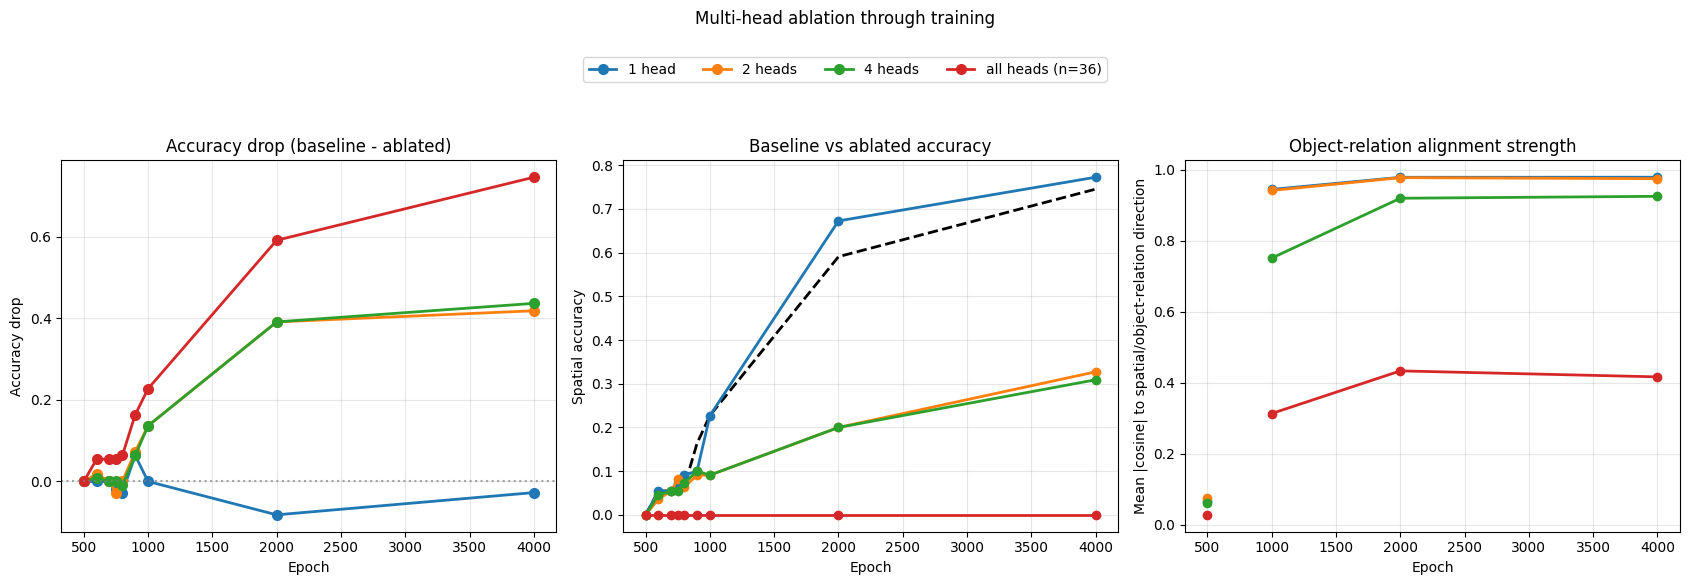

Multi-head importance heatmaps (2h):   4%|▍         | 268/6732 [02:07<4:46:50,  2.66s/prompt, epoch=500, extra_head=L2H2]

KeyboardInterrupt: 

Multi-head importance heatmaps (2h):   4%|▍         | 268/6732 [02:19<4:46:50,  2.66s/prompt, epoch=500, extra_head=L2H2]

In [ ]:
# Multi-head ablation visualizations (from multihead_ablation_df_out)
import ast
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from matplotlib.patches import Rectangle
from tqdm.auto import tqdm

from utils.zero_head_ablation_utils import apply_zero_head_ablation_multi, restore_processors
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings

if "multihead_ablation_df_out" not in dir() or multihead_ablation_df_out is None or multihead_ablation_df_out.empty:
    print("Run the multi-head ablation sweep cell above first.")
else:
    df = multihead_ablation_df_out.sort_values(["condition_sort_key", "epoch"]).copy()
    cond_order = (
        df[["condition_label", "condition_sort_key"]]
        .drop_duplicates()
        .sort_values("condition_sort_key")["condition_label"]
        .tolist()
    )
    baseline_df = df.groupby("epoch", as_index=False)["acc_baseline"].first().sort_values("epoch")

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # 1. Accuracy drop vs epoch
    for cond in cond_order:
        dfc = df[df["condition_label"] == cond].sort_values("epoch")
        axes[0].plot(dfc["epoch"], dfc["acc_drop"], "o-", linewidth=2, markersize=7, label=cond)
    axes[0].axhline(0, color="gray", linestyle=":", alpha=0.7)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy drop")
    axes[0].set_title("Accuracy drop (baseline - ablated)")
    axes[0].grid(True, alpha=0.3)

    # 2. Baseline vs ablated accuracy vs epoch
    axes[1].plot(baseline_df["epoch"], baseline_df["acc_baseline"], "k--", linewidth=2, label="Baseline")
    for cond in cond_order:
        dfc = df[df["condition_label"] == cond].sort_values("epoch")
        axes[1].plot(dfc["epoch"], dfc["acc_ablated"], "o-", linewidth=2, markersize=6, label=cond)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Spatial accuracy")
    axes[1].set_title("Baseline vs ablated accuracy")
    axes[1].grid(True, alpha=0.3)

    # 3. Descriptive object-relation alignment strength vs epoch
    for cond in cond_order:
        dfc = df[df["condition_label"] == cond].sort_values("epoch")
        axes[2].plot(dfc["epoch"], dfc["relation_alignment_strength"], "o-", linewidth=2, markersize=6, label=cond)
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Mean |cosine| to spatial/object-relation direction")
    axes[2].set_title("Object-relation alignment strength")
    axes[2].grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 4), bbox_to_anchor=(0.5, 1.08))
    fig.suptitle("Multi-head ablation through training", fontsize=12, y=1.16)
    plt.tight_layout()
    plt.show()

    MULTIHEAD_HEATMAP_CONDITION = globals().get("MULTIHEAD_HEATMAP_CONDITION", "2h")
    MULTIHEAD_HEATMAP_EPOCHS = globals().get("MULTIHEAD_HEATMAP_EPOCHS", sorted(df["epoch"].unique()))
    MULTIHEAD_HEATMAP_N_IMAGES = globals().get("MULTIHEAD_HEATMAP_N_IMAGES", min(globals().get("N_IMAGES_PER_PROMPT", 5), 3))
    MULTIHEAD_HEATMAP_N_STEPS = globals().get("MULTIHEAD_HEATMAP_N_STEPS", globals().get("MULTIHEAD_N_STEPS", 14))

    heat_rows = df[df["condition_key"] == MULTIHEAD_HEATMAP_CONDITION].copy()
    if heat_rows.empty:
        fallback_key = df.sort_values("condition_sort_key").iloc[0]["condition_key"]
        print(f"No rows for MULTIHEAD_HEATMAP_CONDITION={MULTIHEAD_HEATMAP_CONDITION!r}; using {fallback_key!r} instead.")
        MULTIHEAD_HEATMAP_CONDITION = fallback_key
        heat_rows = df[df["condition_key"] == MULTIHEAD_HEATMAP_CONDITION].copy()

    heat_rows = heat_rows[heat_rows["epoch"].isin(MULTIHEAD_HEATMAP_EPOCHS)].sort_values("epoch")
    if heat_rows.empty:
        print("No epochs matched MULTIHEAD_HEATMAP_EPOCHS for the head-importance heatmaps.")
    else:
        layer_num = transformer_config["depth"]
        head_num = transformer_config["num_heads"]

        def spatial_mean(eval_df):
            if eval_df is None or eval_df.empty:
                return np.nan
            if "spatial_relationship" not in eval_df.columns:
                raise KeyError("Expected strict spatial_relationship in eval_df for multi-head importance heatmaps.")
            return float(eval_df["spatial_relationship"].mean())

        def run_cached_eval(layer_head_pairs, progress_callback=None):
            orig = apply_zero_head_ablation_multi(pipeline.transformer, layer_head_pairs)
            try:
                eval_df, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
                    pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
                    num_images=MULTIHEAD_HEATMAP_N_IMAGES,
                    num_inference_steps=MULTIHEAD_HEATMAP_N_STEPS,
                    guidance_scale=ABLATION_GUIDANCE_SCALE,
                    generator_seed=42,
                    device=device,
                    weight_dtype=compute_dtype,
                    show_prompt_progress=False,
                    progress_callback=progress_callback,
                )
            finally:
                restore_processors(pipeline.transformer, orig)
            return eval_df

        total_evals = 0
        for _, row in heat_rows.iterrows():
            base_pairs = ast.literal_eval(row["layer_head_pairs"])
            total_evals += (layer_num * head_num - len(base_pairs)) * len(prompts_ablation)
        pbar = tqdm(total=total_evals, desc=f"Multi-head importance heatmaps ({MULTIHEAD_HEATMAP_CONDITION})", unit="prompt", mininterval=2)

        heatmap_results = []
        for _, row in heat_rows.iterrows():
            epoch = int(row["epoch"])
            ckpt_name = row["checkpoint"]
            base_pairs = [tuple(x) for x in ast.literal_eval(row["layer_head_pairs"])]
            base_set = set(base_pairs)

            ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
            load_pixart_ema_into_transformer(pipeline.transformer, ckpt["state_dict_ema"])
            pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
            del ckpt
            gc.collect()

            heat_acc = np.full((layer_num, head_num), np.nan, dtype=float)
            heat_importance = np.full((layer_num, head_num), np.nan, dtype=float)
            base_acc = float(row["acc_ablated"])
            for layer_idx in range(layer_num):
                for head_idx in range(head_num):
                    if (layer_idx, head_idx) in base_set:
                        continue
                    pairs = list(base_pairs) + [(layer_idx, head_idx)]
                    pbar.set_postfix(epoch=epoch, extra_head=f"L{layer_idx}H{head_idx}")
                    eval_df = run_cached_eval(pairs, progress_callback=lambda: pbar.update(1))
                    extra_acc = spatial_mean(eval_df)
                    heat_acc[layer_idx, head_idx] = extra_acc
                    heat_importance[layer_idx, head_idx] = base_acc - extra_acc

            heatmap_results.append(
                {
                    "epoch": epoch,
                    "condition_label": row["condition_label"],
                    "selected_head_labels": row["selected_head_labels"],
                    "base_pairs": base_pairs,
                    "base_acc": base_acc,
                    "heat_acc": heat_acc,
                    "heat_importance": heat_importance,
                }
            )

        importance_vals = np.concatenate([
            np.ravel(res["heat_importance"][~np.isnan(res["heat_importance"])])
            for res in heatmap_results
            if np.any(~np.isnan(res["heat_importance"]))
        ])
        vmax = float(np.max(np.abs(importance_vals))) if importance_vals.size else 1.0
        vmax = max(vmax, 1e-6)

        n_panels = len(heatmap_results)
        ncols = min(3, n_panels)
        nrows = (n_panels + ncols - 1) // ncols
        fig2, axes2 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.9 * nrows))
        axes2 = np.atleast_2d(axes2)

        for idx, res in enumerate(heatmap_results):
            ax = axes2[idx // ncols, idx % ncols]
            sns.heatmap(
                res["heat_importance"], annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-vmax, vmax=vmax, ax=ax, cbar=True,
                xticklabels=list(range(head_num)), yticklabels=list(range(layer_num)),
            )
            ax.set_title(
                f"Epoch {res['epoch']} | {res['condition_label']}\n"
                f"strict spatial drop after ablating one extra head (base acc={res['base_acc']:.2f})",
                fontsize=10,
            )
            ax.set_xlabel("Extra ablated head")
            ax.set_ylabel("Layer")
            for layer_idx, head_idx in res["base_pairs"]:
                ax.add_patch(Rectangle((head_idx, layer_idx), 1, 1, fill=True, facecolor="black", edgecolor="white", linewidth=2, zorder=10))
                ax.text(head_idx + 0.5, layer_idx + 0.5, "ABL", ha="center", va="center", fontsize=7, color="white", fontweight="bold", zorder=11)

        for idx in range(n_panels, nrows * ncols):
            axes2.flatten()[idx].set_visible(False)

        plt.suptitle(
            f"Spatial-relation head importance after base multi-head ablation ({MULTIHEAD_HEATMAP_CONDITION})",
            fontsize=12,
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


### Relation head ablation results

Plots below show the ablation sweep results for the best-aligned (relation) head: accuracy drop, baseline vs ablated accuracy, and cosine alignment over epochs.

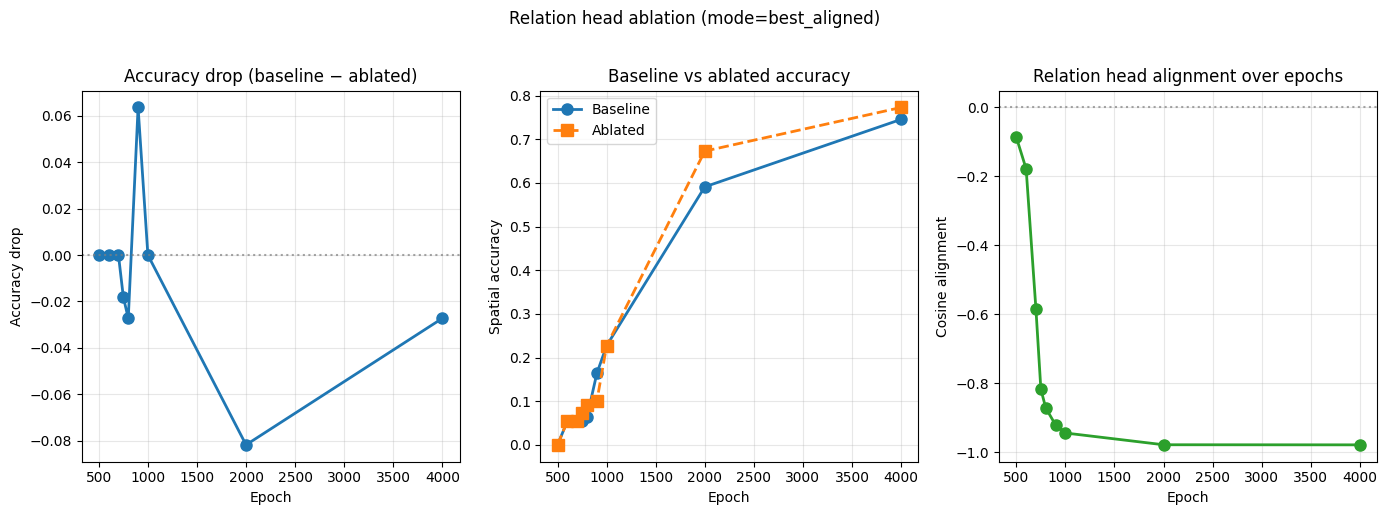

In [ ]:
# Relation head ablation visualizations (from ablation_df_out)
if not ablation_df_out.empty:
    df = ablation_df_out.sort_values("epoch")
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    # 1. Accuracy drop vs epoch
    ax = axes[0]
    ax.plot(df["epoch"], df["acc_drop"], "o-", linewidth=2, markersize=8, color="C0")
    ax.axhline(0, color="gray", linestyle=":", alpha=0.7)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy drop")
    ax.set_title("Accuracy drop (baseline − ablated)")
    ax.grid(True, alpha=0.3)

    # 2. Baseline vs ablated accuracy vs epoch
    ax = axes[1]
    ax.plot(df["epoch"], df["acc_baseline"], "o-", label="Baseline", linewidth=2, markersize=8)
    ax.plot(df["epoch"], df["acc_ablated"], "s--", label="Ablated", linewidth=2, markersize=8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Spatial accuracy")
    ax.set_title("Baseline vs ablated accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. Cosine alignment vs epoch
    ax = axes[2]
    ax.plot(df["epoch"], df["cosine_alignment"], "o-", linewidth=2, markersize=8, color="C2")
    ax.axhline(0, color="gray", linestyle=":", alpha=0.7)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cosine alignment")
    ax.set_title("Relation head alignment over epochs")
    ax.grid(True, alpha=0.3)

    fig.suptitle(f"Relation head ablation (mode={df['head_selection_mode'].iloc[0]})", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Run the ablation sweep cell above first.")

### Comparison: relation head vs random head ablation

Run the ablation cell above with `HEAD_SELECTION_MODE = "best_aligned"` first. This cell then runs the same ablation with a **random** head per checkpoint and plots accuracy drop: relation head (best-aligned) vs random head.

Multi-head importance heatmaps (2h): 100%|██████████| 6732/6732 [24:40<00:00,  4.72prompt/s, epoch=4000, extra_head=L5H5]

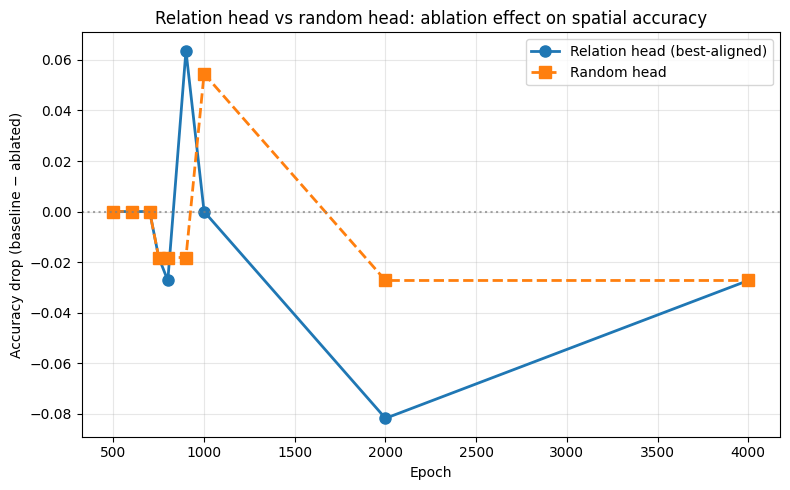

In [ ]:
ABLATION_GUIDANCE_SCALE = globals().get("ABLATION_GUIDANCE_SCALE", 4.5)
# Run random-head ablation and compare to relation-head (run ablation above with best_aligned first)
if not ablation_df_out.empty and ablation_df_out["head_selection_mode"].iloc[0] == "best_aligned":
    ablation_df_best = ablation_df_out.copy()
elif "ablation_df_best" not in dir():
    ablation_df_best = None

ckpt_list_r = ABLATION_CHECKPOINTS if ABLATION_CHECKPOINTS is not None else ckpt_files_ablation
ablation_records_random = []
pbar_r = tqdm(total=len(ckpt_list_r)*2*len(prompts_ablation), desc="Ablation (random)", unit="prompt", mininterval=2)
for ckpt_name in ckpt_list_r:
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    load_pixart_ema_into_transformer(pipeline.transformer, ckpt["state_dict_ema"])
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    epoch = int(ckpt_name.split("_")[1])
    df_ep = evolution_df_em[evolution_df_em["epoch"] == epoch] if epoch <= 1000 else evolution_df[evolution_df["epoch"] == epoch]
    if df_ep.empty:
        continue

    import random
    row = df_ep.sample(1).iloc[0]
    layer_idx, head_idx = int(row["layer_idx"]), int(row["head_idx"])
    cosine_at_epoch = float(row["cosine"])

    pbar_r.set_postfix(epoch=epoch, head=f"L{layer_idx}H{head_idx}", status="baseline")
    eval_baseline, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype,
        show_prompt_progress=False, progress_callback=lambda: pbar_r.update(1),
    )
    acc_baseline = eval_baseline["spatial_relationship"].mean() if not eval_baseline.empty and "spatial_relationship" in eval_baseline.columns else np.nan

    pbar_r.set_postfix(epoch=epoch, head=f"L{layer_idx}H{head_idx}", status="ablated")
    orig_procs = apply_zero_head_ablation(pipeline.transformer, layer_idx, [head_idx])
    eval_abl, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype,
        show_prompt_progress=False, progress_callback=lambda: pbar_r.update(1),
    )
    restore_processors(pipeline.transformer, orig_procs)
    acc_abl = eval_abl["spatial_relationship"].mean() if not eval_abl.empty and "spatial_relationship" in eval_abl.columns else np.nan

    ablation_records_random.append({
        "epoch": epoch, "checkpoint": ckpt_name,
        "layer_idx": layer_idx, "head_idx": head_idx, "head_label": f"L{layer_idx}H{head_idx}",
        "cosine_alignment": cosine_at_epoch,
        "acc_baseline": acc_baseline, "acc_ablated": acc_abl,
        "acc_drop": acc_baseline - acc_abl,
        "head_selection_mode": "random",
    })

ablation_df_random = pd.DataFrame(ablation_records_random)

# Plot: relation head vs random head accuracy drop
fig, ax = plt.subplots(figsize=(8, 5))
if ablation_df_best is not None and not ablation_df_best.empty:
    ax.plot(ablation_df_best["epoch"], ablation_df_best["acc_drop"], "o-", label="Relation head (best-aligned)", linewidth=2, markersize=8)
if not ablation_df_random.empty:
    ax.plot(ablation_df_random["epoch"], ablation_df_random["acc_drop"], "s--", label="Random head", linewidth=2, markersize=8)
ax.axhline(0, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy drop (baseline − ablated)")
ax.set_title("Relation head vs random head: ablation effect on spatial accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Qualitative image results: baseline vs ablation

Generate images for the same prompts with no intervention (baseline) vs with the relation head zeroed (ablation).

Qualitative prompts: ['blue circle is to the upper left of red square', 'blue circle is above and to the left of red square', 'blue circle is to the upper right of red square']


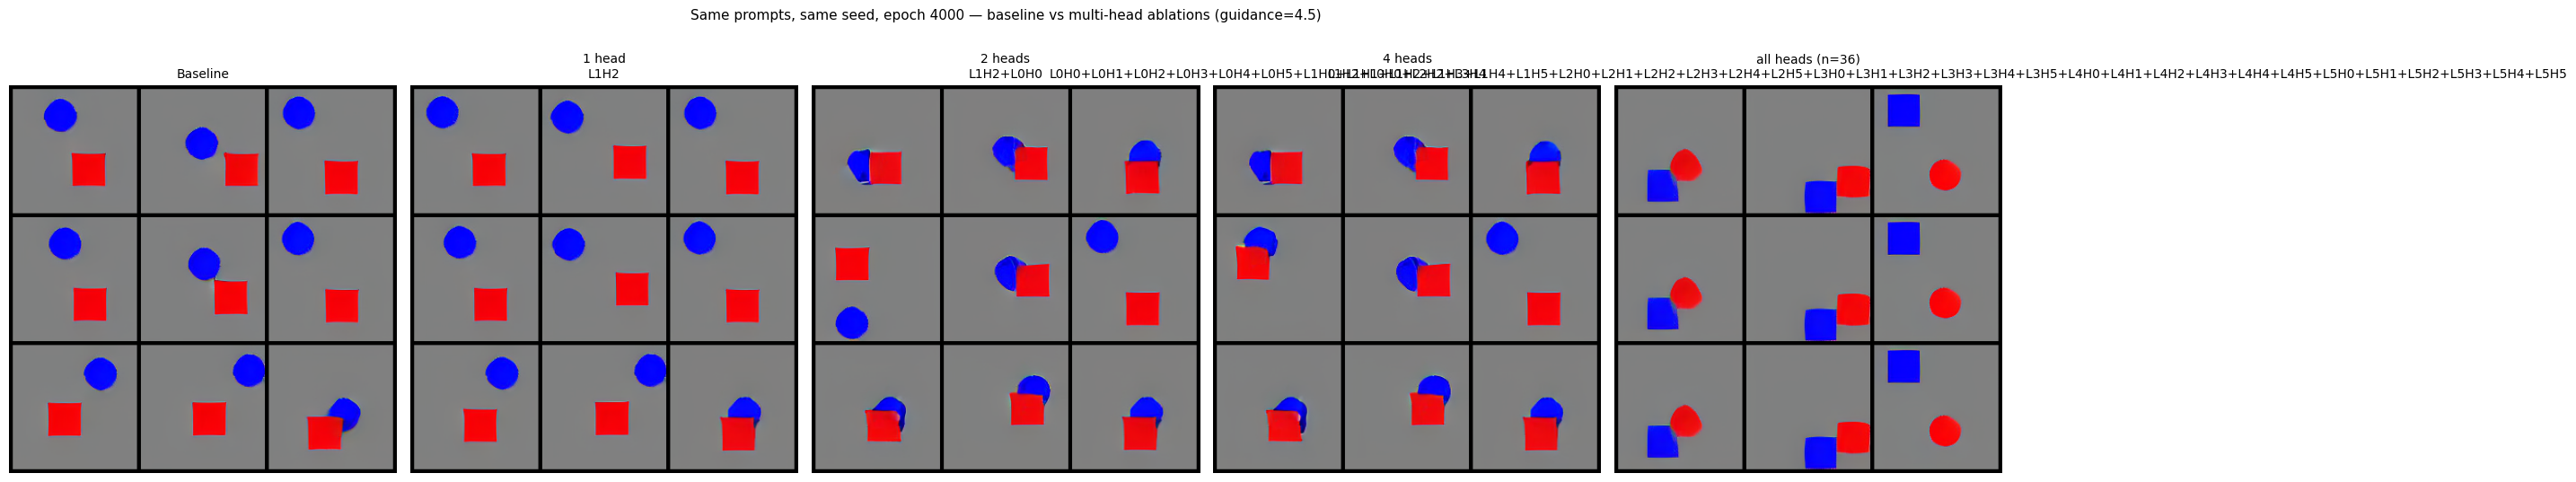

In [ ]:
# Qualitative image grid: baseline vs multi-head ablations
import ast
import gc
import glob
import torch
from os.path import join, basename

from utils.zero_head_ablation_utils import restore_processors, apply_zero_head_ablation_multi
from utils.image_utils import pil_images_to_grid

if "prompts_ablation" not in dir() or len(prompts_ablation) == 0:
    raise RuntimeError("Run the Early Ablation Sweep cell first.")
if "multihead_ablation_df_out" not in dir() or multihead_ablation_df_out is None or multihead_ablation_df_out.empty:
    raise RuntimeError("Run the multi-head ablation sweep cell first.")

qual_prompts = [p for p in prompts_ablation if 'left of' in p or 'right of' in p or ' above ' in p][:3]
if len(qual_prompts) < 3:
    qual_prompts = prompts_ablation[: min(3, len(prompts_ablation))]
print("Qualitative prompts:", qual_prompts)

qual_epoch = int(globals().get("MULTIHEAD_QUAL_EPOCH", multihead_ablation_df_out["epoch"].max()))
qual_guidance_scale = globals().get("MULTIHEAD_QUAL_GUIDANCE_SCALE", globals().get("ABLATION_GUIDANCE_SCALE", 4.5))
qual_n_per_prompt = globals().get("MULTIHEAD_QUAL_N_PER_PROMPT", 3)
qual_n_steps = globals().get("MULTIHEAD_N_STEPS", 14)

if "ckpt_files_ablation" not in dir() or not ckpt_files_ablation:
    ckpt_files_ablation = sorted(
        glob.glob(join(ckptdir, "*.pth")),
        key=lambda p: int(basename(p).split("_step_")[-1].split(".pth")[0]) if "_step_" in p else 0,
    )

rows_epoch = multihead_ablation_df_out[multihead_ablation_df_out["epoch"] == qual_epoch].sort_values("condition_sort_key")
if rows_epoch.empty:
    raise RuntimeError(f"No multi-head rows found for qual epoch {qual_epoch}.")

ckpt_name = rows_epoch.iloc[0]["checkpoint"]
ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
load_pixart_ema_into_transformer(pipeline.transformer, ckpt["state_dict_ema"])
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt
gc.collect()

uncond = embedding_cache_ablation[""]
uncond_emb = uncond["caption_embeds"].to(device=device, dtype=compute_dtype)
uncond_mask = uncond["emb_mask"].to(device=device)


def gen_images_for_prompts(prompts, n_per_prompt):
    images = []
    for prompt in prompts:
        cached = None
        for k in embedding_cache_ablation:
            if k != "" and k.endswith(f"::{prompt}"):
                cached = embedding_cache_ablation[k]
                break
        if cached is None:
            continue
        cap = cached["caption_embeds"].to(device=device, dtype=compute_dtype)
        mask = cached["emb_mask"].to(device=device)
        gen_dev = "cpu" if str(device) == "mps" else device
        out = pipeline(
            num_inference_steps=qual_n_steps,
            num_images_per_prompt=n_per_prompt,
            generator=torch.Generator(device=gen_dev).manual_seed(42),
            guidance_scale=qual_guidance_scale,
            prompt_embeds=cap,
            prompt_attention_mask=mask,
            negative_prompt=None,
            negative_prompt_embeds=uncond_emb,
            negative_prompt_attention_mask=uncond_mask,
            use_resolution_binning=False,
            prompt_dtype=compute_dtype,
            verbose=False,
        )
        images.extend(out.images)
    return images


conditions = [("Baseline", [])]
for _, row in rows_epoch.iterrows():
    pairs = ast.literal_eval(row["layer_head_pairs"])
    label = row["condition_label"]
    head_str = row["selected_head_labels"]
    conditions.append((f"{label}\n{head_str}", pairs))

fig, axes = plt.subplots(1, len(conditions), figsize=(4.5 * len(conditions), 5.5))
if len(conditions) == 1:
    axes = [axes]

for ax, (label, pairs) in zip(axes, conditions):
    orig_procs = None
    if pairs:
        orig_procs = apply_zero_head_ablation_multi(pipeline.transformer, pairs)
    try:
        imgs = gen_images_for_prompts(qual_prompts, qual_n_per_prompt)
    finally:
        if orig_procs is not None:
            restore_processors(pipeline.transformer, orig_procs)
    grid = pil_images_to_grid(imgs, grid_size=(qual_n_per_prompt, len(qual_prompts)), padding=4)
    ax.imshow(grid)
    ax.axis("off")
    ax.set_title(label, fontsize=10)

plt.suptitle(
    f"Same prompts, same seed, epoch {qual_epoch} — baseline vs multi-head ablations (guidance={qual_guidance_scale})",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()


### Step-dependent ablation (per-step temporal causality)

Ablate the relation head **only at step i** (i=0..13). Plot accuracy vs step to see when the head matters most during denoising.

> **Note on interpretation:** Per-step ablation results should be interpreted with caution. 
> Accuracy sensitivity to ablation at different diffusion steps conflates head importance 
> with the inherent noise schedule of the diffusion process. Early steps operate on high-noise 
> latents where perturbations may be more easily absorbed; later steps refine fine details 
> where any perturbation is more visible. This does not invalidate the analysis but means 
> step-specific importance cannot be attributed solely to the attention head.


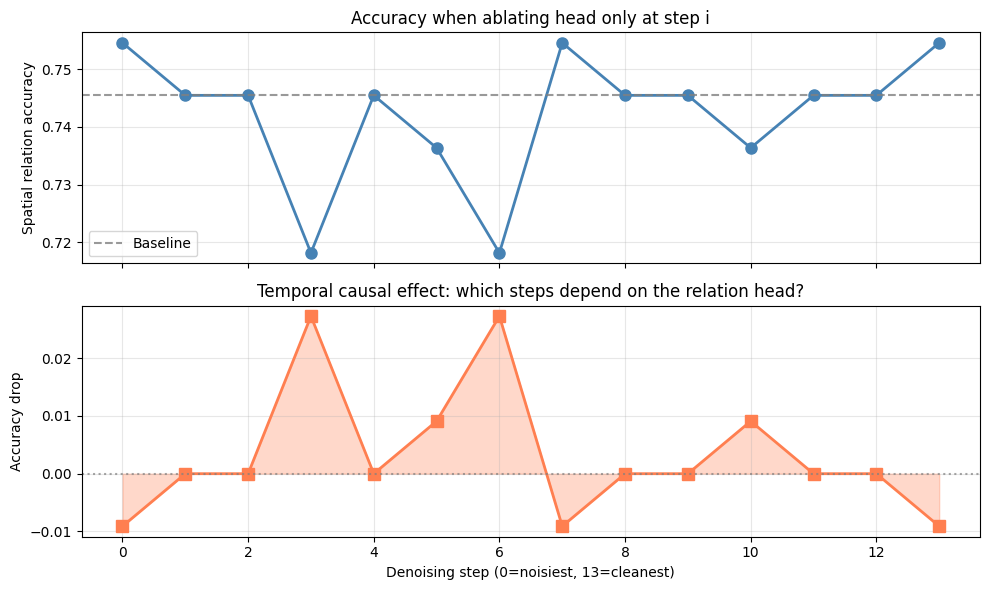

In [ ]:
ABLATION_GUIDANCE_SCALE = globals().get("ABLATION_GUIDANCE_SCALE", 4.5)
# Step-dependent ablation: per-step accuracy (when does the head matter?)
# Ablate relation head ONLY at step i (step_range=(i,i)) for each i in 0..13
from utils.zero_head_ablation_utils import apply_zero_head_ablation, restore_processors

num_steps = 14
layer_idx = int(ablation_df_out.iloc[-1]['layer_idx']) if not ablation_df_out.empty else 0
head_idx = int(ablation_df_out.iloc[-1]['head_idx']) if not ablation_df_out.empty else 0

# Baseline
eval_baseline, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
    pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
    num_images=N_IMAGES_PER_PROMPT, num_inference_steps=num_steps, guidance_scale=ABLATION_GUIDANCE_SCALE,
    generator_seed=42, device=device, weight_dtype=compute_dtype, show_prompt_progress=False,
)
acc_baseline = eval_baseline["spatial_relationship"].mean()

# Per-step ablation: ablate only at step i
step_accs, step_drops = [], []
for step_i in range(num_steps):
    orig_procs = apply_zero_head_ablation(
        pipeline.transformer, layer_idx, [head_idx], step_range=(step_i, step_i)
    )
    eval_abl, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=num_steps, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype, show_prompt_progress=False,
    )
    restore_processors(pipeline.transformer, orig_procs)
    acc = eval_abl["spatial_relationship"].mean()
    step_accs.append(acc)
    step_drops.append(acc_baseline - acc)

# Line plot: accuracy drop vs denoising step (temporal causal curve)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
steps = np.arange(num_steps)
axes[0].plot(steps, step_accs, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axhline(acc_baseline, color='gray', linestyle='--', alpha=0.8, label='Baseline')
axes[0].set_ylabel('Spatial relation accuracy')
axes[0].set_title('Accuracy when ablating head only at step i')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, step_drops, 's-', color='coral', linewidth=2, markersize=8)
axes[1].axhline(0, color='gray', linestyle=':', alpha=0.7)
axes[1].fill_between(steps, 0, step_drops, alpha=0.3, color='coral')
axes[1].set_xlabel('Denoising step (0=noisiest, 13=cleanest)')
axes[1].set_ylabel('Accuracy drop')
axes[1].set_title('Temporal causal effect: which steps depend on the relation head?')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Trace downstream relation-head readers: causal verification

Take the top candidate heads from the trajectory screen and test whether they causally matter with source-only, candidate-only, and source+candidate ablations.

In [ ]:
# Causal verification with relation-head + top-5 downstream pair ablations (all-steps)
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from utils.downstream_head_tracing import run_pair_ablation_grid

TRACE_PAIR_TOP_N = int(globals().get("TRACE_PAIR_TOP_N", 5))
TRACE_PAIR_SOURCE_HEADS = globals().get("TRACE_PAIR_SOURCE_HEADS", [SOURCE_REL_HEAD])
TRACE_PAIR_ALLOWED_SOURCE_HEADS = globals().get("TRACE_PAIR_ALLOWED_SOURCE_HEADS", [(0, 0), (1, 2)])
TRACE_PAIR_CHECKPOINTS = globals().get(
    "TRACE_PAIR_CHECKPOINTS",
    [TRACE_DEV_CHECKPOINTS[-1]] if len(TRACE_DEV_CHECKPOINTS) > 0 else TRACE_DEV_CHECKPOINTS,
)
TRACE_PAIR_N_IMAGES = int(globals().get("TRACE_PAIR_N_IMAGES", min(TRACE_N_IMAGES_PER_PROMPT, 3)))
# all-steps ablation: use full diffusion trajectory (not per-step temporal masking)
TRACE_PAIR_N_STEPS = int(globals().get("TRACE_PAIR_N_STEPS", TRACE_N_STEPS))
TRACE_PAIR_GUIDANCE_SCALE = float(globals().get("TRACE_PAIR_GUIDANCE_SCALE", TRACE_GUIDANCE_SCALE))
TRACE_PAIR_MAX_PROMPTS = int(globals().get("TRACE_PAIR_MAX_PROMPTS", 12))
TRACE_PAIR_METRICS = [
    "spatial_relationship",
    "spatial_relationship_loose",
    "overall",
    "overall_loose",
    "unique_binding",
    "exist_binding",
]

if "trace_candidate_rank_df" not in dir() or trace_candidate_rank_df is None or trace_candidate_rank_df.empty:
    raise RuntimeError("Run the candidate discovery cell first.")

trace_candidate_heads = [
    (int(row.layer_idx), int(row.head_idx))
    for row in trace_candidate_rank_df.head(TRACE_PAIR_TOP_N).itertuples()
]
if len(trace_candidate_heads) == 0:
    raise RuntimeError("No downstream candidate heads available.")

trace_pair_prompts = prompts_ablation[:TRACE_PAIR_MAX_PROMPTS]
trace_pair_scene_infos = scene_infos_ablation[:TRACE_PAIR_MAX_PROMPTS]
trace_pair_source_heads = [tuple(map(int, h)) for h in TRACE_PAIR_SOURCE_HEADS]
trace_pair_allowed_heads = {tuple(map(int, h)) for h in TRACE_PAIR_ALLOWED_SOURCE_HEADS}
for h in trace_pair_source_heads:
    if h not in trace_pair_allowed_heads:
        raise ValueError(f"Source head {h} not in allowed set {sorted(trace_pair_allowed_heads)}")

trace_pair_summary_all = []
trace_pair_eval_all = []
for src_head in trace_pair_source_heads:
    print(
        f"Run pair ablations | source=L{src_head[0]}H{src_head[1]} | topN={len(trace_candidate_heads)} | "
        f"prompts={len(trace_pair_prompts)} | steps(all)={TRACE_PAIR_N_STEPS}"
    )
    sp_df, ev_df = run_pair_ablation_grid(
        pipeline=pipeline,
        ckptdir=ckptdir,
        ckpt_list=TRACE_PAIR_CHECKPOINTS,
        prompts=trace_pair_prompts,
        scene_infos=trace_pair_scene_infos,
        embedding_cache=embedding_cache_ablation,
        source_head=src_head,
        candidate_heads=trace_candidate_heads,
        state_dict_convert=state_dict_convert,
        device=device,
        weight_dtype=compute_dtype,
        num_images=TRACE_PAIR_N_IMAGES,
        num_inference_steps=TRACE_PAIR_N_STEPS,
        guidance_scale=TRACE_PAIR_GUIDANCE_SCALE,
        generator_seed=42,
        metric_cols=TRACE_PAIR_METRICS,
        show_prompt_progress=False,
        progress_mode="print",
    )
    sp_df = sp_df.copy()
    sp_df["source_head_label"] = f"L{src_head[0]}H{src_head[1]}"
    ev_df = ev_df.copy()
    if not ev_df.empty:
        ev_df["source_head_label"] = f"L{src_head[0]}H{src_head[1]}"
    trace_pair_summary_all.append(sp_df)
    trace_pair_eval_all.append(ev_df)

trace_pair_summary_df = pd.concat(trace_pair_summary_all, ignore_index=True) if trace_pair_summary_all else pd.DataFrame()
trace_pair_eval_df = pd.concat(trace_pair_eval_all, ignore_index=True) if trace_pair_eval_all else pd.DataFrame()

show_cols = [
    "source_head_label", "epoch", "condition_label", "candidate_head",
    *[m for m in TRACE_PAIR_METRICS if m in trace_pair_summary_df.columns],
    *[f"{m}_delta_from_baseline" for m in TRACE_PAIR_METRICS if f"{m}_delta_from_baseline" in trace_pair_summary_df.columns],
]
display(trace_pair_summary_df[show_cols])

pair_only_df = trace_pair_summary_df[
    trace_pair_summary_df["condition_key"].str.startswith("pair__")
].copy()

if not pair_only_df.empty:
    delta_cols = [f"{m}_delta_from_baseline" for m in TRACE_PAIR_METRICS if f"{m}_delta_from_baseline" in pair_only_df.columns]

    # Per-pair graphs: one figure per (source, candidate), all metrics shown.
    for (src_label, cand_label), dfg in pair_only_df.groupby(["source_head_label", "candidate_head"]):
        n_metrics = len(delta_cols)
        n_cols = min(3, max(1, n_metrics))
        n_rows = int(math.ceil(n_metrics / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 3.6 * n_rows))
        axes = np.array(axes).reshape(-1)

        for ax_idx, delta_col in enumerate(delta_cols):
            ax = axes[ax_idx]
            metric = delta_col.replace("_delta_from_baseline", "")
            dfg_plot = dfg.sort_values("epoch")
            ax.plot(dfg_plot["epoch"], dfg_plot[delta_col], "o-", color="#1f77b4", linewidth=2)
            ax.axhline(0.0, color="gray", linestyle=":", linewidth=1.0)
            ax.set_title(metric)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("baseline - pair-ablated")
            ax.grid(True, alpha=0.3)

        for j in range(n_metrics, len(axes)):
            axes[j].axis("off")

        fig.suptitle(f"Pair ablation metrics | source {src_label} + candidate {cand_label}", y=1.02, fontsize=12)
        plt.tight_layout()
        plt.show()

    # Cross-pair comparison graph: heatmaps of pair delta by candidate x metric.
    for src_label, dfs in pair_only_df.groupby("source_head_label"):
        cmp_cols = [f"{m}_delta_from_baseline" for m in TRACE_PAIR_METRICS if f"{m}_delta_from_baseline" in dfs.columns]
        if not cmp_cols:
            continue
        cmp_df = (
            dfs.groupby("candidate_head", as_index=False)[cmp_cols]
            .mean(numeric_only=True)
            .set_index("candidate_head")
        )
        cmp_df = cmp_df.rename(columns=lambda c: c.replace("_delta_from_baseline", ""))

        plt.figure(figsize=(1.4 * max(4, len(cmp_df.columns)) + 2.5, 0.5 * max(4, len(cmp_df.index)) + 2.5))
        sns.heatmap(cmp_df, annot=True, fmt=".3f", cmap="magma", cbar_kws={"label": "baseline - pair-ablated"})
        plt.title(f"Compare downstream pairs by metric | source {src_label}")
        plt.xlabel("Metric")
        plt.ylabel("Candidate pair")
        plt.tight_layout()
        plt.show()

    # Aggregate comparison plot across pairs for strict spatial metric.
    if "spatial_relationship_delta_from_baseline" in pair_only_df.columns:
        agg_spatial = (
            pair_only_df.groupby(["source_head_label", "candidate_head"], as_index=False)["spatial_relationship_delta_from_baseline"]
            .mean(numeric_only=True)
            .sort_values(["source_head_label", "spatial_relationship_delta_from_baseline"], ascending=[True, False])
        )
        plt.figure(figsize=(max(10, 0.8 * len(agg_spatial)), 4.8))
        sns.barplot(
            data=agg_spatial,
            x="candidate_head",
            y="spatial_relationship_delta_from_baseline",
            hue="source_head_label",
        )
        plt.axhline(0.0, color="gray", linestyle=":", linewidth=1.0)
        plt.title("Compare source+candidate pair effects on strict spatial metric")
        plt.xlabel("Candidate downstream head")
        plt.ylabel("baseline - pair-ablated")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

Candidate heads for causal verification: [(3, 5), (2, 2), (2, 1)]


Pair ablations:  19%|█▉        | 378/1980 [08:50<37:27,  1.40s/prompt, condition=src__2_1, epoch=600]  


KeyboardInterrupt: 

## Summary

Key findings from ablation and causality analysis:
- **OV-QK-OV candidate discovery** identified downstream reader heads structurally connected to the relation heads found in NB01
- **Single-head ablation sweep** confirms that zeroing relation-sensitive heads causes significant accuracy drops in spatial relationship evaluation
- **Relation vs random comparison** shows relation heads cause larger accuracy drops than randomly selected heads of similar norm
- **Pair-ablation grid** reveals interaction structure: ablating both a relation head and its downstream reader produces larger effects than either alone
- **Qualitative results** show visible spatial errors in generated images when relation heads are ablated
- **Temporal analysis** suggests relation heads are most impactful during mid-to-late denoising steps (with caveats about diffusion dynamics confounds)

Next: proceed to `03_identifiability_and_variance_partition.ipynb` for training evolution analysis.


## Multi-seed robustness (consolidated rerun) — ablation effect sizes

This section mirrors the method-integrated robustness cells above and is kept only as a compact end-of-notebook rerun block.

In [ ]:
from utils.multi_seed_robustness import eval_cached_ablation_effect_multiseed
from utils.ablation_eval_prompts import build_heldout_generalization_prompts

_req = {"ablation_df_out", "pipeline", "embedding_cache_ablation", "device", "compute_dtype", "prompt_scene_info_all_df"}
_miss = _req - set(dir())
if _miss:
    print("Skip: run Early Ablation Sweep first. Missing:", sorted(_miss))
elif ablation_df_out is None or ablation_df_out.empty:
    print("Skip: ablation_df_out is empty")
else:
    ms_exclude_pairs = globals().get("HELDOUT_EXCLUDE_PAIRS", [("blue", "circle", "red", "square")])
    ms_n_per_rel = int(globals().get("HELDOUT_N_PER_RELATION", 3))
    ms_max_prompts = int(globals().get("HELDOUT_MAX_PROMPTS", 24))
    prompts_ms, scene_infos_ms, heldout_ms_df = build_heldout_generalization_prompts(
        prompt_scene_info_all_df,
        embedding_cache_ablation,
        exclude_pairs=ms_exclude_pairs,
        n_per_relation=ms_n_per_rel,
        max_prompts=ms_max_prompts,
    )
    if len(prompts_ms) == 0:
        print("Skip: held-out validation split is empty for multi-seed ablation robustness.")
    else:
        last = ablation_df_out.sort_values("epoch").iloc[-1]
        li, hi = int(last["layer_idx"]), int(last["head_idx"])
        ms_df, ms_sum = eval_cached_ablation_effect_multiseed(
            pipeline,
            prompts_ms,
            scene_infos_ms,
            embedding_cache_ablation,
            li,
            hi,
            ROBUSTNESS_SEEDS,
            device=device,
            weight_dtype=compute_dtype,
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            num_images=1,
            show_prompt_progress=False,
        )
        print(
            f"Multi-seed cached eval on held-out prompts (last sweep head L{li}H{hi}, "
            f"n_prompts={len(prompts_ms)}, seeds={ROBUSTNESS_SEEDS}):"
        )
        print(ms_df.to_string(index=False))
        print("\nAggregate:")
        print(ms_sum.to_string())

## Multi-seed robustness (consolidated rerun) — downstream pair ablation

Optional compact rerun block corresponding to the method-integrated downstream robustness checks above.

In [ ]:
from utils.multi_seed_robustness import eval_pair_ablation_multiseed
from utils.ablation_eval_prompts import build_heldout_generalization_prompts

if "trace_candidate_rank_df" not in dir() or trace_candidate_rank_df is None or trace_candidate_rank_df.empty:
    print("Skip: run OV-QK / structural chain ranking first.")
elif "SOURCE_REL_HEAD" not in dir():
    print("Skip: SOURCE_REL_HEAD not defined.")
elif "prompt_scene_info_all_df" not in dir():
    print("Skip: prompt_scene_info_all_df missing.")
else:
    ms_exclude_pairs = globals().get("HELDOUT_EXCLUDE_PAIRS", [("blue", "circle", "red", "square")])
    ms_n_per_rel = int(globals().get("HELDOUT_N_PER_RELATION", 3))
    ms_max_prompts = int(globals().get("HELDOUT_MAX_PROMPTS", 24))
    prompts_ms, scene_infos_ms, _ = build_heldout_generalization_prompts(
        prompt_scene_info_all_df,
        embedding_cache_ablation,
        exclude_pairs=ms_exclude_pairs,
        n_per_relation=ms_n_per_rel,
        max_prompts=ms_max_prompts,
    )
    if len(prompts_ms) == 0:
        print("Skip: held-out validation split is empty for pair-ablation robustness.")
    else:
        top = trace_candidate_rank_df.iloc[0]
        cand = (int(top["layer_idx"]), int(top["head_idx"]))
        pair_heads = [SOURCE_REL_HEAD, cand]
        pdf, psum = eval_pair_ablation_multiseed(
            pipeline,
            prompts_ms,
            scene_infos_ms,
            embedding_cache_ablation,
            pair_heads,
            ROBUSTNESS_SEEDS,
            device=device,
            weight_dtype=compute_dtype,
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            num_images=1,
            show_prompt_progress=False,
        )
        print(
            f"Pair ablation (source + top candidate), multi-seed on held-out prompts "
            f"(n_prompts={len(prompts_ms)}, seeds={ROBUSTNESS_SEEDS}):"
        )
        print(pdf.to_string(index=False))
        print("\nAggregate:")
        print(psum.to_string())

## Multi-seed robustness (consolidated rerun) — emergence stability

Optional compact rerun block corresponding to the method-integrated emergence robustness analysis above.

In [ ]:
import gc
import torch
import pandas as pd
from os.path import basename, join

from utils.pixart_utils import load_pixart_ema_into_transformer
from utils.multi_seed_robustness import multi_bootstrap_head_alignment
from utils.ablation_eval_prompts import build_heldout_generalization_prompts

EMERGENCE_ROBUSTNESS_TOP_K = int(globals().get("EMERGENCE_ROBUSTNESS_TOP_K", 6))
EMERGENCE_ROBUSTNESS_N_PERM = int(globals().get("EMERGENCE_ROBUSTNESS_N_PERM", 24))
EMERGENCE_ROBUSTNESS_BASE_SIZE = int(globals().get("EMERGENCE_ROBUSTNESS_BASE_SIZE", 8))

if "ckpt_files_emergence" in dir() and ckpt_files_emergence:
    EMERGENCE_ROBUSTNESS_CHECKPOINTS = globals().get(
        "EMERGENCE_ROBUSTNESS_CHECKPOINTS",
        [ckpt_files_emergence[0], ckpt_files_emergence[-1]],
    )
elif "TRACE_STRUCTURAL_CHECKPOINT" in dir():
    EMERGENCE_ROBUSTNESS_CHECKPOINTS = globals().get(
        "EMERGENCE_ROBUSTNESS_CHECKPOINTS",
        [basename(str(TRACE_STRUCTURAL_CHECKPOINT))],
    )
else:
    EMERGENCE_ROBUSTNESS_CHECKPOINTS = globals().get("EMERGENCE_ROBUSTNESS_CHECKPOINTS", [])

if "prompt_scene_info_all_df" not in dir() or "embedding_allrel_allobj" not in dir():
    print("Skip: need prompt_scene_info_all_df and embedding_allrel_allobj first.")
elif len(EMERGENCE_ROBUSTNESS_CHECKPOINTS) == 0:
    print("Skip: no emergence robustness checkpoints configured.")
else:
    ms_exclude_pairs = globals().get("HELDOUT_EXCLUDE_PAIRS", [("blue", "circle", "red", "square")])
    heldout_prompts, heldout_scene_infos, heldout_meta_df = build_heldout_generalization_prompts(
        prompt_scene_info_all_df,
        embedding_allrel_allobj,
        exclude_pairs=ms_exclude_pairs,
        n_per_relation=int(globals().get("HELDOUT_N_PER_RELATION", 3)),
        max_prompts=int(globals().get("HELDOUT_MAX_PROMPTS", 24)),
    )
    if heldout_meta_df.empty:
        print("Skip: held-out validation set is empty for emergence robustness.")
    else:
        heldout_meta_df = heldout_meta_df.copy()
        heldout_meta_df["color1shape1"] = heldout_meta_df["color1"].astype(str) + "_" + heldout_meta_df["shape1"].astype(str)
        heldout_meta_df["color2shape2"] = heldout_meta_df["color2"].astype(str) + "_" + heldout_meta_df["shape2"].astype(str)

        emergence_robust_rows = []
        emergence_robust_tables = []
        emergence_robust_top_lists = []

        for ckpt_name in EMERGENCE_ROBUSTNESS_CHECKPOINTS:
            ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
            load_pixart_ema_into_transformer(pipeline.transformer, ckpt["state_dict_ema"])
            pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
            del ckpt
            gc.collect()

            epoch = int(basename(ckpt_name).split("_")[1]) if "epoch_" in basename(ckpt_name) else -1

            wordvec_obj2_col = []
            for row in heldout_meta_df.itertuples():
                tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
                tokens = [pipeline.tokenizer.decode([t]) for t in tokenized["input_ids"][0]]
                shape2_idx = find_shape_index(tokens, row.shape2)
                cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]["caption_embeds"]
                wordvec_obj2_col.append(cap_embeds[0, shape2_idx, :])
            wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
            with torch.no_grad():
                wordvec_obj2_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))

            stab_df, top_lists, _ = multi_bootstrap_head_alignment(
                pipeline.transformer,
                wordvec_obj2_proj.float().cpu().numpy(),
                heldout_meta_df,
                vp_features=["spatial_relationship", "shape1", "color2shape2"],
                seeds=ROBUSTNESS_SEEDS,
                n_perm=EMERGENCE_ROBUSTNESS_N_PERM,
                top_k=EMERGENCE_ROBUSTNESS_TOP_K,
                base_size=EMERGENCE_ROBUSTNESS_BASE_SIZE,
                verbose=False,
            )
            if not stab_df.empty:
                stab_df = stab_df.copy()
                stab_df["epoch"] = epoch
                stab_df["checkpoint"] = basename(ckpt_name)
                emergence_robust_tables.append(stab_df)
                best = stab_df.iloc[0]
                emergence_robust_rows.append(
                    {
                        "epoch": epoch,
                        "checkpoint": basename(ckpt_name),
                        "top_stable_head": f"L{int(best['layer'])}H{int(best['head'])}",
                        "top_head_in_topk_frac": float(best["in_topk_frac"]),
                        "n_unique_heads_in_topk": int(stab_df[["layer", "head"]].drop_duplicates().shape[0]),
                    }
                )
                emergence_robust_top_lists.append(
                    {
                        "epoch": epoch,
                        "checkpoint": basename(ckpt_name),
                        "topk_lists_per_seed": [
                            [f"L{li}H{hi}" for li, hi in lst]
                            for lst in top_lists
                        ],
                    }
                )

        emergence_robust_summary_df = pd.DataFrame(emergence_robust_rows).sort_values("epoch").reset_index(drop=True) if emergence_robust_rows else pd.DataFrame()
        emergence_robust_stability_df = pd.concat(emergence_robust_tables, ignore_index=True) if emergence_robust_tables else pd.DataFrame()

        print(
            f"Emergence robustness on held-out prompts: n_prompts={len(heldout_prompts)}, "
            f"checkpoints={len(EMERGENCE_ROBUSTNESS_CHECKPOINTS)}, seeds={ROBUSTNESS_SEEDS}"
        )
        if emergence_robust_summary_df.empty:
            print("No emergence robustness rows produced.")
        else:
            display(emergence_robust_summary_df)
            display(emergence_robust_stability_df.sort_values(["epoch", "in_topk_frac"], ascending=[True, False]))